## EDA: Medicare CMS DE-SynPUF 2008–2010

El objetivo es comparar la utilización y los pagos de Medicare en Inpatient y Outpatient. Se revisa la calidad de los archivos y se preparan las tablas que usará el proyecto. El Codebook sirve como referencia para interpretar sus columnas.

## 1. Entorno y carga

In [1]:
# Cargo las fuentes y preparo las librerias para el analisis.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
sns.set_theme(style="whitegrid", palette="colorblind")

beneficiary_2008 = pd.read_csv("Data/DE1_0_2008_Beneficiary_Summary_File_Sample_1.csv")
beneficiary_2009 = pd.read_csv("Data/DE1_0_2009_Beneficiary_Summary_File_Sample_1.csv")
beneficiary_2010 = pd.read_csv("Data/DE1_0_2010_Beneficiary_Summary_File_Sample_1.csv")
# Este codigo de procedimiento se lee como texto para conservar ceros iniciales.
inpatient_claims = pd.read_csv(
    "Data/DE1_0_2008_to_2010_Inpatient_Claims_Sample_1.csv",
    dtype={"ICD9_PRCDR_CD_1": "string"}
)
# Outpatient: los codigos con inferencia mixta tambien se leen como texto.
tipos_outpatient = {"ICD9_DGNS_CD_10": "string"}
for numero in range(1, 7):
    tipos_outpatient[f"ICD9_PRCDR_CD_{numero}"] = "string"
outpatient_claims = pd.read_csv(
    "Data/DE1_0_2008_to_2010_Outpatient_Claims_Sample_1.csv",
    dtype=tipos_outpatient
)


Algunos códigos ICD-9 se leen como texto para evitar que se pierdan ceros iniciales. CLM_ID también pasa a texto cuando se preparan las tablas finales.

## 2. Estructura de las fuentes

In [2]:
print("beneficiary_2008:", beneficiary_2008.shape)
print("beneficiary_2009:", beneficiary_2009.shape)
print("beneficiary_2010:", beneficiary_2010.shape)
print("inpatient_claims:", inpatient_claims.shape)
print("outpatient_claims:", outpatient_claims.shape)


beneficiary_2008: (116352, 32)
beneficiary_2009: (114538, 32)
beneficiary_2010: (112754, 32)
inpatient_claims: (66773, 81)
outpatient_claims: (790790, 76)


### 2.1. Beneficiary Summary

Los tres archivos tienen la misma estructura: 32 columnas y 116.352, 114.538 y 112.754 registros en 2008, 2009 y 2010.

In [3]:
# Reviso una muestra y compruebo que Beneficiary tenga la misma estructura en los tres años.
display(beneficiary_2008.head())
display(beneficiary_2008.columns.tolist())

mismas_columnas = (
    beneficiary_2008.columns.tolist()
    == beneficiary_2009.columns.tolist()
    == beneficiary_2010.columns.tolist()
)

print("Mismas columnas:", mismas_columnas)

misma_estructura = (
    beneficiary_2008.dtypes.equals(beneficiary_2009.dtypes)
    and beneficiary_2008.dtypes.equals(beneficiary_2010.dtypes)
)

print("Misma estructura:", misma_estructura)

beneficiary_2008.info()


,DESYNPUF_ID,BENE_BIRTH_DT,BENE_DEATH_DT,BENE_SEX_IDENT_CD,BENE_RACE_CD,BENE_ESRD_IND,SP_STATE_CODE,BENE_COUNTY_CD,BENE_HI_CVRAGE_TOT_MONS,BENE_SMI_CVRAGE_TOT_MONS,...,SP_STRKETIA,MEDREIMB_IP,BENRES_IP,PPPYMT_IP,MEDREIMB_OP,BENRES_OP,PPPYMT_OP,MEDREIMB_CAR,BENRES_CAR,PPPYMT_CAR
0,00013D2EFD8E45D1,19230501,NaN,1,1,0,26,950,12,12,...,2,0.0,0.0,0.0,50.0,10.0,0.0,0.0,0.0,0.0
1,00016F745862898F,19430101,NaN,1,1,0,39,230,12,12,...,2,0.0,0.0,0.0,0.0,0.0,0.0,700.0,240.0,0.0
2,0001FDD721E223DC,19360901,NaN,2,1,0,39,280,12,12,...,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,00021CA6FF03E670,19410601,NaN,1,5,0,6,290,0,0,...,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,00024B3D2352D2D0,19360801,NaN,1,1,0,52,590,12,12,...,2,0.0,0.0,0.0,30.0,40.0,0.0,220.0,80.0,0.0


['DESYNPUF_ID',
 'BENE_BIRTH_DT',
 'BENE_DEATH_DT',
 'BENE_SEX_IDENT_CD',
 'BENE_RACE_CD',
 'BENE_ESRD_IND',
 'SP_STATE_CODE',
 'BENE_COUNTY_CD',
 'BENE_HI_CVRAGE_TOT_MONS',
 'BENE_SMI_CVRAGE_TOT_MONS',
 'BENE_HMO_CVRAGE_TOT_MONS',
 'PLAN_CVRG_MOS_NUM',
 'SP_ALZHDMTA',
 'SP_CHF',
 'SP_CHRNKIDN',
 'SP_CNCR',
 'SP_COPD',
 'SP_DEPRESSN',
 'SP_DIABETES',
 'SP_ISCHMCHT',
 'SP_OSTEOPRS',
 'SP_RA_OA',
 'SP_STRKETIA',
 'MEDREIMB_IP',
 'BENRES_IP',
 'PPPYMT_IP',
 'MEDREIMB_OP',
 'BENRES_OP',
 'PPPYMT_OP',
 'MEDREIMB_CAR',
 'BENRES_CAR',
 'PPPYMT_CAR']

Mismas columnas: True
Misma estructura: True
<class 'pandas.DataFrame'>
RangeIndex: 116352 entries, 0 to 116351
Data columns (total 32 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   DESYNPUF_ID               116352 non-null  str    
 1   BENE_BIRTH_DT             116352 non-null  int64  
 2   BENE_DEATH_DT             1814 non-null    float64
 3   BENE_SEX_IDENT_CD         116352 non-null  int64  
 4   BENE_RACE_CD              116352 non-null  int64  
 5   BENE_ESRD_IND             116352 non-null  str    
 6   SP_STATE_CODE             116352 non-null  int64  
 7   BENE_COUNTY_CD            116352 non-null  int64  
 8   BENE_HI_CVRAGE_TOT_MONS   116352 non-null  int64  
 9   BENE_SMI_CVRAGE_TOT_MONS  116352 non-null  int64  
 10  BENE_HMO_CVRAGE_TOT_MONS  116352 non-null  int64  
 11  PLAN_CVRG_MOS_NUM         116352 non-null  int64  
 12  SP_ALZHDMTA               116352 non-null  int64  
 13  SP_CHF    

### 2.2. Inpatient y Outpatient

In [4]:
# Comparo las columnas de Inpatient y Outpatient para identificar lo que comparten.
display(inpatient_claims.head(5))

display(outpatient_claims.head(5))
display(outpatient_claims.columns.tolist())

mismas_columnas_patient = (
    outpatient_claims.columns.tolist()
    == inpatient_claims.columns.tolist()
)

print("Mismas columnas:", mismas_columnas_patient)

columnas_comunes_patient = set(inpatient_claims.columns) & set(outpatient_claims.columns)
inpatient_unicas = set(inpatient_claims.columns) - set(outpatient_claims.columns)
outpatient_unicas = set(outpatient_claims.columns) - set(inpatient_claims.columns)

print("Columnas comunes:", len(columnas_comunes_patient))
print("Columnas solo en inpatient:", len(inpatient_unicas))
print("Columnas solo en outpatient:", len(outpatient_unicas))

print("\nSolo inpatient:")
print(inpatient_unicas)

print("\nSolo outpatient:")
print(outpatient_unicas)


,DESYNPUF_ID,CLM_ID,SEGMENT,CLM_FROM_DT,CLM_THRU_DT,PRVDR_NUM,CLM_PMT_AMT,NCH_PRMRY_PYR_CLM_PD_AMT,AT_PHYSN_NPI,OP_PHYSN_NPI,...,HCPCS_CD_36,HCPCS_CD_37,HCPCS_CD_38,HCPCS_CD_39,HCPCS_CD_40,HCPCS_CD_41,HCPCS_CD_42,HCPCS_CD_43,HCPCS_CD_44,HCPCS_CD_45
0,00013D2EFD8E45D1,196661176988405,1,20100312.0,20100313.0,2600GD,4000.0,0.0,3.139084e+09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00016F745862898F,196201177000368,1,20090412.0,20090418.0,3900MB,26000.0,0.0,6.476809e+09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00016F745862898F,196661177015632,1,20090831.0,20090902.0,3900HM,5000.0,0.0,6.119985e+08,6.119985e+08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00016F745862898F,196091176981058,1,20090917.0,20090920.0,3913XU,5000.0,0.0,4.971603e+09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,00016F745862898F,196261176983265,1,20100626.0,20100701.0,3900MB,16000.0,0.0,6.408400e+09,1.960860e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,DESYNPUF_ID,CLM_ID,SEGMENT,CLM_FROM_DT,CLM_THRU_DT,PRVDR_NUM,CLM_PMT_AMT,NCH_PRMRY_PYR_CLM_PD_AMT,AT_PHYSN_NPI,OP_PHYSN_NPI,...,HCPCS_CD_36,HCPCS_CD_37,HCPCS_CD_38,HCPCS_CD_39,HCPCS_CD_40,HCPCS_CD_41,HCPCS_CD_42,HCPCS_CD_43,HCPCS_CD_44,HCPCS_CD_45
0,00013D2EFD8E45D1,542192281063886,1,20080904.0,20080904.0,2600RA,50.0,0.0,4.824842e+09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00016F745862898F,542272281166593,1,20090602.0,20090602.0,3901GS,30.0,0.0,2.963420e+09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00016F745862898F,542282281644416,1,20090623.0,20090623.0,3939PG,30.0,0.0,5.737808e+09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0001FDD721E223DC,542642281250669,1,20091011.0,20091011.0,3902NU,30.0,0.0,1.233848e+09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,00024B3D2352D2D0,542242281386963,1,20080712.0,20080712.0,5200TV,30.0,0.0,9.688809e+09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


['DESYNPUF_ID',
 'CLM_ID',
 'SEGMENT',
 'CLM_FROM_DT',
 'CLM_THRU_DT',
 'PRVDR_NUM',
 'CLM_PMT_AMT',
 'NCH_PRMRY_PYR_CLM_PD_AMT',
 'AT_PHYSN_NPI',
 'OP_PHYSN_NPI',
 'OT_PHYSN_NPI',
 'NCH_BENE_BLOOD_DDCTBL_LBLTY_AM',
 'ICD9_DGNS_CD_1',
 'ICD9_DGNS_CD_2',
 'ICD9_DGNS_CD_3',
 'ICD9_DGNS_CD_4',
 'ICD9_DGNS_CD_5',
 'ICD9_DGNS_CD_6',
 'ICD9_DGNS_CD_7',
 'ICD9_DGNS_CD_8',
 'ICD9_DGNS_CD_9',
 'ICD9_DGNS_CD_10',
 'ICD9_PRCDR_CD_1',
 'ICD9_PRCDR_CD_2',
 'ICD9_PRCDR_CD_3',
 'ICD9_PRCDR_CD_4',
 'ICD9_PRCDR_CD_5',
 'ICD9_PRCDR_CD_6',
 'NCH_BENE_PTB_DDCTBL_AMT',
 'NCH_BENE_PTB_COINSRNC_AMT',
 'ADMTNG_ICD9_DGNS_CD',
 'HCPCS_CD_1',
 'HCPCS_CD_2',
 'HCPCS_CD_3',
 'HCPCS_CD_4',
 'HCPCS_CD_5',
 'HCPCS_CD_6',
 'HCPCS_CD_7',
 'HCPCS_CD_8',
 'HCPCS_CD_9',
 'HCPCS_CD_10',
 'HCPCS_CD_11',
 'HCPCS_CD_12',
 'HCPCS_CD_13',
 'HCPCS_CD_14',
 'HCPCS_CD_15',
 'HCPCS_CD_16',
 'HCPCS_CD_17',
 'HCPCS_CD_18',
 'HCPCS_CD_19',
 'HCPCS_CD_20',
 'HCPCS_CD_21',
 'HCPCS_CD_22',
 'HCPCS_CD_23',
 'HCPCS_CD_24',
 'HCPCS_CD_25',


Mismas columnas: False
Columnas comunes: 74
Columnas solo en inpatient: 7
Columnas solo en outpatient: 2

Solo inpatient:
{'NCH_BENE_IP_DDCTBL_AMT', 'NCH_BENE_PTA_COINSRNC_LBLTY_AM', 'NCH_BENE_DSCHRG_DT', 'CLM_UTLZTN_DAY_CNT', 'CLM_ADMSN_DT', 'CLM_DRG_CD', 'CLM_PASS_THRU_PER_DIEM_AMT'}

Solo outpatient:
{'NCH_BENE_PTB_DDCTBL_AMT', 'NCH_BENE_PTB_COINSRNC_AMT'}


Inpatient tiene 66.773 filas y Outpatient 790.790. Comparten 74 columnas, pero cada servicio conserva campos propios: admisión, alta, días cubiertos y DRG en Inpatient; deducible y coseguro de Part B en Outpatient. Más adelante separo filas de claims para contar correctamente los servicios.

### 2.3. Códigos categóricos

In [5]:
# Compruebo que los codigos de las categorias sean consistentes entre años.
columnas_categoricas = [
    "BENE_SEX_IDENT_CD",
    "BENE_RACE_CD",
    "BENE_ESRD_IND",
    "SP_STATE_CODE",
    "BENE_COUNTY_CD",
    "SP_ALZHDMTA",
    "SP_CHF",
    "SP_CHRNKIDN",
    "SP_CNCR",
    "SP_COPD",
    "SP_DEPRESSN",
    "SP_DIABETES",
    "SP_ISCHMCHT",
    "SP_OSTEOPRS",
    "SP_RA_OA",
    "SP_STRKETIA"
]

for col in columnas_categoricas:
    valores_2008 = set(beneficiary_2008[col].dropna().unique())
    valores_2009 = set(beneficiary_2009[col].dropna().unique())
    valores_2010 = set(beneficiary_2010[col].dropna().unique())

    iguales = valores_2008 == valores_2009 == valores_2010

    print(f"{col}: {'Iguales' if iguales else 'Diferentes'}")


BENE_SEX_IDENT_CD: Iguales
BENE_RACE_CD: Iguales
BENE_ESRD_IND: Iguales
SP_STATE_CODE: Iguales
BENE_COUNTY_CD: Iguales
SP_ALZHDMTA: Iguales
SP_CHF: Iguales
SP_CHRNKIDN: Iguales
SP_CNCR: Iguales
SP_COPD: Iguales
SP_DEPRESSN: Iguales
SP_DIABETES: Iguales
SP_ISCHMCHT: Iguales
SP_OSTEOPRS: Iguales
SP_RA_OA: Iguales
SP_STRKETIA: Iguales


Los códigos de las variables categóricas revisadas coinciden entre años, por lo que se pueden usar las mismas etiquetas.

## 3. Nombres, claves y faltantes

### 3.1. Nombres de columnas

Cambio las abreviaturas por nombres descriptivos y conservo la numeración de diagnósticos, procedimientos y servicios.

In [6]:
# Cambio las abreviaturas por nombres que sean mas faciles de interpretar.
# Nombres de Beneficiary.
columnas_beneficiary = {
    "BENE_BIRTH_DT": "BIRTH_DATE",
    "BENE_DEATH_DT": "DEATH_DATE",
    "BENE_SEX_IDENT_CD": "SEX",
    "BENE_RACE_CD": "RACE",
    "BENE_ESRD_IND": "END_STAGE_RENAL_DISEASE",
    "SP_STATE_CODE": "STATE_CODE",
    "BENE_COUNTY_CD": "COUNTY_CODE",

    "BENE_HI_CVRAGE_TOT_MONS": "PART_A_COVERAGE_MONTHS",
    "BENE_SMI_CVRAGE_TOT_MONS": "PART_B_COVERAGE_MONTHS",
    "BENE_HMO_CVRAGE_TOT_MONS": "HMO_COVERAGE_MONTHS",
    "PLAN_CVRG_MOS_NUM": "PART_D_COVERAGE_MONTHS",

    "SP_ALZHDMTA": "ALZHEIMER_RELATED_DISORDERS",
    "SP_CHF": "HEART_FAILURE",
    "SP_CHRNKIDN": "CHRONIC_KIDNEY_DISEASE",
    "SP_CNCR": "CANCER",
    "SP_COPD": "CHRONIC_OBSTRUCTIVE_PULMONARY_DISEASE",
    "SP_DEPRESSN": "DEPRESSION",
    "SP_DIABETES": "DIABETES",
    "SP_ISCHMCHT": "ISCHEMIC_HEART_DISEASE",
    "SP_OSTEOPRS": "OSTEOPOROSIS",
    "SP_RA_OA": "RHEUMATOID_ARTHRITIS_OSTEOARTHRITIS",
    "SP_STRKETIA": "STROKE_TRANSIENT_ISCHEMIC_ATTACK",

    "MEDREIMB_IP": "INPATIENT_MEDICARE_PAYMENT",
    "BENRES_IP": "INPATIENT_BENEFICIARY_PAYMENT",
    "PPPYMT_IP": "INPATIENT_OTHER_PAYER_PAYMENT",

    "MEDREIMB_OP": "OUTPATIENT_MEDICARE_PAYMENT",
    "BENRES_OP": "OUTPATIENT_BENEFICIARY_PAYMENT",
    "PPPYMT_OP": "OUTPATIENT_OTHER_PAYER_PAYMENT",

    "MEDREIMB_CAR": "CARRIER_MEDICARE_PAYMENT",
    "BENRES_CAR": "CARRIER_BENEFICIARY_PAYMENT",
    "PPPYMT_CAR": "CARRIER_OTHER_PAYER_PAYMENT"
}

for df in [beneficiary_2008, beneficiary_2009, beneficiary_2010]:
    df.rename(columns=columnas_beneficiary, inplace=True)

display(beneficiary_2008.columns.tolist())
# Variables comunes de Claims.
columnas_comunes_claims = {
    "SEGMENT": "CLAIM_SEGMENT",
    "CLM_FROM_DT": "CLAIM_START_DATE",
    "CLM_THRU_DT": "CLAIM_END_DATE",
    "PRVDR_NUM": "PROVIDER_ID",
    "CLM_PMT_AMT": "MEDICARE_CLAIM_PAYMENT",
    "NCH_PRMRY_PYR_CLM_PD_AMT": "OTHER_PAYER_CLAIM_PAYMENT",
    "AT_PHYSN_NPI": "ATTENDING_PHYSICIAN_ID",
    "OP_PHYSN_NPI": "OPERATING_PHYSICIAN_ID",
    "OT_PHYSN_NPI": "OTHER_PHYSICIAN_ID",
    "NCH_BENE_BLOOD_DDCTBL_LBLTY_AM": "BENEFICIARY_BLOOD_DEDUCTIBLE",
    "ADMTNG_ICD9_DGNS_CD": "ADMITTING_DIAGNOSIS_CODE"
}



# Diagnosticos ICD-9.
for i in range(1, 11):
    columnas_comunes_claims[f"ICD9_DGNS_CD_{i}"] = f"ICD9_DIAGNOSIS_CODE_{i}"

# Procedimientos ICD-9.
for i in range(1, 7):
    columnas_comunes_claims[f"ICD9_PRCDR_CD_{i}"] = f"ICD9_PROCEDURE_CODE_{i}"

# Servicios HCPCS.
for i in range(1, 46):
    columnas_comunes_claims[f"HCPCS_CD_{i}"] = f"HCPCS_SERVICE_CODE_{i}"

# Variables propias de Inpatient.
columnas_inpatient = {
    "CLM_ADMSN_DT": "ADMISSION_DATE",
    "CLM_PASS_THRU_PER_DIEM_AMT": "PASS_THROUGH_DAILY_PAYMENT",
    "NCH_BENE_IP_DDCTBL_AMT": "INPATIENT_BENEFICIARY_DEDUCTIBLE",
    "NCH_BENE_PTA_COINSRNC_LBLTY_AM": "PART_A_BENEFICIARY_COINSURANCE",
    "CLM_UTLZTN_DAY_CNT": "COVERED_INPATIENT_DAYS",
    "NCH_BENE_DSCHRG_DT": "DISCHARGE_DATE",
    "CLM_DRG_CD": "DIAGNOSIS_RELATED_GROUP"
}

# Variables propias de Outpatient.
columnas_outpatient = {
    "NCH_BENE_PTB_DDCTBL_AMT": "PART_B_BENEFICIARY_DEDUCTIBLE",
    "NCH_BENE_PTB_COINSRNC_AMT": "PART_B_BENEFICIARY_COINSURANCE"
}


inpatient_claims.rename(columns=columnas_comunes_claims, inplace=True)
outpatient_claims.rename(columns=columnas_comunes_claims, inplace=True)
inpatient_claims.rename(columns=columnas_inpatient, inplace=True)
outpatient_claims.rename(columns=columnas_outpatient, inplace=True)

print("Columnas Inpatient:", len(inpatient_claims.columns))
print("Columnas Outpatient:", len(outpatient_claims.columns))


['DESYNPUF_ID',
 'BIRTH_DATE',
 'DEATH_DATE',
 'SEX',
 'RACE',
 'END_STAGE_RENAL_DISEASE',
 'STATE_CODE',
 'COUNTY_CODE',
 'PART_A_COVERAGE_MONTHS',
 'PART_B_COVERAGE_MONTHS',
 'HMO_COVERAGE_MONTHS',
 'PART_D_COVERAGE_MONTHS',
 'ALZHEIMER_RELATED_DISORDERS',
 'HEART_FAILURE',
 'CHRONIC_KIDNEY_DISEASE',
 'CANCER',
 'CHRONIC_OBSTRUCTIVE_PULMONARY_DISEASE',
 'DEPRESSION',
 'DIABETES',
 'ISCHEMIC_HEART_DISEASE',
 'OSTEOPOROSIS',
 'RHEUMATOID_ARTHRITIS_OSTEOARTHRITIS',
 'STROKE_TRANSIENT_ISCHEMIC_ATTACK',
 'INPATIENT_MEDICARE_PAYMENT',
 'INPATIENT_BENEFICIARY_PAYMENT',
 'INPATIENT_OTHER_PAYER_PAYMENT',
 'OUTPATIENT_MEDICARE_PAYMENT',
 'OUTPATIENT_BENEFICIARY_PAYMENT',
 'OUTPATIENT_OTHER_PAYER_PAYMENT',
 'CARRIER_MEDICARE_PAYMENT',
 'CARRIER_BENEFICIARY_PAYMENT',
 'CARRIER_OTHER_PAYER_PAYMENT']

Columnas Inpatient: 81
Columnas Outpatient: 76


### 3.2. Claves

In [7]:
# Clave original: claim y segmento.
for nombre, tabla in [("Inpatient", inpatient_claims), ("Outpatient", outpatient_claims)]:
    assert tabla[["CLM_ID", "DESYNPUF_ID", "CLAIM_SEGMENT"]].notna().all().all()
    assert not tabla.duplicated(["CLM_ID", "CLAIM_SEGMENT"]).any()
    assert tabla.groupby("CLM_ID")["DESYNPUF_ID"].nunique().eq(1).all()
    print(nombre, "clave claim-segmento única; un beneficiario por claim")
filas_originales = {"beneficiary": sum(len(t) for t in [beneficiary_2008, beneficiary_2009, beneficiary_2010]),
                    "inpatient": len(inpatient_claims), "outpatient": len(outpatient_claims)}


Inpatient clave claim-segmento única; un beneficiario por claim


Outpatient clave claim-segmento única; un beneficiario por claim


### 3.3. Valores faltantes

In [8]:
datasets = {
    "Beneficiary 2008": beneficiary_2008,
    "Beneficiary 2009": beneficiary_2009,
    "Beneficiary 2010": beneficiary_2010,
    "Inpatient": inpatient_claims,
    "Outpatient": outpatient_claims
}

for nombre, df in datasets.items():
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]

    print(f"\n{nombre}")
    print(nulos)



Beneficiary 2008
DEATH_DATE    114538
dtype: int64

Beneficiary 2009
DEATH_DATE    112754
dtype: int64

Beneficiary 2010
DEATH_DATE    110891
dtype: int64

Inpatient
CLAIM_START_DATE             68
CLAIM_END_DATE               68
ATTENDING_PHYSICIAN_ID      673
OPERATING_PHYSICIAN_ID    27715
OTHER_PHYSICIAN_ID        59090
                          ...  
HCPCS_SERVICE_CODE_41     66773
HCPCS_SERVICE_CODE_42     66773
HCPCS_SERVICE_CODE_43     66773
HCPCS_SERVICE_CODE_44     66773
HCPCS_SERVICE_CODE_45     66773
Length: 69, dtype: int64



Outpatient
CLAIM_START_DATE           11253
CLAIM_END_DATE             11253
ATTENDING_PHYSICIAN_ID     17790
OPERATING_PHYSICIAN_ID    656357
OTHER_PHYSICIAN_ID        533124
                           ...  
HCPCS_SERVICE_CODE_41     778122
HCPCS_SERVICE_CODE_42     778914
HCPCS_SERVICE_CODE_43     779594
HCPCS_SERVICE_CODE_44     780234
HCPCS_SERVICE_CODE_45     790790
Length: 67, dtype: int64


La clave CLM_ID + CLAIM_SEGMENT no tiene duplicados y cada claim pertenece a un beneficiario. En Beneficiary, los nulos iniciales están en fallecimiento y se conservan vacíos.

En Claims faltan inicio y fin en 68 filas Inpatient y 11.253 Outpatient. Todavía hay que comprobar si otra fila del mismo claim tiene esas fechas.

## 4. Preparación de beneficiarios

### 4.1. Categorías, fechas y edad

Reemplazo los códigos por etiquetas y convierto las fechas. AGE es el año del archivo menos el año de nacimiento (una edad aproximada de cada registro).

In [9]:
# Convierto los codigos de las categorias en etiquetas legibles.
for df in [beneficiary_2008, beneficiary_2009, beneficiary_2010]:

    # Sexo.
    df["SEX"] = df["SEX"].replace({
        1: "Male",
        2: "Female"
    })

    # Raza.
    df["RACE"] = df["RACE"].replace({
        1: "White",
        2: "Black",
        3: "Others",
        5: "Hispanic"
    })

    # Enfermedad renal terminal.
    df["END_STAGE_RENAL_DISEASE"] = df["END_STAGE_RENAL_DISEASE"].replace({
        "0": "No",
        "Y": "Yes"
    })

    # Condiciones cronicas.
    chronic_conditions = [
        "ALZHEIMER_RELATED_DISORDERS",
        "HEART_FAILURE",
        "CHRONIC_KIDNEY_DISEASE",
        "CANCER",
        "CHRONIC_OBSTRUCTIVE_PULMONARY_DISEASE",
        "DEPRESSION",
        "DIABETES",
        "ISCHEMIC_HEART_DISEASE",
        "OSTEOPOROSIS",
        "RHEUMATOID_ARTHRITIS_OSTEOARTHRITIS",
        "STROKE_TRANSIENT_ISCHEMIC_ATTACK"
    ]

    for column in chronic_conditions:
        df[column] = df[column].replace({
            1: "Yes",
            2: "No"
        })

print(beneficiary_2008["SEX"].unique())
print(beneficiary_2008["RACE"].unique())
print(beneficiary_2008["END_STAGE_RENAL_DISEASE"].unique())
print(beneficiary_2008["DIABETES"].unique())


['Male' 'Female']
['White' 'Hispanic' 'Black' 'Others']
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
['No' 'Yes']


In [10]:
# Convierto las fechas y calculo la edad aproximada para cada año.
for df in [beneficiary_2008, beneficiary_2009, beneficiary_2010]:
    df["BIRTH_DATE"] = pd.to_datetime(
        df["BIRTH_DATE"],
        format="%Y%m%d",
        errors="coerce"
    )

    df["DEATH_DATE"] = pd.to_datetime(
        df["DEATH_DATE"],
        format="%Y%m%d",
        errors="coerce"
    )

display(beneficiary_2008[["BIRTH_DATE", "DEATH_DATE"]].head(10))

for año, df in [
    (2008, beneficiary_2008),
    (2009, beneficiary_2009),
    (2010, beneficiary_2010)
]:
    print(
        año,
        "| Birth faltantes:", df["BIRTH_DATE"].isna().sum(),
        "| Death informadas:", df["DEATH_DATE"].notna().sum()
    )
# AGE usa el año de nacimiento; la edad es aproximada.
for año, df in [
    (2008, beneficiary_2008),
    (2009, beneficiary_2009),
    (2010, beneficiary_2010)
]:
    df["AGE"] = año - df["BIRTH_DATE"].dt.year


for año, df in [
    (2008, beneficiary_2008),
    (2009, beneficiary_2009),
    (2010, beneficiary_2010)
]:
    print(año)
    print(df["AGE"].describe())


,BIRTH_DATE,DEATH_DATE
0,1923-05-01,NaT
1,1943-01-01,NaT
2,1936-09-01,NaT
3,1941-06-01,NaT
4,1936-08-01,NaT
5,1943-10-01,NaT
6,1922-07-01,NaT
7,1935-09-01,NaT
8,1976-09-01,NaT
9,1938-10-01,NaT


2008 | Birth faltantes: 0 | Death informadas: 1814
2009 | Birth faltantes: 0 | Death informadas: 1784
2010 | Birth faltantes: 0 | Death informadas: 1863
2008
count    116352.000000
mean         71.647217
std          12.504285
min          25.000000
25%          66.000000
50%          72.000000
75%          80.000000
max          99.000000
Name: AGE, dtype: float64
2009
count    114538.000000
mean         72.629983
std          12.534732
min          26.000000
25%          67.000000
50%          73.000000
75%          81.000000
max         100.000000
Name: AGE, dtype: float64
2010
count    112754.000000
mean         73.614142
std          12.561557
min          27.000000
25%          68.000000
50%          74.000000
75%          82.000000
max         101.000000
Name: AGE, dtype: float64


No se pierden fechas de nacimiento al convertirlas. Las medianas de edad son 72, 73 y 74 años, y el rango consolidado va de 25 a 101. También hay menores de 65.

### 4.2. Geografía

La clave SSACD combina estado con dos dígitos y condado con tres. Busco la correspondencia en FY2011 y uso FY2010 solo para completar faltantes. El cruce muchos a uno evita multiplicar registros.

In [11]:
# Preparo los cruces geograficos de FY2011 y FY2010 con los mismos nombres de columnas.
county_crosswalk = pd.read_excel(
    "Data/FY_11_FR_County_to_CBSA_Xwalk.xlsx"
)


county_crosswalk.info()

county_crosswalk = county_crosswalk[
    ["County", "State", "SSACD", "FIPSCD"]
]

display(county_crosswalk.head())
county_crosswalk_2010 = pd.read_csv(
    "Data/FR_10_xwalk_lurbanadd.txt",
    sep="\t",
    encoding="latin1"
)

county_crosswalk_2010 = county_crosswalk_2010[
    ["county name", "state", "ssacd", "fipscd"]
]

county_crosswalk_2010 = county_crosswalk_2010.rename(columns={
    "county name": "County",
    "state": "State",
    "ssacd": "SSACD",
    "fipscd": "FIPSCD"
})

display(county_crosswalk_2010.head())

display(county_crosswalk_2010["SSACD"].duplicated().sum())

display(county_crosswalk_2010.columns)
for nombre, tabla in [("FY2011", county_crosswalk), ("FY2010", county_crosswalk_2010)]:
    assert not tabla["SSACD"].duplicated().any()
    print(nombre, "claves SSA duplicadas:", tabla["SSACD"].duplicated().sum())


<class 'pandas.DataFrame'>
RangeIndex: 3274 entries, 0 to 3273
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   County      3274 non-null   str    
 1   State       3273 non-null   str    
 2   SSACD       3273 non-null   float64
 3   FIPSCD      3273 non-null   float64
 4   CBSA        1171 non-null   float64
 5   CBSA Name   1171 non-null   str    
 6   Unnamed: 6  138 non-null    str    
dtypes: float64(3), str(4)
memory usage: 179.2 KB


,County,State,SSACD,FIPSCD
0,AUTAUGA,AL,1000.0,1001.0
1,BALDWIN,AL,1010.0,1003.0
2,BARBOUR,AL,1020.0,1005.0
3,BIBB,AL,1030.0,1007.0
4,BLOUNT,AL,1040.0,1009.0


,County,State,SSACD,FIPSCD
0,AUTAUGA,AL,1000,1001
1,BALDWIN,AL,1010,1003
2,BARBOUR,AL,1020,1005
3,BIBB,AL,1030,1007
4,BLOUNT,AL,1040,1009


np.int64(0)

Index(['County', 'State', 'SSACD', 'FIPSCD'], dtype='str')

FY2011 claves SSA duplicadas: 0
FY2010 claves SSA duplicadas: 0


#### 4.2.1. Preparación de 2008

Primero aplico el criterio a 2008. STATE_CODE 54 se identifica como OTHERS y NOT APPLICABLE, sin asignarle FIPS.

In [12]:
# Formo el codigo SSA y busco la geografia de 2008 en FY2011.
# SSA: estado de dos digitos y condado de tres.
beneficiary_2008["SSACD"] = (
    beneficiary_2008["STATE_CODE"].astype(str).str.zfill(2) +
    beneficiary_2008["COUNTY_CODE"].astype(str).str.zfill(3)
).astype(int)

display(beneficiary_2008[
    ["STATE_CODE", "COUNTY_CODE", "SSACD"]
].head(10))

beneficiary_2008 = beneficiary_2008.merge(
    county_crosswalk,
    on="SSACD",
    how="left",
    validate="many_to_one"
)

display(beneficiary_2008[
    ["STATE_CODE", "COUNTY_CODE", "SSACD", "State", "County", "FIPSCD"]
].head(10))


,STATE_CODE,COUNTY_CODE,SSACD
0,26,950,26950
1,39,230,39230
2,39,280,39280
3,6,290,6290
4,52,590,52590
5,33,400,33400
6,39,270,39270
7,24,680,24680
8,23,810,23810
9,1,570,1570


,STATE_CODE,COUNTY_CODE,SSACD,State,County,FIPSCD
0,26,950,26950,MO,ST. LOUIS CITY,29510.0
1,39,230,39230,PA,CLEARFIELD,42033.0
2,39,280,39280,PA,DAUPHIN,42043.0
3,6,290,6290,CO,JEFFERSON,8059.0
4,52,590,52590,WI,TAYLOR,55119.0
5,33,400,33400,NY,NASSAU,36059.0
6,39,270,39270,PA,CUMBERLAND,42041.0
7,24,680,24680,MN,ST. LOUIS,27137.0
8,23,810,23810,MI,WAYNE,26163.0
9,1,570,1570,AL,ST. CLAIR,1115.0


In [13]:
# Identifico los casos OTHERS y reviso que condados quedan sin correspondencia.
# STATE_CODE 54 agrupa los casos OTHERS.

beneficiary_2008.loc[
    beneficiary_2008["STATE_CODE"] == 54, "State"
] = "OTHERS"

beneficiary_2008.loc[
    beneficiary_2008["STATE_CODE"] == 54, "County"
] = "NOT APPLICABLE"

display(beneficiary_2008.loc[
    beneficiary_2008["STATE_CODE"] == 54,
    ["STATE_CODE", "COUNTY_CODE", "SSACD", "State", "County", "FIPSCD"]
].head(10))


sin_match_2008 = (
    beneficiary_2008[
        beneficiary_2008["County"].isna()
    ]
    .groupby(["STATE_CODE", "COUNTY_CODE", "SSACD"])
    .size()
    .reset_index(name="REGISTROS")
    .sort_values("REGISTROS", ascending=False)
)

print("Códigos SSA sin correspondencia:", len(sin_match_2008))
print("Registros afectados:", sin_match_2008["REGISTROS"].sum())

display(sin_match_2008)


,STATE_CODE,COUNTY_CODE,SSACD,State,County,FIPSCD
25,54,0,54000,OTHERS,NOT APPLICABLE,NaN
52,54,0,54000,OTHERS,NOT APPLICABLE,NaN
74,54,320,54320,OTHERS,NOT APPLICABLE,NaN
163,54,340,54340,OTHERS,NOT APPLICABLE,NaN
182,54,640,54640,OTHERS,NOT APPLICABLE,NaN
193,54,999,54999,OTHERS,NOT APPLICABLE,NaN
419,54,150,54150,OTHERS,NOT APPLICABLE,NaN
534,54,620,54620,OTHERS,NOT APPLICABLE,NaN
657,54,350,54350,OTHERS,NOT APPLICABLE,NaN
810,54,999,54999,OTHERS,NOT APPLICABLE,NaN


Códigos SSA sin correspondencia: 21
Registros afectados: 82


,STATE_CODE,COUNTY_CODE,SSACD,REGISTROS
3,2,120,2120,22
18,49,610,49610,11
17,49,211,49211,6
7,2,260,2260,5
12,30,34,30034,5
20,49,867,49867,4
14,30,260,30260,4
5,2,200,2200,3
6,2,210,2210,3
8,2,280,2280,3


In [14]:
# Completo los faltantes con FY2010 y conservo los ceros iniciales del FIPS.
beneficiary_2008 = beneficiary_2008.merge(
    county_crosswalk_2010,
    on="SSACD",
    how="left",
    suffixes=("", "_2010"),
    validate="many_to_one"
)

display(beneficiary_2008.shape)

beneficiary_2008["County"] = beneficiary_2008["County"].fillna(
    beneficiary_2008["County_2010"]
)

beneficiary_2008["State"] = beneficiary_2008["State"].fillna(
    beneficiary_2008["State_2010"]
)

beneficiary_2008["FIPSCD"] = beneficiary_2008["FIPSCD"].fillna(
    beneficiary_2008["FIPSCD_2010"]
)

display(beneficiary_2008["County"].isna().sum())

sin_match_2008 = (
    beneficiary_2008[
        beneficiary_2008["County"].isna()
    ]
    .groupby(["STATE_CODE", "COUNTY_CODE", "SSACD"])
    .size()
    .reset_index(name="REGISTROS")
    .sort_values("REGISTROS", ascending=False)
)

display(sin_match_2008)
beneficiary_2008.drop(
    columns=["County_2010", "State_2010", "FIPSCD_2010"],
    inplace=True
)

beneficiary_2008["FIPS_CODE"] = (
    beneficiary_2008["FIPSCD"]
    .astype("Int64")
    .astype("string")
    .str.zfill(5)
)

display(beneficiary_2008[
    ["STATE_CODE", "COUNTY_CODE", "State", "County", "FIPSCD", "FIPS_CODE"]
].head(10))

beneficiary_2008.drop(columns=["FIPSCD"], inplace=True)


(116352, 40)

np.int64(22)

,STATE_CODE,COUNTY_CODE,SSACD,REGISTROS
4,30,34,30034,5
6,30,260,30260,4
3,30,14,30014,3
2,14,240,14240,2
7,30,311,30311,2
8,30,470,30470,2
0,2,10,2010,1
1,5,770,5770,1
5,30,117,30117,1
9,49,796,49796,1


,STATE_CODE,COUNTY_CODE,State,County,FIPSCD,FIPS_CODE
0,26,950,MO,ST. LOUIS CITY,29510.0,29510
1,39,230,PA,CLEARFIELD,42033.0,42033
2,39,280,PA,DAUPHIN,42043.0,42043
3,6,290,CO,JEFFERSON,8059.0,08059
4,52,590,WI,TAYLOR,55119.0,55119
5,33,400,NY,NASSAU,36059.0,36059
6,39,270,PA,CUMBERLAND,42041.0,42041
7,24,680,MN,ST. LOUIS,27137.0,27137
8,23,810,MI,WAYNE,26163.0,26163
9,1,570,AL,ST. CLAIR,1115.0,01115


El respaldo FY2010 recupera 60 registros: los casos sin condado bajan de 82 a 22 y se mantienen las 116.352 filas. FIPS_CODE queda como texto de cinco caracteres para conservar los ceros iniciales.

#### 4.2.2. Función para 2009 y 2010

La función aplica el mismo criterio y retira las columnas derivadas antes de recalcularlas. Así se puede repetir el cruce sin generar sufijos ni columnas duplicadas.

In [15]:
# Defino una funcion para repetir el cruce geografico sin duplicar filas ni columnas.
def preparar_geografia(df):

    filas_iniciales = len(df)
    # Retirar columnas derivadas permite repetir la funcion.
    df = df.drop(
        columns=["SSACD", "State", "County", "FIPS_CODE", "FIPSCD",
                 "State_2010", "County_2010", "FIPSCD_2010"],
        errors="ignore"
    ).copy()

    
    df["SSACD"] = (
        df["STATE_CODE"].astype(str).str.zfill(2) +
        df["COUNTY_CODE"].astype(str).str.zfill(3)
    ).astype(int)

    
    df = df.merge(
        county_crosswalk,
        on="SSACD",
        how="left",
        validate="many_to_one"
    )

    
    crosswalk_2010 = county_crosswalk_2010.rename(columns={
        "County": "County_2010",
        "State": "State_2010",
        "FIPSCD": "FIPSCD_2010"
    })

    df = df.merge(
        crosswalk_2010,
        on="SSACD",
        how="left",
        validate="many_to_one"
    )

    # FY2010 completa solo los campos que FY2011 dejo vacios.
    for columna in ["County", "State", "FIPSCD"]:
        df[columna] = df[columna].fillna(df[f"{columna}_2010"])

    
    otros = df["STATE_CODE"] == 54

    df.loc[otros, "State"] = "OTHERS"
    df.loc[otros, "County"] = "NOT APPLICABLE"
    df.loc[otros, "FIPSCD"] = pd.NA

    # FIPS como texto para conservar ceros iniciales.
    df["FIPS_CODE"] = (
        df["FIPSCD"]
        .astype("Int64")
        .astype("string")
        .str.zfill(5)
    )

    
    df.drop(
        columns=[
            "County_2010",
            "State_2010",
            "FIPSCD_2010",
            "FIPSCD"
        ],
        inplace=True
    )

    assert len(df) == filas_iniciales, "El cruce geográfico cambió las filas."
    return df


In [16]:
# Aplico el cruce a 2009 y 2010 y reviso los faltantes de cada año.
beneficiary_2009 = preparar_geografia(beneficiary_2009)

print(beneficiary_2009.shape)
print("County faltantes:", beneficiary_2009["County"].isna().sum())
print("FIPS faltantes:", beneficiary_2009["FIPS_CODE"].isna().sum())

print(
    "STATE_CODE 54:",
    (beneficiary_2009["STATE_CODE"] == 54).sum()
)

print(
    "FIPS faltantes fuera de STATE_CODE 54:",
    beneficiary_2009.loc[
        beneficiary_2009["STATE_CODE"] != 54,
        "FIPS_CODE"
    ].isna().sum()
)
beneficiary_2010 = preparar_geografia(beneficiary_2010)

print("Dimensiones:", beneficiary_2010.shape)

print(
    "County faltantes:",
    beneficiary_2010["County"].isna().sum()
)

print(
    "STATE_CODE 54:",
    (beneficiary_2010["STATE_CODE"] == 54).sum()
)

print(
    "FIPS faltantes fuera de STATE_CODE 54:",
    beneficiary_2010.loc[
        beneficiary_2010["STATE_CODE"] != 54,
        "FIPS_CODE"
    ].isna().sum()
)


(114538, 37)
County faltantes: 22
FIPS faltantes: 1627
STATE_CODE 54: 1605
FIPS faltantes fuera de STATE_CODE 54: 22


Dimensiones: (112754, 37)
County faltantes: 20
STATE_CODE 54: 1584
FIPS faltantes fuera de STATE_CODE 54: 20


### 4.3. Consolidación de beneficiarios

In [17]:
# Uno los tres años y compruebo que haya una fila por beneficiario y año.
beneficiary_2008["YEAR"] = 2008
beneficiary_2009["YEAR"] = 2009
beneficiary_2010["YEAR"] = 2010



beneficiary = pd.concat(
    [beneficiary_2008, beneficiary_2009, beneficiary_2010],
    ignore_index=True
)

print("Filas totales:", len(beneficiary))

duplicados_beneficiary = beneficiary.duplicated(
    subset=["DESYNPUF_ID", "YEAR"]
).sum()

print("Beneficiarios duplicados por año:", duplicados_beneficiary)
assert len(beneficiary) == filas_originales["beneficiary"]
assert not beneficiary.duplicated(["DESYNPUF_ID", "YEAR"]).any()
for año, tabla in beneficiary.groupby("YEAR"):
    assert tabla["FIPS_CODE"].dropna().str.fullmatch(r"\d{5}").all()
    assert tabla.loc[tabla["STATE_CODE"].eq(54), "FIPS_CODE"].isna().all()
    print(año, "County sin correspondencia:", tabla["County"].isna().sum(),
          "FIPS faltantes:", tabla["FIPS_CODE"].isna().sum())


Filas totales: 343644
Beneficiarios duplicados por año: 0


2008 County sin correspondencia: 22 FIPS faltantes: 1650
2009 County sin correspondencia: 22 FIPS faltantes: 1627
2010 County sin correspondencia: 20 FIPS faltantes: 1604


Beneficiary queda con 343.644 registros y una clave única por beneficiario y año. Los County faltantes son 22, 22 y 20 por año; los FIPS nulos, 1.650, 1.627 y 1.604, incluidos los casos OTHERS. Las correspondencias no resueltas siguen vacías.

## 5. Calidad y unidad de análisis de claims

### 5.1. Fechas

In [18]:
# Convierto las fechas de los claims y compruebo que esten en orden.
# Formato de las fechas originales: YYYYMMDD.

for column in [
    "CLAIM_START_DATE",
    "CLAIM_END_DATE",
    "ADMISSION_DATE",
    "DISCHARGE_DATE"
]:
    inpatient_claims[column] = pd.to_datetime(
        inpatient_claims[column],
        format="%Y%m%d",
        errors="coerce"
    )



for column in [
    "CLAIM_START_DATE",
    "CLAIM_END_DATE"
]:
    outpatient_claims[column] = pd.to_datetime(
        outpatient_claims[column],
        format="%Y%m%d",
        errors="coerce"
    )



print("INPATIENT")
print(
    inpatient_claims[
        ["CLAIM_START_DATE", "CLAIM_END_DATE", "ADMISSION_DATE", "DISCHARGE_DATE"]
    ].dtypes
)

print("\nFechas faltantes:")
print(
    inpatient_claims[
        ["CLAIM_START_DATE", "CLAIM_END_DATE", "ADMISSION_DATE", "DISCHARGE_DATE"]
    ].isna().sum()
)

print("\nOUTPATIENT")
print(
    outpatient_claims[
        ["CLAIM_START_DATE", "CLAIM_END_DATE"]
    ].dtypes
)

print("\nFechas faltantes:")
print(
    outpatient_claims[
        ["CLAIM_START_DATE", "CLAIM_END_DATE"]
    ].isna().sum()
)



print("INPATIENT")
print(
    (
        inpatient_claims["CLAIM_START_DATE"].isna()
        ==
        inpatient_claims["CLAIM_END_DATE"].isna()
    ).all()
)

print("\nOUTPATIENT")
print(
    (
        outpatient_claims["CLAIM_START_DATE"].isna()
        ==
        outpatient_claims["CLAIM_END_DATE"].isna()
    ).all()
)


display((
    inpatient_claims["DISCHARGE_DATE"]
    < inpatient_claims["ADMISSION_DATE"]
).sum())



display((
    inpatient_claims["CLAIM_END_DATE"]
    < inpatient_claims["CLAIM_START_DATE"]
).sum())



display((outpatient_claims["CLAIM_END_DATE"] < outpatient_claims["CLAIM_START_DATE"]).sum())


INPATIENT
CLAIM_START_DATE    datetime64[us]
CLAIM_END_DATE      datetime64[us]
ADMISSION_DATE      datetime64[us]
DISCHARGE_DATE      datetime64[us]
dtype: object

Fechas faltantes:
CLAIM_START_DATE    68
CLAIM_END_DATE      68
ADMISSION_DATE       0
DISCHARGE_DATE       0
dtype: int64

OUTPATIENT
CLAIM_START_DATE    datetime64[us]
CLAIM_END_DATE      datetime64[us]
dtype: object

Fechas faltantes:
CLAIM_START_DATE    11253
CLAIM_END_DATE      11253
dtype: int64
INPATIENT
True

OUTPATIENT
True


np.int64(0)

np.int64(0)

np.int64(0)

Ningún claim termina antes de empezar y ninguna alta es anterior a la admisión. Inicio y fin faltan en las mismas filas; la conversión de fechas no agrega nulos.

### 5.2. Segmentos Inpatient

In [19]:
# Identifico los claims Inpatient con dos segmentos y comparo sus datos.
cantidad_segmentos_inpatient = inpatient_claims.groupby("CLM_ID").size()
print("Filas:", len(inpatient_claims))
print("Claims distintos:", len(cantidad_segmentos_inpatient))
print("Claims multisegmento:", cantidad_segmentos_inpatient.gt(1).sum())
print("Porcentaje multisegmento:", round(cantidad_segmentos_inpatient.gt(1).mean() * 100, 3))
display(cantidad_segmentos_inpatient.value_counts().sort_index())


display(inpatient_claims.loc[
    inpatient_claims["CLAIM_START_DATE"].isna(), "CLAIM_SEGMENT"
].value_counts(dropna=False))


claims_sin_fecha = inpatient_claims.loc[
    inpatient_claims["CLAIM_START_DATE"].isna(), "CLM_ID"
]
segmentos_1 = inpatient_claims.loc[
    inpatient_claims["CLM_ID"].isin(claims_sin_fecha)
    & inpatient_claims["CLAIM_SEGMENT"].eq(1)
]
print("Claims con alguna fila sin fechas:", claims_sin_fecha.nunique())
print("Con segmento 1:", segmentos_1["CLM_ID"].nunique())
print("Segmentos 1 sin inicio:", segmentos_1["CLAIM_START_DATE"].isna().sum())
print("Segmentos 1 sin fin:", segmentos_1["CLAIM_END_DATE"].isna().sum())


inpatient_dos_segmentos = inpatient_claims[
    inpatient_claims["CLM_ID"].duplicated(keep=False)
].sort_values(["CLM_ID", "CLAIM_SEGMENT"])



comparacion_segmentos = inpatient_dos_segmentos.pivot(
    index="CLM_ID",
    columns="CLAIM_SEGMENT",
    values=[
        "MEDICARE_CLAIM_PAYMENT",
        "OTHER_PAYER_CLAIM_PAYMENT",
        "PASS_THROUGH_DAILY_PAYMENT",
        "INPATIENT_BENEFICIARY_DEDUCTIBLE",
        "PART_A_BENEFICIARY_COINSURANCE",
        "BENEFICIARY_BLOOD_DEDUCTIBLE"
    ]
)

# Los nulos no cuentan como importes iguales.


variables_pago = [
    "MEDICARE_CLAIM_PAYMENT",
    "OTHER_PAYER_CLAIM_PAYMENT",
    "PASS_THROUGH_DAILY_PAYMENT",
    "INPATIENT_BENEFICIARY_DEDUCTIBLE",
    "PART_A_BENEFICIARY_COINSURANCE",
    "BENEFICIARY_BLOOD_DEDUCTIBLE"
]

for variable in variables_pago:
    iguales = (
        comparacion_segmentos[(variable, 1)]
        == comparacion_segmentos[(variable, 2)]
    ).sum()

    print(variable, ":", iguales, "iguales de", len(comparacion_segmentos))

display(inpatient_dos_segmentos.groupby("CLAIM_SEGMENT")[
    "COVERED_INPATIENT_DAYS"
].agg(["count", "size"]))


Filas: 66773
Claims distintos: 66705
Claims multisegmento: 68
Porcentaje multisegmento: 0.102


1    66637
2       68
Name: count, dtype: int64

CLAIM_SEGMENT
2    68
Name: count, dtype: int64

Claims con alguna fila sin fechas: 68
Con segmento 1: 68
Segmentos 1 sin inicio: 0
Segmentos 1 sin fin: 0
MEDICARE_CLAIM_PAYMENT : 10 iguales de 68
OTHER_PAYER_CLAIM_PAYMENT : 65 iguales de 68
PASS_THROUGH_DAILY_PAYMENT : 35 iguales de 68
INPATIENT_BENEFICIARY_DEDUCTIBLE : 57 iguales de 68
PART_A_BENEFICIARY_COINSURANCE : 65 iguales de 68
BENEFICIARY_BLOOD_DEDUCTIBLE : 67 iguales de 68


,count,size
CLAIM_SEGMENT,,
1,68,68
2,0,68


Las 66.773 filas corresponden a 66.705 claims. Hay 68 con dos segmentos, aproximadamente el 0,10 %. Sus fechas y días cubiertos están en el segmento 1; el segmento 2 no tiene días cubiertos.

Los importes tampoco se repiten de forma uniforme: diez claims tienen igual pago Medicare y 35 igual pass-through diario. La comparación no cuenta dos nulos como iguales. Al no tener una regla validada para consolidar todos los componentes, estos claims se conservan para utilización y se excluyen de las métricas financieras.

### 5.3. Segmentos Outpatient

In [20]:
# Distingo los claims Outpatient con ambos segmentos de los que solo tienen el segundo.
display(outpatient_claims.loc[
    outpatient_claims["CLAIM_START_DATE"].isna(),
    "CLAIM_SEGMENT"
].value_counts(dropna=False))


claims_sin_fecha_outpatient = outpatient_claims.loc[
    outpatient_claims["CLAIM_START_DATE"].isna(),
    "CLM_ID"
]


display(outpatient_claims.loc[
    outpatient_claims["CLM_ID"].isin(claims_sin_fecha_outpatient)
].groupby("CLM_ID")["CLAIM_SEGMENT"].nunique().value_counts())

# Separacion de claims con ambos segmentos y claims solo con segmento 2.

cantidad_segmentos_sin_fecha_outpatient = (
    outpatient_claims[
        outpatient_claims["CLM_ID"].isin(claims_sin_fecha_outpatient)
    ]
    .groupby("CLM_ID")["CLAIM_SEGMENT"]
    .nunique()
)

claims_solo_segmento_2 = cantidad_segmentos_sin_fecha_outpatient[
    cantidad_segmentos_sin_fecha_outpatient == 1
].index

display(outpatient_claims[
    outpatient_claims["CLM_ID"].isin(claims_solo_segmento_2)
][
    [
        "DESYNPUF_ID",
        "CLM_ID",
        "CLAIM_SEGMENT",
        "CLAIM_START_DATE",
        "CLAIM_END_DATE",
        "MEDICARE_CLAIM_PAYMENT",
        "OTHER_PAYER_CLAIM_PAYMENT"
    ]
].head(10))



display(outpatient_claims[
    outpatient_claims["CLM_ID"].isin(claims_solo_segmento_2)
]["CLM_ID"].nunique())



display(outpatient_claims.groupby("CLM_ID").size().value_counts().sort_index())



segmentos_1_outpatient = outpatient_claims[
    outpatient_claims["CLM_ID"].isin(claims_sin_fecha_outpatient)
    & (outpatient_claims["CLAIM_SEGMENT"] == 1)
]

print("Claims con segmento 1:", segmentos_1_outpatient["CLM_ID"].nunique())

print(
    "Segmentos 1 sin fecha de inicio:",
    segmentos_1_outpatient["CLAIM_START_DATE"].isna().sum()
)

print(
    "Segmentos 1 sin fecha de fin:",
    segmentos_1_outpatient["CLAIM_END_DATE"].isna().sum()
)


CLAIM_SEGMENT
2    11253
Name: count, dtype: int64

CLAIM_SEGMENT
2    10975
1      278
Name: count, dtype: int64

,DESYNPUF_ID,CLM_ID,CLAIM_SEGMENT,CLAIM_START_DATE,CLAIM_END_DATE,MEDICARE_CLAIM_PAYMENT,OTHER_PAYER_CLAIM_PAYMENT
1398,0061141AB18FFA96,542262281054153,2,NaT,NaT,200.0,0.0
8353,028CC4EDC787721F,542882281517668,2,NaT,NaT,400.0,0.0
8354,028CC4EDC787721F,542982281015653,2,NaT,NaT,200.0,0.0
8499,029C680E4D941320,542462281129179,2,NaT,NaT,40.0,0.0
12476,03C244F1A64B223A,542092281181050,2,NaT,NaT,1700.0,0.0
12478,03C244F1A64B223A,542212281331547,2,NaT,NaT,2400.0,0.0
12479,03C244F1A64B223A,542382281486487,2,NaT,NaT,3300.0,0.0
12480,03C244F1A64B223A,542512281074174,2,NaT,NaT,2400.0,0.0
12481,03C244F1A64B223A,542592281422692,2,NaT,NaT,1800.0,0.0
13814,042B6E54CC334AAF,542252281069870,2,NaT,NaT,90.0,0.0


278

1    768840
2     10975
Name: count, dtype: int64

Claims con segmento 1: 10975
Segmentos 1 sin fecha de inicio: 0
Segmentos 1 sin fecha de fin: 0


Outpatient tiene 779.815 claims distintos: 10.975 con ambos segmentos y 278 solo con segmento 2. Las 11.253 filas sin fechas son de segmento 2.

En los claims con ambos segmentos, las fechas se recuperan del segmento 1. Los 278 restantes se mantienen sin año asignado.

### 5.4. Duración hospitalaria

count    66773.000000
mean         5.715214
std          5.737254
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max         35.000000
Name: HOSPITAL_STAY_DAYS, dtype: float64

,HOSPITAL_STAY_DAYS,COVERED_INPATIENT_DAYS
count,66705.000000,66705.000000
mean,5.685361,5.582895
std,5.663434,6.284463
min,0.000000,0.000000
25%,2.000000,2.000000
50%,4.000000,4.000000
75%,7.000000,7.000000
max,35.000000,136.000000


DAYS_DIFFERENCE
-35.0     50
-34.0      1
-33.0      3
-32.0      4
-31.0      3
          ..
 68.0      1
 76.0      1
 78.0      1
 81.0      1
 101.0     1
Name: count, Length: 99, dtype: int64

IGUALES               63109
COVERED_DAYS_MAYOR     1171
COVERED_DAYS_MENOR     2425
dtype: int64

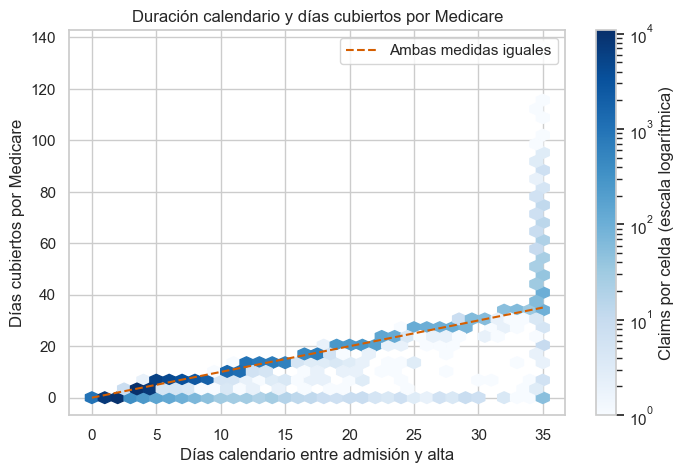

In [21]:
# Calculo la estancia hospitalaria y la comparo con los dias cubiertos por Medicare.
# La estancia es alta menos admision, sin sumar un dia.

inpatient_claims["HOSPITAL_STAY_DAYS"] = (
    inpatient_claims["DISCHARGE_DATE"]
    - inpatient_claims["ADMISSION_DATE"]
).dt.days

display(inpatient_claims["HOSPITAL_STAY_DAYS"].describe())



comparacion_dias = inpatient_claims[
    inpatient_claims["CLAIM_SEGMENT"] == 1
][
    ["HOSPITAL_STAY_DAYS", "COVERED_INPATIENT_DAYS"]
]

display(comparacion_dias.describe())


inpatient_claims["DAYS_DIFFERENCE"] = np.where(
    inpatient_claims["CLAIM_SEGMENT"] == 1,
    inpatient_claims["COVERED_INPATIENT_DAYS"]
    - inpatient_claims["HOSPITAL_STAY_DAYS"],
    np.nan
)

display(inpatient_claims["DAYS_DIFFERENCE"].value_counts().sort_index())



comparacion_dias = pd.Series({
    "IGUALES": (inpatient_claims["DAYS_DIFFERENCE"] == 0).sum(),
    "COVERED_DAYS_MAYOR": (inpatient_claims["DAYS_DIFFERENCE"] > 0).sum(),
    "COVERED_DAYS_MENOR": (inpatient_claims["DAYS_DIFFERENCE"] < 0).sum()
})

display(comparacion_dias)
# Comparacion con una fila por claim.
dias_para_grafico = inpatient_claims.loc[inpatient_claims["CLAIM_SEGMENT"].eq(1), ["HOSPITAL_STAY_DAYS", "COVERED_INPATIENT_DAYS"]]
fig, ax = plt.subplots(figsize=(8, 5))
mapa_dias = ax.hexbin(dias_para_grafico["HOSPITAL_STAY_DAYS"], dias_para_grafico["COVERED_INPATIENT_DAYS"], gridsize=35, mincnt=1, bins="log", cmap="Blues")
ax.plot([0, 35], [0, 35], color="#D55E00", linestyle="--", label="Ambas medidas iguales")
ax.set(title="Duración calendario y días cubiertos por Medicare", xlabel="Días calendario entre admisión y alta", ylabel="Días cubiertos por Medicare")
ax.legend()
fig.colorbar(mapa_dias, ax=ax, label="Claims por celda (escala logarítmica)")
plt.show()


HOSPITAL_STAY_DAYS es la diferencia entre alta y admisión, sin sumar un día. Cero puede corresponder a admisión y alta en la misma fecha. La mediana es cuatro días y la media 5,69.

Esta duración coincide con los días cubiertos en el 94,61 % de los claims. Se conservan las dos medidas: días calendario para describir la estancia y COVERED_INPATIENT_DAYS para calcular Medicare.

### 5.5. Correspondencia de beneficiarios

In [22]:
# Compruebo que los beneficiarios de Claims aparezcan en Beneficiary.
inpatient_patients = set(inpatient_claims["DESYNPUF_ID"].unique())
outpatient_patients = set(outpatient_claims["DESYNPUF_ID"].unique())
patients_ambos = inpatient_patients & outpatient_patients
solo_inpatient = inpatient_patients - outpatient_patients
solo_outpatient = outpatient_patients - inpatient_patients

print("Pacientes Inpatient:", len(inpatient_patients))
print("Pacientes Outpatient:", len(outpatient_patients))
print("En ambos:", len(patients_ambos))
print("Solo Inpatient:", len(solo_inpatient))
print("Solo Outpatient:", len(solo_outpatient))


beneficiary_patients = set(beneficiary["DESYNPUF_ID"].unique())



inpatient_sin_beneficiary = inpatient_patients - beneficiary_patients
outpatient_sin_beneficiary = outpatient_patients - beneficiary_patients

print("Pacientes Inpatient sin registro en Beneficiary:", len(inpatient_sin_beneficiary))
print("Pacientes Outpatient sin registro en Beneficiary:", len(outpatient_sin_beneficiary))


Pacientes Inpatient: 37780
Pacientes Outpatient: 85272
En ambos: 36314
Solo Inpatient: 1466
Solo Outpatient: 48958
Pacientes Inpatient sin registro en Beneficiary: 0
Pacientes Outpatient sin registro en Beneficiary: 0


Inpatient tiene 37.780 beneficiarios y Outpatient 85.272; comparten 36.314. Todos sus identificadores aparecen en Beneficiary.

## 6. Pagos Inpatient

El reembolso Medicare combina el pago del claim y los días cubiertos multiplicados por el pass-through diario. La responsabilidad del beneficiario suma deducible, coseguro de Part A y deducible por sangre. Otros pagadores conserva su importe original.

In [23]:


display(inpatient_claims[
    [
        "MEDICARE_CLAIM_PAYMENT",
        "OTHER_PAYER_CLAIM_PAYMENT",
        "PASS_THROUGH_DAILY_PAYMENT",
        "INPATIENT_BENEFICIARY_DEDUCTIBLE",
        "PART_A_BENEFICIARY_COINSURANCE",
        "BENEFICIARY_BLOOD_DEDUCTIBLE"
    ]
].describe())


,MEDICARE_CLAIM_PAYMENT,OTHER_PAYER_CLAIM_PAYMENT,PASS_THROUGH_DAILY_PAYMENT,INPATIENT_BENEFICIARY_DEDUCTIBLE,PART_A_BENEFICIARY_COINSURANCE,BENEFICIARY_BLOOD_DEDUCTIBLE
count,66773.000000,66773.000000,66773.000000,64595.000000,66773.000000,66773.000000
mean,9573.632756,398.899256,28.979228,1057.058844,90.028904,1.590313
std,9315.073232,3663.463023,75.606458,29.650916,1033.615068,40.163847
min,-8000.000000,0.000000,0.000000,1024.000000,0.000000,0.000000
25%,4000.000000,0.000000,0.000000,1024.000000,0.000000,0.000000
50%,7000.000000,0.000000,0.000000,1068.000000,0.000000,0.000000
75%,11000.000000,0.000000,10.000000,1068.000000,0.000000,0.000000
max,57000.000000,68000.000000,500.000000,1100.000000,34000.000000,2000.000000


### 6.1. Deducibles faltantes

Pruebo el deducible nulo como cero antes de incorporarlo a la fórmula. La comparación usa claims de una fila y deja afuera los beneficiario-año afectados por multisegmento.

In [24]:
# Preparo claims de un segmento para comprobar como tratar los deducibles faltantes.
# Base de validacion: claims de un solo segmento.

claims_un_segmento = cantidad_segmentos_inpatient[
    cantidad_segmentos_inpatient == 1
].index

inpatient_un_segmento = inpatient_claims[
    inpatient_claims["CLM_ID"].isin(claims_un_segmento)
]


columnas_financieras = [
    "MEDICARE_CLAIM_PAYMENT",
    "PASS_THROUGH_DAILY_PAYMENT",
    "COVERED_INPATIENT_DAYS",
    "INPATIENT_BENEFICIARY_DEDUCTIBLE",
    "PART_A_BENEFICIARY_COINSURANCE",
    "BENEFICIARY_BLOOD_DEDUCTIBLE",
    "OTHER_PAYER_CLAIM_PAYMENT"
]

display(inpatient_un_segmento[columnas_financieras].isna().sum())


deductible_nan = inpatient_un_segmento[
    inpatient_un_segmento["INPATIENT_BENEFICIARY_DEDUCTIBLE"].isna()
]

display(deductible_nan[
    [
        "PART_A_BENEFICIARY_COINSURANCE",
        "BENEFICIARY_BLOOD_DEDUCTIBLE"
    ]
].describe())

print(
    "Coinsurance > 0:",
    (deductible_nan["PART_A_BENEFICIARY_COINSURANCE"] > 0).sum()
)

print(
    "Blood deductible > 0:",
    (deductible_nan["BENEFICIARY_BLOOD_DEDUCTIBLE"] > 0).sum()
)

print(
    "Algún otro cargo del beneficiario > 0:",
    (
        (deductible_nan["PART_A_BENEFICIARY_COINSURANCE"] > 0) |
        (deductible_nan["BENEFICIARY_BLOOD_DEDUCTIBLE"] > 0)
    ).sum()
)

print(
    "Ambos en 0:",
    (
        (deductible_nan["PART_A_BENEFICIARY_COINSURANCE"] == 0) &
        (deductible_nan["BENEFICIARY_BLOOD_DEDUCTIBLE"] == 0)
    ).sum()
)

beneficiary_payment_check = inpatient_un_segmento.copy()

# Deducible cero solo para probar la hipotesis contra Beneficiary.
beneficiary_payment_check["BENEFICIARY_PAYMENT_TEST"] = (
    beneficiary_payment_check["INPATIENT_BENEFICIARY_DEDUCTIBLE"].fillna(0)
    + beneficiary_payment_check["PART_A_BENEFICIARY_COINSURANCE"]
    + beneficiary_payment_check["BENEFICIARY_BLOOD_DEDUCTIBLE"]
)

beneficiary_payment_check["END_YEAR"] = (
    beneficiary_payment_check["CLAIM_END_DATE"].dt.year
)

claims_multisegmento = cantidad_segmentos_inpatient[
    cantidad_segmentos_inpatient > 1
].index

inpatient_multisegmento = inpatient_claims[
    inpatient_claims["CLM_ID"].isin(claims_multisegmento)
].copy()


inpatient_multisegmento["END_YEAR"] = (
    inpatient_multisegmento["CLAIM_END_DATE"].dt.year
)

# Un multisegmento afecta el total de su beneficiario-año.
paciente_anio_multisegmento = (
    inpatient_multisegmento[
        ["DESYNPUF_ID", "END_YEAR"]
    ]
    .dropna()
    .drop_duplicates()
)

print("Claims multisegmento:", len(claims_multisegmento))
print("Paciente-año afectados:", len(paciente_anio_multisegmento))

display(paciente_anio_multisegmento["END_YEAR"].value_counts().sort_index())


MEDICARE_CLAIM_PAYMENT                 0
PASS_THROUGH_DAILY_PAYMENT             0
COVERED_INPATIENT_DAYS                 0
INPATIENT_BENEFICIARY_DEDUCTIBLE    2167
PART_A_BENEFICIARY_COINSURANCE         0
BENEFICIARY_BLOOD_DEDUCTIBLE           0
OTHER_PAYER_CLAIM_PAYMENT              0
dtype: int64

,PART_A_BENEFICIARY_COINSURANCE,BENEFICIARY_BLOOD_DEDUCTIBLE
count,2167.000000,2167.000000
mean,230.595293,0.350715
std,2003.538137,10.814764
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,34000.000000,400.000000


Coinsurance > 0: 84
Blood deductible > 0: 3
Algún otro cargo del beneficiario > 0: 87
Ambos en 0: 2080
Claims multisegmento: 68
Paciente-año afectados: 67


END_YEAR
2008.0    21
2009.0    32
2010.0    14
Name: count, dtype: int64

In [25]:
# Comparo los pagos del beneficiario con Beneficiary para evaluar el deducible nulo como cero.
pago_beneficiario_anual = (
    beneficiary_payment_check
    .groupby(
        ["DESYNPUF_ID", "END_YEAR"],
        as_index=False
    )
    ["BENEFICIARY_PAYMENT_TEST"]
    .sum()
)


pago_beneficiario_anual = pago_beneficiario_anual.merge(
    paciente_anio_multisegmento.assign(MULTI_SEGMENT=True),
    on=["DESYNPUF_ID", "END_YEAR"],
    how="left",
    validate="many_to_one"
)

# La validacion aparta totales anuales afectados por multisegmento.
pago_beneficiario_validacion = pago_beneficiario_anual[
    pago_beneficiario_anual["MULTI_SEGMENT"].isna()
].copy()

print("Paciente-año para validar:", len(pago_beneficiario_validacion))

comparacion_beneficiary_payment = pago_beneficiario_validacion.merge(
    beneficiary[
        [
            "DESYNPUF_ID",
            "YEAR",
            "INPATIENT_BENEFICIARY_PAYMENT"
        ]
    ],
    left_on=["DESYNPUF_ID", "END_YEAR"],
    right_on=["DESYNPUF_ID", "YEAR"],
    how="left",
    validate="many_to_one"
)

comparacion_beneficiary_payment["COINCIDE"] = (
    comparacion_beneficiary_payment["BENEFICIARY_PAYMENT_TEST"]
    == comparacion_beneficiary_payment["INPATIENT_BENEFICIARY_PAYMENT"]
)

print(
    comparacion_beneficiary_payment["COINCIDE"].value_counts()
)

print(
    "\nPorcentaje de coincidencia:",
    comparacion_beneficiary_payment["COINCIDE"].mean() * 100
)
# Subconjunto con al menos un deducible nulo.
paciente_anio_deductible_nan = (
    deductible_nan.assign(
        END_YEAR=deductible_nan["CLAIM_END_DATE"].dt.year
    )
    [["DESYNPUF_ID", "END_YEAR"]]
    .drop_duplicates()
)


comparacion_nan = comparacion_beneficiary_payment.merge(
    paciente_anio_deductible_nan.assign(HAS_DEDUCTIBLE_NAN=True),
    on=["DESYNPUF_ID", "END_YEAR"],
    how="inner",
    validate="many_to_one"
)

print("Paciente-año con deductible NaN:", len(comparacion_nan))

print(
    comparacion_nan["COINCIDE"].value_counts()
)

print(
    "\nPorcentaje de coincidencia:",
    comparacion_nan["COINCIDE"].mean() * 100
)
casos_no_coinciden = comparacion_nan[
    comparacion_nan["COINCIDE"] == False
].copy()

casos_no_coinciden["DIFERENCIA"] = (
    casos_no_coinciden["INPATIENT_BENEFICIARY_PAYMENT"]
    - casos_no_coinciden["BENEFICIARY_PAYMENT_TEST"]
)

display(casos_no_coinciden[
    [
        "BENEFICIARY_PAYMENT_TEST",
        "INPATIENT_BENEFICIARY_PAYMENT",
        "DIFERENCIA"
    ]
].describe())

nan_86 = deductible_nan.assign(
    END_YEAR=deductible_nan["CLAIM_END_DATE"].dt.year
).merge(
    casos_no_coinciden[
        ["DESYNPUF_ID", "END_YEAR"]
    ],
    on=["DESYNPUF_ID", "END_YEAR"],
    how="inner",
    validate="many_to_one"
)

print("Claims NaN dentro de los 86 casos:", len(nan_86))

print(
    "Con coinsurance > 0:",
    (nan_86["PART_A_BENEFICIARY_COINSURANCE"] > 0).sum()
)

print(
    "Con blood deductible > 0:",
    (nan_86["BENEFICIARY_BLOOD_DEDUCTIBLE"] > 0).sum()
)

print(
    "Con algún otro cargo > 0:",
    (
        (nan_86["PART_A_BENEFICIARY_COINSURANCE"] > 0) |
        (nan_86["BENEFICIARY_BLOOD_DEDUCTIBLE"] > 0)
    ).sum()
)


Paciente-año para validar: 46474


COINCIDE
True     46388
False       86
Name: count, dtype: int64

Porcentaje de coincidencia: 99.81495029478849
Paciente-año con deductible NaN: 1883
COINCIDE
True     1797
False      86
Name: count, dtype: int64

Porcentaje de coincidencia: 95.43281996813595


,BENEFICIARY_PAYMENT_TEST,INPATIENT_BENEFICIARY_PAYMENT,DIFERENCIA
count,86.000000,86.000000,86.000000
mean,8451.302326,2632.000000,-5819.302326
std,9226.467099,2725.077199,8341.135173
min,1084.000000,1024.000000,-34000.000000
25%,3100.000000,1068.000000,-5750.000000
50%,4584.000000,2048.000000,-3000.000000
75%,9120.000000,3072.000000,-1000.000000
max,47072.000000,14120.000000,-60.000000


Claims NaN dentro de los 86 casos: 123
Con coinsurance > 0: 84
Con blood deductible > 0: 3
Con algún otro cargo > 0: 87


Hay 2.167 claims de una fila con deducible vacío: 2.080 tienen los otros dos cargos en cero y 87 tienen algún cargo positivo. La prueba coincide con Beneficiary en 46.388 de 46.474 totales anuales (99,81 %). Entre los 1.883 beneficiario-año con algún deducible nulo, quedan 86 sin coincidencia.

Se admite cero en los casos respaldados por esta revisión. Los 87 claims con deducible nulo y otro cargo positivo se marcan con BENEFICIARY_PAYMENT_ISSUE: se excluye su responsabilidad del beneficiario, pero no Medicare ni otros pagadores.

### 6.2. Métricas y exclusiones

In [26]:
# Calculo los componentes de pago Inpatient y marco las exclusiones de cada componente.
inpatient_claims["IS_MULTI_SEGMENT"] = (
    inpatient_claims["CLM_ID"].isin(claims_multisegmento)
)

# Deducible nulo y otro cargo positivo: se excluye solo responsabilidad del beneficiario.
inpatient_claims["BENEFICIARY_PAYMENT_ISSUE"] = (
    inpatient_claims["INPATIENT_BENEFICIARY_DEDUCTIBLE"].isna()
    & (
        (inpatient_claims["PART_A_BENEFICIARY_COINSURANCE"] > 0)
        | (inpatient_claims["BENEFICIARY_BLOOD_DEDUCTIBLE"] > 0)
    )
)
print(inpatient_claims["IS_MULTI_SEGMENT"].value_counts())
print()
print(inpatient_claims["BENEFICIARY_PAYMENT_ISSUE"].value_counts())
# Los multisegmento quedan con NaN en los tres componentes.
inpatient_claims["MEDICARE_REIMBURSEMENT"] = np.where(
    ~inpatient_claims["IS_MULTI_SEGMENT"],
    inpatient_claims["MEDICARE_CLAIM_PAYMENT"]
    + (
        inpatient_claims["COVERED_INPATIENT_DAYS"]
        * inpatient_claims["PASS_THROUGH_DAILY_PAYMENT"]
    ),
    np.nan
)

display(inpatient_claims["MEDICARE_REIMBURSEMENT"].isna().sum())

inpatient_claims["BENEFICIARY_RESPONSIBILITY"] = np.where(
    (~inpatient_claims["IS_MULTI_SEGMENT"])
    & (~inpatient_claims["BENEFICIARY_PAYMENT_ISSUE"]),
    
    inpatient_claims["INPATIENT_BENEFICIARY_DEDUCTIBLE"].fillna(0)
    + inpatient_claims["PART_A_BENEFICIARY_COINSURANCE"]
    + inpatient_claims["BENEFICIARY_BLOOD_DEDUCTIBLE"],
    
    np.nan
)

display(inpatient_claims["BENEFICIARY_RESPONSIBILITY"].isna().sum())

display((
    inpatient_claims["IS_MULTI_SEGMENT"]
    & inpatient_claims["BENEFICIARY_PAYMENT_ISSUE"]
).sum())

inpatient_claims["OTHER_PAYER_PAYMENT"] = np.where(
    ~inpatient_claims["IS_MULTI_SEGMENT"],
    inpatient_claims["OTHER_PAYER_CLAIM_PAYMENT"],
    np.nan
)

display(inpatient_claims["OTHER_PAYER_PAYMENT"].isna().sum())

display(inpatient_claims[
    [
        "MEDICARE_REIMBURSEMENT",
        "BENEFICIARY_RESPONSIBILITY",
        "OTHER_PAYER_PAYMENT"
    ]
].describe())


IS_MULTI_SEGMENT
False    66637
True       136
Name: count, dtype: int64



BENEFICIARY_PAYMENT_ISSUE
False    66686
True        87
Name: count, dtype: int64


np.int64(136)

np.int64(223)

np.int64(0)

np.int64(136)

,MEDICARE_REIMBURSEMENT,BENEFICIARY_RESPONSIBILITY,OTHER_PAYER_PAYMENT
count,66637.000000,66550.000000,66637.000000
mean,9712.702102,1108.042044,398.422798
std,9423.440433,989.953394,3657.289107
min,-8000.000000,0.000000,0.000000
25%,4000.000000,1024.000000,0.000000
50%,7000.000000,1068.000000,0.000000
75%,11150.000000,1068.000000,0.000000
max,89000.000000,35100.000000,68000.000000


Los 68 multisegmento quedan con sus tres componentes financieros nulos. BENEFICIARY_PAYMENT_ISSUE afecta solo la responsabilidad del beneficiario. Se mantienen los registros y se distingue un pago cero de un importe excluido, que queda como NaN.

### 6.3. Año de inicio o finalización

Comparo ambos criterios con el mismo importe por claim. También separo los beneficiario-año sin multisegmento para contrastar totales completos con Beneficiary.

In [27]:
# Comparo el año de inicio y el de fin para elegir como asignar los pagos Inpatient.
# Mismos claims e importes para ambos criterios temporales.
inpatient_pago_por_claim = inpatient_claims.loc[
    ~inpatient_claims["IS_MULTI_SEGMENT"],
    ["CLM_ID", "DESYNPUF_ID", "CLAIM_START_DATE", "CLAIM_END_DATE",
     "MEDICARE_REIMBURSEMENT"]
].copy()
inpatient_pago_por_claim["START_YEAR"] = inpatient_pago_por_claim["CLAIM_START_DATE"].dt.year
inpatient_pago_por_claim["END_YEAR"] = inpatient_pago_por_claim["CLAIM_END_DATE"].dt.year
assert inpatient_pago_por_claim["CLM_ID"].is_unique
print("Claims de una sola fila:", len(inpatient_pago_por_claim))

resultados_temporales = []
for referencia, fecha in [("END_YEAR", "CLAIM_END_DATE"), ("START_YEAR", "CLAIM_START_DATE")]:
    anual = inpatient_pago_por_claim.groupby(
        ["DESYNPUF_ID", referencia], as_index=False
    )["MEDICARE_REIMBURSEMENT"].sum()
    afectados = inpatient_claims.loc[
        inpatient_claims["IS_MULTI_SEGMENT"] & inpatient_claims[fecha].notna(),
        ["DESYNPUF_ID", fecha]
    ].assign(**{referencia: lambda x: x[fecha].dt.year})[
        ["DESYNPUF_ID", referencia]
    ].drop_duplicates()
    comparacion = anual.merge(
        beneficiary[["DESYNPUF_ID", "YEAR", "INPATIENT_MEDICARE_PAYMENT"]],
        left_on=["DESYNPUF_ID", referencia], right_on=["DESYNPUF_ID", "YEAR"],
        how="left", validate="one_to_one"
    ).merge(
        afectados.assign(TOTAL_PARCIAL=True),
        on=["DESYNPUF_ID", referencia], how="left", validate="one_to_one"
    )
    comparacion["DIFFERENCE"] = comparacion["MEDICARE_REIMBURSEMENT"] - comparacion["INPATIENT_MEDICARE_PAYMENT"]
    if referencia == "END_YEAR":
        comparacion_end = comparacion
    else:
        comparacion_start = comparacion
    for alcance, tabla in [
        ("Todos los totales de claims de una fila", comparacion),
        ("Sin beneficiario-año multisegmento", comparacion.loc[comparacion["TOTAL_PARCIAL"].isna()])
    ]:
        resultados_temporales.append({
            "Referencia": referencia, "Alcance": alcance, "Filas": len(tabla),
            "Coincidencias": int(tabla["DIFFERENCE"].eq(0).sum()),
            "Porcentaje": round(tabla["DIFFERENCE"].eq(0).mean() * 100, 2),
            "Sin referencia Beneficiary": int(tabla["INPATIENT_MEDICARE_PAYMENT"].isna().sum())
        })
validacion_temporal = pd.DataFrame(resultados_temporales)
display(validacion_temporal)


Claims de una sola fila: 66637


,Referencia,Alcance,Filas,Coincidencias,Porcentaje,Sin referencia Beneficiary
0,END_YEAR,Todos los totales de claims de una fila,46504,46476,99.94,0
1,END_YEAR,Sin beneficiario-año multisegmento,46474,46474,100.00,0
2,START_YEAR,Todos los totales de claims de una fila,46584,45235,97.10,214
3,START_YEAR,Sin beneficiario-año multisegmento,46554,45232,97.16,214


Sin multisegmento, END_YEAR coincide en los 46.474 casos. START_YEAR coincide en 45.232 de 46.554 (97,16 %) y tiene 214 casos sin referencia anual. Por ese resultado, se adopta CLAIM_END_DATE para asignar el año.

Los porcentajes anteriores de 99,86 % y 97,02 % usaban otra cohorte y alternativas de consolidación. La tabla anterior corresponde a la base financiera final.

## 7. Pagos Outpatient

### 7.1. Comparación de segmentos

In [28]:
# Reviso si los importes Outpatient se repiten entre segmentos.
columnas_financieras_outpatient = [
    "MEDICARE_CLAIM_PAYMENT",
    "PART_B_BENEFICIARY_DEDUCTIBLE",
    "PART_B_BENEFICIARY_COINSURANCE",
    "BENEFICIARY_BLOOD_DEDUCTIBLE",
    "OTHER_PAYER_CLAIM_PAYMENT"
]

print(outpatient_claims[columnas_financieras_outpatient].isna().sum())

display(outpatient_claims[columnas_financieras_outpatient].describe())

cantidad_segmentos_outpatient = (
    outpatient_claims.groupby("CLM_ID")["CLAIM_SEGMENT"].count()
)

claims_multisegmento_outpatient = cantidad_segmentos_outpatient[
    cantidad_segmentos_outpatient > 1
].index

outpatient_multisegmento = outpatient_claims[
    outpatient_claims["CLM_ID"].isin(claims_multisegmento_outpatient)
].copy()

display(cantidad_segmentos_outpatient.value_counts().sort_index())
segmento_1 = (
    outpatient_multisegmento[
        outpatient_multisegmento["CLAIM_SEGMENT"] == 1
    ]
    .set_index("CLM_ID")[columnas_financieras_outpatient]
)

segmento_2 = (
    outpatient_multisegmento[
        outpatient_multisegmento["CLAIM_SEGMENT"] == 2
    ]
    .set_index("CLM_ID")[columnas_financieras_outpatient]
)

# La comparacion se alinea por CLM_ID.
assert segmento_1.index.is_unique and segmento_2.index.is_unique, (
    "Hay más de una fila para un mismo claim y segmento; revisar antes de comparar."
)
segmento_1, segmento_2 = segmento_1.align(segmento_2, join="inner", axis=0)

for columna in columnas_financieras_outpatient:
    iguales = (segmento_1[columna] == segmento_2[columna]).sum()
    diferentes = (segmento_1[columna] != segmento_2[columna]).sum()

    print(columna)
    print("Iguales:", iguales)
    print("Diferentes:", diferentes)
    print()


MEDICARE_CLAIM_PAYMENT            0
PART_B_BENEFICIARY_DEDUCTIBLE     0
PART_B_BENEFICIARY_COINSURANCE    0
BENEFICIARY_BLOOD_DEDUCTIBLE      0
OTHER_PAYER_CLAIM_PAYMENT         0
dtype: int64


,MEDICARE_CLAIM_PAYMENT,PART_B_BENEFICIARY_DEDUCTIBLE,PART_B_BENEFICIARY_COINSURANCE,BENEFICIARY_BLOOD_DEDUCTIBLE,OTHER_PAYER_CLAIM_PAYMENT
count,790790.000000,790790.000000,790790.000000,790790.000000,790790.000000
mean,283.924569,2.825466,83.845876,0.012898,10.239760
std,571.392794,15.596522,178.759708,2.315506,234.668372
min,-100.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,0.000000,0.000000,0.000000,0.000000
50%,80.000000,0.000000,20.000000,0.000000,0.000000
75%,200.000000,0.000000,70.000000,0.000000,0.000000
max,3300.000000,200.000000,1100.000000,800.000000,14000.000000


CLAIM_SEGMENT
1    768840
2     10975
Name: count, dtype: int64

MEDICARE_CLAIM_PAYMENT
Iguales: 618
Diferentes: 10357

PART_B_BENEFICIARY_DEDUCTIBLE
Iguales: 10409
Diferentes: 566

PART_B_BENEFICIARY_COINSURANCE
Iguales: 1519
Diferentes: 9456

BENEFICIARY_BLOOD_DEDUCTIBLE
Iguales: 10974
Diferentes: 1

OTHER_PAYER_CLAIM_PAYMENT
Iguales: 10875
Diferentes: 100



### 7.2. Conciliación con Beneficiary

In [29]:
# Compruebo si el pago del segmento 1 reproduce el total anual de Beneficiary.
outpatient_segmento_1 = (
    outpatient_claims[
        outpatient_claims["CLAIM_SEGMENT"] == 1
    ]
    .copy()
)

outpatient_segmento_1["END_YEAR"] = (
    outpatient_segmento_1["CLAIM_END_DATE"].dt.year
)

outpatient_anual_segmento_1 = (
    outpatient_segmento_1
    .dropna(subset=["END_YEAR"])
    .groupby(["DESYNPUF_ID", "END_YEAR"], as_index=False)
    ["MEDICARE_CLAIM_PAYMENT"].sum()
)

comparacion_segmento_1 = outpatient_anual_segmento_1.merge(
    beneficiary[
        ["DESYNPUF_ID", "YEAR", "OUTPATIENT_MEDICARE_PAYMENT"]
    ],
    left_on=["DESYNPUF_ID", "END_YEAR"],
    right_on=["DESYNPUF_ID", "YEAR"],
    how="inner",
    validate="many_to_one"
)

comparacion_segmento_1["COINCIDE"] = (
    comparacion_segmento_1["MEDICARE_CLAIM_PAYMENT"]
    == comparacion_segmento_1["OUTPATIENT_MEDICARE_PAYMENT"]
)

display(comparacion_segmento_1["COINCIDE"].value_counts())


COINCIDE
True    186493
Name: count, dtype: int64

In [30]:
# Contrasto la suma de ambos segmentos con el resultado del segmento 1.
# Sumar segmentos es la alternativa que se contrasta con segmento 1.
outpatient_anual = (
    outpatient_claims[["CLM_ID", "DESYNPUF_ID", "MEDICARE_CLAIM_PAYMENT"]].merge(
        outpatient_segmento_1[["CLM_ID", "END_YEAR"]],
        on="CLM_ID", how="left", validate="many_to_one"
    )
    .groupby(["DESYNPUF_ID", "END_YEAR"], as_index=False)
    ["MEDICARE_CLAIM_PAYMENT"].sum()
)
comparacion_outpatient = outpatient_anual.merge(
    beneficiary[["DESYNPUF_ID", "YEAR", "OUTPATIENT_MEDICARE_PAYMENT"]],
    left_on=["DESYNPUF_ID", "END_YEAR"], right_on=["DESYNPUF_ID", "YEAR"],
    how="left", validate="one_to_one"
)
comparacion_outpatient["COINCIDE"] = (
    comparacion_outpatient["MEDICARE_CLAIM_PAYMENT"]
    == comparacion_outpatient["OUTPATIENT_MEDICARE_PAYMENT"]
)
display(comparacion_outpatient["COINCIDE"].value_counts())
assert len(comparacion_outpatient) == len(outpatient_anual)


COINCIDE
True     180019
False      6474
Name: count, dtype: int64

In [31]:
# Valido tambien los pagos del beneficiario y de otros pagadores usando el segmento 1.
# Responsabilidad del beneficiario y otros pagadores usan tambien segmento 1.
outpatient_segmento_1["BENEFICIARY_RESPONSIBILITY"] = (
    outpatient_segmento_1["PART_B_BENEFICIARY_DEDUCTIBLE"]
    + outpatient_segmento_1["PART_B_BENEFICIARY_COINSURANCE"]
    + outpatient_segmento_1["BENEFICIARY_BLOOD_DEDUCTIBLE"]
)


beneficiary_outpatient_anual = (
    outpatient_segmento_1
    .groupby(["DESYNPUF_ID", "END_YEAR"], as_index=False)
    ["BENEFICIARY_RESPONSIBILITY"].sum()
)


comparacion_beneficiary_outpatient = beneficiary_outpatient_anual.merge(
    beneficiary[
        ["DESYNPUF_ID", "YEAR", "OUTPATIENT_BENEFICIARY_PAYMENT"]
    ],
    left_on=["DESYNPUF_ID", "END_YEAR"],
    right_on=["DESYNPUF_ID", "YEAR"],
    how="inner",
    validate="many_to_one"
)

comparacion_beneficiary_outpatient["COINCIDE"] = (
    comparacion_beneficiary_outpatient["BENEFICIARY_RESPONSIBILITY"]
    == comparacion_beneficiary_outpatient["OUTPATIENT_BENEFICIARY_PAYMENT"]
)

display(comparacion_beneficiary_outpatient["COINCIDE"].value_counts())

outpatient_other_payer_anual = (
    outpatient_segmento_1.groupby(["DESYNPUF_ID", "END_YEAR"], as_index=False)
    ["OTHER_PAYER_CLAIM_PAYMENT"].sum()
)
comparacion_other_payer = outpatient_other_payer_anual.merge(
    beneficiary[["DESYNPUF_ID", "YEAR", "OUTPATIENT_OTHER_PAYER_PAYMENT"]],
    left_on=["DESYNPUF_ID", "END_YEAR"], right_on=["DESYNPUF_ID", "YEAR"],
    how="left", validate="one_to_one"
)
comparacion_other_payer["DIFERENCIA"] = (
    comparacion_other_payer["OTHER_PAYER_CLAIM_PAYMENT"]
    - comparacion_other_payer["OUTPATIENT_OTHER_PAYER_PAYMENT"]
)
resumen_other_payer = pd.Series({
    "Beneficiario-año comparados": len(comparacion_other_payer),
    "Coincidencias exactas": comparacion_other_payer["DIFERENCIA"].eq(0).sum(),
    "Diferencias": comparacion_other_payer["DIFERENCIA"].ne(0).sum(),
    "Sin referencia Beneficiary": comparacion_other_payer["OUTPATIENT_OTHER_PAYER_PAYMENT"].isna().sum(),
    "Porcentaje de coincidencia": comparacion_other_payer["DIFERENCIA"].eq(0).mean() * 100,
    "Máxima diferencia absoluta": comparacion_other_payer["DIFERENCIA"].abs().max(),
    "Suma de diferencias absolutas": comparacion_other_payer["DIFERENCIA"].abs().sum()
})
display(resumen_other_payer)
assert len(comparacion_other_payer) == len(outpatient_other_payer_anual)


COINCIDE
True    186493
Name: count, dtype: int64

Beneficiario-año comparados      186493.0
Coincidencias exactas            186493.0
Diferencias                           0.0
Sin referencia Beneficiary            0.0
Porcentaje de coincidencia          100.0
Máxima diferencia absoluta            0.0
Suma de diferencias absolutas         0.0
dtype: float64

Al sumar ambos segmentos quedan 6.474 beneficiario-año con diferencias. Con el segmento 1 coinciden los 186.493 totales anuales comparados en los tres componentes. Por eso, los pagos finales se toman del segmento 1.

### 7.3. Regla financiera y exclusiones

In [32]:
# Conservo los claims sin segmento 1 y marco sus pagos finales como faltantes.
claims_solo_segmento_2 = outpatient_claims[
    (outpatient_claims["CLAIM_SEGMENT"] == 2)
    & (~outpatient_claims["CLM_ID"].isin(
        outpatient_claims.loc[
            outpatient_claims["CLAIM_SEGMENT"] == 1,
            "CLM_ID"
        ]
    ))
].copy()

display(claims_solo_segmento_2[
    columnas_financieras_outpatient
].describe())

# Los claims sin segmento 1 quedan sin fecha ni importes finales.
outpatient_claims["MISSING_SEGMENT_1"] = (
    ~outpatient_claims["CLM_ID"].isin(
        outpatient_claims.loc[
            outpatient_claims["CLAIM_SEGMENT"] == 1,
            "CLM_ID"
        ]
    )
)

display(outpatient_claims["MISSING_SEGMENT_1"].value_counts())


outpatient_claims["MEDICARE_REIMBURSEMENT"] = np.where(
    outpatient_claims["CLAIM_SEGMENT"] == 1,
    outpatient_claims["MEDICARE_CLAIM_PAYMENT"],
    np.nan
)

outpatient_claims["BENEFICIARY_RESPONSIBILITY"] = np.where(
    outpatient_claims["CLAIM_SEGMENT"] == 1,
    outpatient_claims["PART_B_BENEFICIARY_DEDUCTIBLE"]
    + outpatient_claims["PART_B_BENEFICIARY_COINSURANCE"]
    + outpatient_claims["BENEFICIARY_BLOOD_DEDUCTIBLE"],
    np.nan
)

outpatient_claims["OTHER_PAYER_PAYMENT"] = np.where(
    outpatient_claims["CLAIM_SEGMENT"] == 1,
    outpatient_claims["OTHER_PAYER_CLAIM_PAYMENT"],
    np.nan
)

display(outpatient_claims[
    [
        "MEDICARE_REIMBURSEMENT",
        "BENEFICIARY_RESPONSIBILITY",
        "OTHER_PAYER_PAYMENT"
    ]
].isna().sum())

display(outpatient_claims[
    [
        "MEDICARE_REIMBURSEMENT",
        "BENEFICIARY_RESPONSIBILITY",
        "OTHER_PAYER_PAYMENT"
    ]
].describe())


outpatient_claims["FINANCIAL_ROW_EXCLUDED"] = (
    outpatient_claims["CLAIM_SEGMENT"] != 1
)

display(outpatient_claims[
    ["MISSING_SEGMENT_1", "FINANCIAL_ROW_EXCLUDED"]
].value_counts())


,MEDICARE_CLAIM_PAYMENT,PART_B_BENEFICIARY_DEDUCTIBLE,PART_B_BENEFICIARY_COINSURANCE,BENEFICIARY_BLOOD_DEDUCTIBLE,OTHER_PAYER_CLAIM_PAYMENT
count,278.000000,278.000000,278.000000,278.0,278.000000
mean,1411.223022,1.187050,363.165468,0.0,3.597122
std,1084.852357,10.144849,308.604723,0.0,59.976014
min,0.000000,0.000000,0.000000,0.0,0.000000
25%,200.000000,0.000000,50.000000,0.0,0.000000
50%,1600.000000,0.000000,400.000000,0.0,0.000000
75%,2275.000000,0.000000,600.000000,0.0,0.000000
max,3300.000000,100.000000,1100.000000,0.0,1000.000000


MISSING_SEGMENT_1
False    790512
True        278
Name: count, dtype: int64

MEDICARE_REIMBURSEMENT        11253
BENEFICIARY_RESPONSIBILITY    11253
OTHER_PAYER_PAYMENT           11253
dtype: int64

,MEDICARE_REIMBURSEMENT,BENEFICIARY_RESPONSIBILITY,OTHER_PAYER_PAYMENT
count,779537.000000,779537.000000,779537.000000
mean,268.482894,82.731288,10.271135
std,545.063258,173.931272,234.604218
min,-100.000000,0.000000,0.000000
25%,40.000000,0.000000,0.000000
50%,70.000000,20.000000,0.000000
75%,200.000000,80.000000,0.000000
max,3300.000000,1300.000000,14000.000000


MISSING_SEGMENT_1  FINANCIAL_ROW_EXCLUDED
False              False                     779537
                   True                       10975
True               True                         278
Name: count, dtype: int64

FINANCIAL_ROW_EXCLUDED marca las 11.253 filas de segmento 2. MISSING_SEGMENT_1 identifica los 278 claims sin segmento 1 ni fechas. Estos últimos siguen en la tabla final con pagos nulos y fuera de los indicadores anuales.

## 8. Integración y tablas analíticas

### 8.1. Utilización

Cuento claims distintos por beneficiario y año de fin, incluidos los multisegmento Inpatient. Si no hay claims fechados, el conteo queda en cero.

In [33]:
beneficiary["CHRONIC_CONDITION_COUNT"] = (
    beneficiary[chronic_conditions]
    .eq("Yes")
    .sum(axis=1)
)

display(beneficiary["CHRONIC_CONDITION_COUNT"].value_counts().sort_index())


CHRONIC_CONDITION_COUNT
0     125983
1      44306
2      41353
3      36871
4      31253
5      24639
6      17785
7      11688
8       6366
9       2613
10       701
11        86
Name: count, dtype: int64

In [34]:
# Cuento claims distintos por beneficiario y año, incluidos los pagos excluidos.
# Utilizacion: claims distintos, incluidos los que tienen pagos excluidos.

inpatient_utilizacion = (
    inpatient_claims[
        inpatient_claims["CLAIM_END_DATE"].notna()
    ]
    .assign(
        END_YEAR=lambda x: x["CLAIM_END_DATE"].dt.year
    )
    .groupby(
        ["DESYNPUF_ID", "END_YEAR"],
        as_index=False
    )["CLM_ID"]
    .nunique()
    .rename(columns={
        "CLM_ID": "INPATIENT_CLAIMS"
    })
)

display(inpatient_utilizacion.head())



beneficiary_utilizacion = beneficiary.merge(
    inpatient_utilizacion,
    left_on=["DESYNPUF_ID", "YEAR"],
    right_on=["DESYNPUF_ID", "END_YEAR"],
    how="left",
    validate="many_to_one"
)

# Ausencia de claims fechados recibe conteo cero.
beneficiary_utilizacion["INPATIENT_CLAIMS"] = (
    beneficiary_utilizacion["INPATIENT_CLAIMS"]
    .fillna(0)
    .astype(int)
)

display(beneficiary_utilizacion[
    ["DESYNPUF_ID", "YEAR", "CHRONIC_CONDITION_COUNT", "INPATIENT_CLAIMS"]
].head())


outpatient_utilizacion = (
    outpatient_claims[
        outpatient_claims["CLAIM_END_DATE"].notna()
    ]
    .assign(
        END_YEAR=lambda x: x["CLAIM_END_DATE"].dt.year
    )
    .groupby(
        ["DESYNPUF_ID", "END_YEAR"],
        as_index=False
    )["CLM_ID"]
    .nunique()
    .rename(columns={
        "CLM_ID": "OUTPATIENT_CLAIMS"
    })
)

display(outpatient_utilizacion.head())



beneficiary_utilizacion = beneficiary_utilizacion.merge(
    outpatient_utilizacion,
    left_on=["DESYNPUF_ID", "YEAR"],
    right_on=["DESYNPUF_ID", "END_YEAR"],
    how="left",
    suffixes=("", "_OUTPATIENT"),
    validate="many_to_one"
)

# El mismo criterio de conteo cero se aplica a Outpatient.
beneficiary_utilizacion["OUTPATIENT_CLAIMS"] = (
    beneficiary_utilizacion["OUTPATIENT_CLAIMS"]
    .fillna(0)
    .astype(int)
)

display(beneficiary_utilizacion[
    [
        "DESYNPUF_ID",
        "YEAR",
        "CHRONIC_CONDITION_COUNT",
        "INPATIENT_CLAIMS",
        "OUTPATIENT_CLAIMS"
    ]
].head())
assert len(beneficiary_utilizacion) == filas_originales["beneficiary"]
assert not beneficiary_utilizacion.duplicated(["DESYNPUF_ID", "YEAR"]).any()
print("Beneficiario/año:", len(beneficiary_utilizacion), "sin multiplicación de registros")


,DESYNPUF_ID,END_YEAR,INPATIENT_CLAIMS
0,00013D2EFD8E45D1,2010,1
1,00016F745862898F,2009,3
2,00016F745862898F,2010,1
3,00052705243EA128,2008,1
4,0007F12A492FD25D,2008,1


,DESYNPUF_ID,YEAR,CHRONIC_CONDITION_COUNT,INPATIENT_CLAIMS
0,00013D2EFD8E45D1,2008,0,0
1,00016F745862898F,2008,0,0
2,0001FDD721E223DC,2008,0,0
3,00021CA6FF03E670,2008,0,0
4,00024B3D2352D2D0,2008,1,0


,DESYNPUF_ID,END_YEAR,OUTPATIENT_CLAIMS
0,00013D2EFD8E45D1,2008,1
1,00016F745862898F,2009,2
2,0001FDD721E223DC,2009,1
3,00024B3D2352D2D0,2008,1
4,00024B3D2352D2D0,2009,2


,DESYNPUF_ID,YEAR,CHRONIC_CONDITION_COUNT,INPATIENT_CLAIMS,OUTPATIENT_CLAIMS
0,00013D2EFD8E45D1,2008,0,0,1
1,00016F745862898F,2008,0,0,0
2,0001FDD721E223DC,2008,0,0,0
3,00021CA6FF03E670,2008,0,0,0
4,00024B3D2352D2D0,2008,1,0,1


Beneficiario/año: 343644 sin multiplicación de registros


### 8.2. Pagos anuales y completitud

Beneficiary aporta los pagos anuales. Las sumas reconstruidas de Claims sirven para contrastarlos; los flags avisan cuando una exclusión deja incompleto un componente.

In [35]:
# Sumo los pagos Inpatient por año y marco los componentes que quedan incompletos.
# min_count=1 conserva NaN si no queda ningun importe disponible.
inpatient_costos = (
    inpatient_claims.loc[inpatient_claims["CLAIM_END_DATE"].notna()]
    .assign(END_YEAR=lambda x: x["CLAIM_END_DATE"].dt.year)
    .groupby(["DESYNPUF_ID", "END_YEAR"], as_index=False)
    .agg(
        INPATIENT_MEDICARE_PAYMENT=("MEDICARE_REIMBURSEMENT", lambda x: x.sum(min_count=1)),
        INPATIENT_BENEFICIARY_PAYMENT=("BENEFICIARY_RESPONSIBILITY", lambda x: x.sum(min_count=1)),
        INPATIENT_OTHER_PAYER_PAYMENT=("OTHER_PAYER_PAYMENT", lambda x: x.sum(min_count=1)),
        INPATIENT_MEDICARE_COMPLETE=("MEDICARE_REIMBURSEMENT", lambda x: x.notna().all()),
        INPATIENT_BENEFICIARY_COMPLETE=("BENEFICIARY_RESPONSIBILITY", lambda x: x.notna().all()),
        INPATIENT_OTHER_PAYER_COMPLETE=("OTHER_PAYER_PAYMENT", lambda x: x.notna().all())
    )
)
flags_completitud = ["INPATIENT_MEDICARE_COMPLETE", "INPATIENT_BENEFICIARY_COMPLETE",
                     "INPATIENT_OTHER_PAYER_COMPLETE"]
print("Beneficiario/año con componentes incompletos:")
display(inpatient_costos[flags_completitud].eq(False).sum())
assert inpatient_costos[flags_completitud].eq(False).sum().tolist() == [67, 153, 67]
assert not inpatient_costos.duplicated(["DESYNPUF_ID", "END_YEAR"]).any()


beneficiary_utilizacion = beneficiary_utilizacion.merge(
    inpatient_costos.rename(columns={'INPATIENT_MEDICARE_PAYMENT': 'INPATIENT_MEDICARE_PAYMENT_CLAIMS', 'INPATIENT_BENEFICIARY_PAYMENT': 'INPATIENT_BENEFICIARY_PAYMENT_CLAIMS', 'INPATIENT_OTHER_PAYER_PAYMENT': 'INPATIENT_OTHER_PAYER_PAYMENT_CLAIMS'}),
    left_on=["DESYNPUF_ID", "YEAR"],
    right_on=["DESYNPUF_ID", "END_YEAR"],
    how="left",
    suffixes=("", "_COSTOS_INPATIENT"),
    validate="many_to_one"
)


columnas_costos_inpatient = [
    "INPATIENT_MEDICARE_PAYMENT_CLAIMS",
    "INPATIENT_BENEFICIARY_PAYMENT_CLAIMS",
    "INPATIENT_OTHER_PAYER_PAYMENT_CLAIMS"
]

# Cero solo cuando no hay claims fechados; las exclusiones mantienen NaN.
beneficiary_utilizacion.loc[
    beneficiary_utilizacion["INPATIENT_CLAIMS"].eq(0), columnas_costos_inpatient
] = 0

display(beneficiary_utilizacion[
    [
        "DESYNPUF_ID",
        "YEAR",
        "CHRONIC_CONDITION_COUNT",
        "INPATIENT_CLAIMS",
        "INPATIENT_MEDICARE_PAYMENT_CLAIMS",
        "INPATIENT_BENEFICIARY_PAYMENT_CLAIMS",
        "INPATIENT_OTHER_PAYER_PAYMENT_CLAIMS"
    ]
].head())


Beneficiario/año con componentes incompletos:


INPATIENT_MEDICARE_COMPLETE        67
INPATIENT_BENEFICIARY_COMPLETE    153
INPATIENT_OTHER_PAYER_COMPLETE     67
dtype: int64

,DESYNPUF_ID,YEAR,CHRONIC_CONDITION_COUNT,INPATIENT_CLAIMS,INPATIENT_MEDICARE_PAYMENT_CLAIMS,INPATIENT_BENEFICIARY_PAYMENT_CLAIMS,INPATIENT_OTHER_PAYER_PAYMENT_CLAIMS
0,00013D2EFD8E45D1,2008,0,0,0.0,0.0,0.0
1,00016F745862898F,2008,0,0,0.0,0.0,0.0
2,0001FDD721E223DC,2008,0,0,0.0,0.0,0.0
3,00021CA6FF03E670,2008,0,0,0.0,0.0,0.0
4,00024B3D2352D2D0,2008,1,0,0.0,0.0,0.0


In [36]:
# Sumo los pagos Outpatient del segmento 1 y los uno a Beneficiary sin multiplicar filas.
outpatient_costos = (
    outpatient_claims[
        (outpatient_claims["CLAIM_SEGMENT"] == 1)
        & (outpatient_claims["CLAIM_END_DATE"].notna())
    ]
    .assign(
        END_YEAR=lambda x: x["CLAIM_END_DATE"].dt.year
    )
    .groupby(
        ["DESYNPUF_ID", "END_YEAR"],
        as_index=False
    )
    .agg(
        OUTPATIENT_MEDICARE_PAYMENT=("MEDICARE_REIMBURSEMENT", "sum"),
        OUTPATIENT_BENEFICIARY_PAYMENT=("BENEFICIARY_RESPONSIBILITY", "sum"),
        OUTPATIENT_OTHER_PAYER_PAYMENT=("OTHER_PAYER_PAYMENT", "sum")
    )
)

display(outpatient_costos.head())


beneficiary_utilizacion = beneficiary_utilizacion.merge(
    outpatient_costos.rename(columns={'OUTPATIENT_MEDICARE_PAYMENT': 'OUTPATIENT_MEDICARE_PAYMENT_CLAIMS', 'OUTPATIENT_BENEFICIARY_PAYMENT': 'OUTPATIENT_BENEFICIARY_PAYMENT_CLAIMS', 'OUTPATIENT_OTHER_PAYER_PAYMENT': 'OUTPATIENT_OTHER_PAYER_PAYMENT_CLAIMS'}),
    left_on=["DESYNPUF_ID", "YEAR"],
    right_on=["DESYNPUF_ID", "END_YEAR"],
    how="left",
    suffixes=("", "_COSTOS_OUTPATIENT"),
    validate="many_to_one"
)


columnas_costos_outpatient = [
    "OUTPATIENT_MEDICARE_PAYMENT_CLAIMS",
    "OUTPATIENT_BENEFICIARY_PAYMENT_CLAIMS",
    "OUTPATIENT_OTHER_PAYER_PAYMENT_CLAIMS"
]

beneficiary_utilizacion[columnas_costos_outpatient] = (
    beneficiary_utilizacion[columnas_costos_outpatient].fillna(0)
)

display(beneficiary_utilizacion[
    [
        "DESYNPUF_ID",
        "YEAR",
        "CHRONIC_CONDITION_COUNT",
        "OUTPATIENT_CLAIMS",
        "OUTPATIENT_MEDICARE_PAYMENT_CLAIMS",
        "OUTPATIENT_BENEFICIARY_PAYMENT_CLAIMS",
        "OUTPATIENT_OTHER_PAYER_PAYMENT_CLAIMS"
    ]
].head())
# La ausencia de claims no genera un total Inpatient incompleto.
beneficiary_utilizacion[flags_completitud] = (
    beneficiary_utilizacion[flags_completitud].astype("boolean").fillna(True)
)
assert len(beneficiary_utilizacion) == filas_originales["beneficiary"]
assert not beneficiary_utilizacion.duplicated(["DESYNPUF_ID", "YEAR"]).any()
assert len(inpatient_claims) == filas_originales["inpatient"]
assert len(outpatient_claims) == filas_originales["outpatient"]
print("Filas originales conservadas; tabla beneficiario/año sin duplicados")


,DESYNPUF_ID,END_YEAR,OUTPATIENT_MEDICARE_PAYMENT,OUTPATIENT_BENEFICIARY_PAYMENT,OUTPATIENT_OTHER_PAYER_PAYMENT
0,00013D2EFD8E45D1,2008,50.0,10.0,0.0
1,00016F745862898F,2009,60.0,70.0,0.0
2,0001FDD721E223DC,2009,30.0,50.0,0.0
3,00024B3D2352D2D0,2008,30.0,40.0,0.0
4,00024B3D2352D2D0,2009,90.0,40.0,0.0


,DESYNPUF_ID,YEAR,CHRONIC_CONDITION_COUNT,OUTPATIENT_CLAIMS,OUTPATIENT_MEDICARE_PAYMENT_CLAIMS,OUTPATIENT_BENEFICIARY_PAYMENT_CLAIMS,OUTPATIENT_OTHER_PAYER_PAYMENT_CLAIMS
0,00013D2EFD8E45D1,2008,0,1,50.0,10.0,0.0
1,00016F745862898F,2008,0,0,0.0,0.0,0.0
2,0001FDD721E223DC,2008,0,0,0.0,0.0,0.0
3,00021CA6FF03E670,2008,0,0,0.0,0.0,0.0
4,00024B3D2352D2D0,2008,1,1,30.0,40.0,0.0


Filas originales conservadas; tabla beneficiario/año sin duplicados


Inpatient tiene 67 beneficiario-año incompletos para Medicare y otros pagadores, y 153 para responsabilidad del beneficiario. Si todos los importes están excluidos, la suma queda nula. Cero se asigna cuando no hay claims fechados.

Para usar un total anual reconstruido completo, debe cumplirse el flag de ese componente. Los pagos originales de Beneficiary se mantienen.

### 8.3. Tablas finales

In [37]:
# Creo las tablas con una fila por claim y agrego el contexto del beneficiario.
# Una fila por claim; los importes multisegmento siguen excluidos.
columnas_inpatient_final = [
    "CLM_ID", "DESYNPUF_ID", "CLAIM_START_DATE", "CLAIM_END_DATE",
    "ADMISSION_DATE", "DISCHARGE_DATE", "PROVIDER_ID", "DIAGNOSIS_RELATED_GROUP",
    "HOSPITAL_STAY_DAYS", "COVERED_INPATIENT_DAYS", "MEDICARE_REIMBURSEMENT",
    "BENEFICIARY_RESPONSIBILITY", "OTHER_PAYER_PAYMENT", "IS_MULTI_SEGMENT",
    "BENEFICIARY_PAYMENT_ISSUE"
]
inpatient_claim = inpatient_claims.loc[
    inpatient_claims["CLAIM_SEGMENT"].eq(1), columnas_inpatient_final
].copy()

# Tambien se conservan los claims sin segmento 1.
columnas_outpatient_final = [
    "CLM_ID", "DESYNPUF_ID", "CLAIM_START_DATE", "CLAIM_END_DATE", "PROVIDER_ID",
    "MEDICARE_REIMBURSEMENT", "BENEFICIARY_RESPONSIBILITY", "OTHER_PAYER_PAYMENT",
    "MISSING_SEGMENT_1"
]
outpatient_claim = outpatient_claims.loc[
    outpatient_claims["CLAIM_SEGMENT"].eq(1) | outpatient_claims["MISSING_SEGMENT_1"],
    columnas_outpatient_final
].copy()

# Contexto del beneficiario en el año de fin.
contexto_beneficiario = beneficiary[[
    "DESYNPUF_ID", "YEAR", "AGE", "SEX", "RACE", "END_STAGE_RENAL_DISEASE",
    "CHRONIC_CONDITION_COUNT", "State", "County", "FIPS_CODE"
]]
for nombre, tabla in [("Inpatient", inpatient_claim), ("Outpatient", outpatient_claim)]:
    tabla["CLM_ID"] = tabla["CLM_ID"].astype("string")
    tabla["ANALYSIS_YEAR"] = tabla["CLAIM_END_DATE"].dt.year.astype("Int64")
    tabla["UTILIZATION_VALID"] = tabla["CLAIM_END_DATE"].notna()
    assert tabla["CLM_ID"].is_unique
    assert len(tabla) == (inpatient_claims if nombre == "Inpatient" else outpatient_claims)["CLM_ID"].nunique()

inpatient_claim = inpatient_claim.merge(
    contexto_beneficiario.rename(columns={"YEAR": "ANALYSIS_YEAR"}),
    on=["DESYNPUF_ID", "ANALYSIS_YEAR"], how="left", validate="many_to_one"
)
outpatient_claim = outpatient_claim.merge(
    contexto_beneficiario.rename(columns={"YEAR": "ANALYSIS_YEAR"}),
    on=["DESYNPUF_ID", "ANALYSIS_YEAR"], how="left", validate="many_to_one"
)
assert inpatient_claim.loc[inpatient_claim["UTILIZATION_VALID"], "CHRONIC_CONDITION_COUNT"].notna().all()
assert outpatient_claim.loc[outpatient_claim["UTILIZATION_VALID"], "CHRONIC_CONDITION_COUNT"].notna().all()
print("Tablas por claim:", len(inpatient_claim), "Inpatient;", len(outpatient_claim), "Outpatient")


Tablas por claim: 66705 Inpatient; 779815 Outpatient


In [38]:
# Preparo los pagos y conteos financieros por beneficiario y año con el mismo conjunto de claims.
# Pago observado y conteo del mismo conjunto financiero.
inpatient_financiero_anual = (
    inpatient_claim.loc[inpatient_claim["UTILIZATION_VALID"]]
    .groupby(["DESYNPUF_ID", "ANALYSIS_YEAR"], as_index=False)
    .agg(
        INPATIENT_MEDICARE_VALID_TOTAL=("MEDICARE_REIMBURSEMENT", lambda x: x.sum(min_count=1)),
        INPATIENT_FINANCIAL_CLAIMS=("MEDICARE_REIMBURSEMENT", "count")
    )
)
outpatient_financiero_anual = (
    outpatient_claim.loc[outpatient_claim["UTILIZATION_VALID"]]
    .groupby(["DESYNPUF_ID", "ANALYSIS_YEAR"], as_index=False)
    .agg(
        OUTPATIENT_MEDICARE_VALID_TOTAL=("MEDICARE_REIMBURSEMENT", lambda x: x.sum(min_count=1)),
        OUTPATIENT_FINANCIAL_CLAIMS=("MEDICARE_REIMBURSEMENT", "count")
    )
)
columnas_beneficiary_final = [
    "DESYNPUF_ID", "YEAR", "AGE", "SEX", "RACE", "END_STAGE_RENAL_DISEASE",
    "CHRONIC_CONDITION_COUNT", "State", "County", "FIPS_CODE",
    "PART_A_COVERAGE_MONTHS", "PART_B_COVERAGE_MONTHS", "HMO_COVERAGE_MONTHS",
    "PART_D_COVERAGE_MONTHS", "INPATIENT_CLAIMS", "OUTPATIENT_CLAIMS",
    "INPATIENT_MEDICARE_PAYMENT", "INPATIENT_BENEFICIARY_PAYMENT", "INPATIENT_OTHER_PAYER_PAYMENT",
    "OUTPATIENT_MEDICARE_PAYMENT", "OUTPATIENT_BENEFICIARY_PAYMENT", "OUTPATIENT_OTHER_PAYER_PAYMENT"
] + chronic_conditions + flags_completitud
beneficiary_year = beneficiary_utilizacion[columnas_beneficiary_final].copy()
for tabla in [inpatient_financiero_anual, outpatient_financiero_anual]:
    assert not tabla.duplicated(["DESYNPUF_ID", "ANALYSIS_YEAR"]).any()
    beneficiary_year = beneficiary_year.merge(
        tabla.rename(columns={"ANALYSIS_YEAR": "YEAR"}),
        on=["DESYNPUF_ID", "YEAR"], how="left", validate="one_to_one"
    )
for servicio in ["INPATIENT", "OUTPATIENT"]:
    cuenta = servicio + "_FINANCIAL_CLAIMS"
    total = servicio + "_MEDICARE_VALID_TOTAL"
    beneficiary_year[cuenta] = beneficiary_year[cuenta].fillna(0).astype(int)
    # Sin claims fechados: cero; con todos los importes excluidos: NaN.
    beneficiary_year.loc[beneficiary_year[servicio + "_CLAIMS"].eq(0), total] = 0
assert len(beneficiary_year) == len(beneficiary)
assert not beneficiary_year.duplicated(["DESYNPUF_ID", "YEAR"]).any()
print("Beneficiario-año final:", len(beneficiary_year))


Beneficiario-año final: 343644


Las tablas quedan con 66.705 claims Inpatient, 779.815 Outpatient y 343.644 beneficiario-año. El contexto se vincula por año de fin; los Outpatient sin fecha quedan sin contexto anual.

El promedio por claim utiliza solo reembolsos no nulos, con esos mismos claims en el numerador y denominador.

### 8.4. Conciliación de Medicare

Comparo los pagos originales con los reconstruidos por beneficiario-año y luego resumo por año. Para ubicar el importe excluido Inpatient, calculo la fórmula sobre el segmento 1 de los 68 claims, solo como control.

In [39]:
# Concilio Medicare por año y verifico cuanto explican los claims Inpatient excluidos.
# Control Medicare de claims excluidos: segmento 1 y año de fin.
multisegmento_control = inpatient_claims.loc[
    inpatient_claims["IS_MULTI_SEGMENT"] & inpatient_claims["CLAIM_SEGMENT"].eq(1)
].copy()
multisegmento_control["YEAR"] = multisegmento_control["CLAIM_END_DATE"].dt.year
multisegmento_control["MEDICARE_SEGMENTO_1_CONTROL"] = (
    multisegmento_control["MEDICARE_CLAIM_PAYMENT"]
    + multisegmento_control["COVERED_INPATIENT_DAYS"]
    * multisegmento_control["PASS_THROUGH_DAILY_PAYMENT"]
)
excluidos_ip_anual = (
    multisegmento_control.groupby(["DESYNPUF_ID", "YEAR"], as_index=False)
    .agg(
        IMPORTE_EXCLUIDO_CONTROL=("MEDICARE_SEGMENTO_1_CONTROL", "sum"),
        CLAIMS_EXCLUIDOS=("CLM_ID", "nunique")
    )
)

controles_conciliacion = {}
resumen_conciliacion = []
for servicio, tabla_financiera in [
    ("INPATIENT", inpatient_financiero_anual),
    ("OUTPATIENT", outpatient_financiero_anual)
]:
    original = servicio + "_MEDICARE_PAYMENT"
    reconstruido = servicio + "_MEDICARE_VALID_TOTAL"
    control = beneficiary_year[["DESYNPUF_ID", "YEAR", original]].merge(
        tabla_financiera[["DESYNPUF_ID", "ANALYSIS_YEAR", reconstruido]]
        .rename(columns={"ANALYSIS_YEAR": "YEAR"}),
        on=["DESYNPUF_ID", "YEAR"], how="left", validate="one_to_one"
    )
    # Cero mide el importe observado en este control; las tablas finales conservan sus NaN.
    control["PAGO_CLAIMS_VALIDOS"] = control[reconstruido].fillna(0)
    control["DIFERENCIA"] = control[original] - control["PAGO_CLAIMS_VALIDOS"]
    if servicio == "INPATIENT":
        control = control.merge(
            excluidos_ip_anual, on=["DESYNPUF_ID", "YEAR"],
            how="left", validate="one_to_one"
        )
        control[["IMPORTE_EXCLUIDO_CONTROL", "CLAIMS_EXCLUIDOS"]] = (
            control[["IMPORTE_EXCLUIDO_CONTROL", "CLAIMS_EXCLUIDOS"]].fillna(0)
        )
    else:
        # Los claims sin fecha quedan fuera de la conciliacion anual.
        control["IMPORTE_EXCLUIDO_CONTROL"] = 0
        control["CLAIMS_EXCLUIDOS"] = 0
    control["RESIDUAL"] = control["DIFERENCIA"] - control["IMPORTE_EXCLUIDO_CONTROL"]
    assert len(control) == len(beneficiary_year)
    assert control["RESIDUAL"].eq(0).all()
    controles_conciliacion[servicio] = control
    anual = control.groupby("YEAR", as_index=False).agg(
        PAGO_BENEFICIARY=(original, "sum"),
        PAGO_CLAIMS_VALIDOS=("PAGO_CLAIMS_VALIDOS", "sum"),
        DIFERENCIA=("DIFERENCIA", "sum"),
        IMPORTE_EXCLUIDO_CONTROL=("IMPORTE_EXCLUIDO_CONTROL", "sum"),
        CLAIMS_EXCLUIDOS=("CLAIMS_EXCLUIDOS", "sum"),
        RESIDUAL=("RESIDUAL", "sum")
    )
    anual.insert(1, "SERVICIO", servicio.title())
    resumen_conciliacion.append(anual)
resumen_conciliacion = pd.concat(resumen_conciliacion, ignore_index=True)
display(resumen_conciliacion)

control_ip = controles_conciliacion["INPATIENT"]
assert control_ip.loc[control_ip["CLAIMS_EXCLUIDOS"].eq(0), "DIFERENCIA"].eq(0).all()
print("Beneficiario/año Inpatient afectados:", control_ip["CLAIMS_EXCLUIDOS"].gt(0).sum())
print("Conciliación exacta por beneficiario/año y por total anual en ambos servicios.")
sin_segmento_1 = outpatient_claims.loc[outpatient_claims["MISSING_SEGMENT_1"]]
print("Claims Outpatient sin año asignable:", sin_segmento_1["CLM_ID"].nunique())
print("Pago Medicare original de esos registros, sin asignar año (USD):",
      sin_segmento_1["MEDICARE_CLAIM_PAYMENT"].sum())


,YEAR,SERVICIO,PAGO_BENEFICIARY,PAGO_CLAIMS_VALIDOS,DIFERENCIA,IMPORTE_EXCLUIDO_CONTROL,CLAIMS_EXCLUIDOS,RESIDUAL
0,2008,Inpatient,257624360.0,257298360.0,326000.0,326000.0,21.0,0.0
1,2009,Inpatient,250842760.0,250242710.0,600050.0,600050.0,33.0,0.0
2,2010,Inpatient,139989740.0,139684260.0,305480.0,305480.0,14.0,0.0
3,2008,Outpatient,72397300.0,72397300.0,0.0,0.0,0.0,0.0
4,2009,Outpatient,88139830.0,88139830.0,0.0,0.0,0.0,0.0
5,2010,Outpatient,48755220.0,48755220.0,0.0,0.0,0.0,0.0


Beneficiario/año Inpatient afectados: 67
Conciliación exacta por beneficiario/año y por total anual en ambos servicios.
Claims Outpatient sin año asignable: 278
Pago Medicare original de esos registros, sin asignar año (USD): 392320.0


Las diferencias Inpatient son 326.000, 600.050 y 305.480 USD en 2008, 2009 y 2010. El importe de control de los 68 claims excluidos explica esos saldos y también coincide por beneficiario-año. Esto resuelve el saldo Medicare, pero no valida la consolidación de los demás componentes; la exclusión financiera se mantiene.

Outpatient coincide usando segmento 1. Los 278 claims sin fecha contienen 392.320 USD originales de Medicare, que no se pueden distribuir entre años.

La conciliación con Beneficiary está verificada en Python. Sigue pendiente explicar la discrepancia con los importes reportados desde SQL.

## 9. Perfil de beneficiarios

### 9.1. Edad, sexo y cobertura

Estas distribuciones usan registros anuales. Un beneficiario puede aparecer en más de un año.

count    343644.000000
mean         72.620151
std          12.558904
min          25.000000
25%          67.000000
50%          73.000000
75%          81.000000
max         101.000000
Name: AGE, dtype: float64

,COUNT,PERCENTAGE
SEX,,
Female,190059,55.31
Male,153585,44.69


,COUNT,PERCENTAGE
RACE,,
White,284514,82.79
Black,36459,10.61
Others,14591,4.25
Hispanic,8080,2.35


,COUNT,PERCENTAGE
END_STAGE_RENAL_DISEASE,,
No,316510,92.1
Yes,27134,7.9


,PART_A_COVERAGE_MONTHS,PART_B_COVERAGE_MONTHS,HMO_COVERAGE_MONTHS,PART_D_COVERAGE_MONTHS
count,343644.000000,343644.000000,343644.000000,343644.000000
mean,11.187328,10.840853,3.159421,8.527427
std,2.886072,3.411733,5.189713,5.192147
min,0.000000,0.000000,0.000000,0.000000
25%,12.000000,12.000000,0.000000,2.000000
50%,12.000000,12.000000,0.000000,12.000000
75%,12.000000,12.000000,10.000000,12.000000
max,12.000000,12.000000,12.000000,12.000000


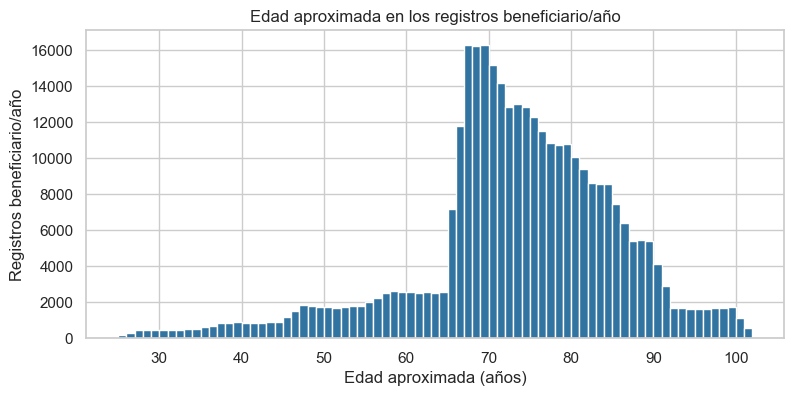

In [40]:
# Describo la edad, las categorias y los meses de cobertura de los beneficiarios.
display(beneficiary["AGE"].describe())


sexo = pd.DataFrame({
    "COUNT": beneficiary["SEX"].value_counts(),
    "PERCENTAGE": beneficiary["SEX"].value_counts(normalize=True).mul(100).round(2)
})

display(sexo)


raza = pd.DataFrame({
    "COUNT": beneficiary["RACE"].value_counts(),
    "PERCENTAGE": beneficiary["RACE"].value_counts(normalize=True).mul(100).round(2)
})

display(raza)


esrd = pd.DataFrame({
    "COUNT": beneficiary["END_STAGE_RENAL_DISEASE"].value_counts(),
    "PERCENTAGE": beneficiary["END_STAGE_RENAL_DISEASE"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
})

display(esrd)


coverage_columns = [
    "PART_A_COVERAGE_MONTHS",
    "PART_B_COVERAGE_MONTHS",
    "HMO_COVERAGE_MONTHS",
    "PART_D_COVERAGE_MONTHS"
]

display(beneficiary[coverage_columns].describe())

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(beneficiary["AGE"], bins=range(25, 103), color="#3274A1", edgecolor="white")
ax.set(title="Edad aproximada en los registros beneficiario/año", xlabel="Edad aproximada (años)", ylabel="Registros beneficiario/año")
plt.show()


La mediana de edad es 73 años. Female representa el 55,31 %, White el 82,79 % y la enfermedad renal terminal el 7,90 %. La cobertura mediana es doce meses en Parts A, B y D y cero en HMO.

### 9.2. Condiciones crónicas

CHRONIC_CONDITION_COUNT cuenta las once condiciones presentes. Un registro puede tener varias.

ISCHEMIC_HEART_DISEASE                   145708
DIABETES                                 124747
HEART_FAILURE                            101752
DEPRESSION                                72967
ALZHEIMER_RELATED_DISORDERS               67503
CHRONIC_KIDNEY_DISEASE                    58023
OSTEOPOROSIS                              56776
RHEUMATOID_ARTHRITIS_OSTEOARTHRITIS       48822
CHRONIC_OBSTRUCTIVE_PULMONARY_DISEASE     43773
CANCER                                    22484
STROKE_TRANSIENT_ISCHEMIC_ATTACK          14204
dtype: int64

ISCHEMIC_HEART_DISEASE                   42.40
DIABETES                                 36.30
HEART_FAILURE                            29.61
DEPRESSION                               21.23
ALZHEIMER_RELATED_DISORDERS              19.64
CHRONIC_KIDNEY_DISEASE                   16.88
OSTEOPOROSIS                             16.52
RHEUMATOID_ARTHRITIS_OSTEOARTHRITIS      14.21
CHRONIC_OBSTRUCTIVE_PULMONARY_DISEASE    12.74
CANCER                                    6.54
STROKE_TRANSIENT_ISCHEMIC_ATTACK          4.13
dtype: float64

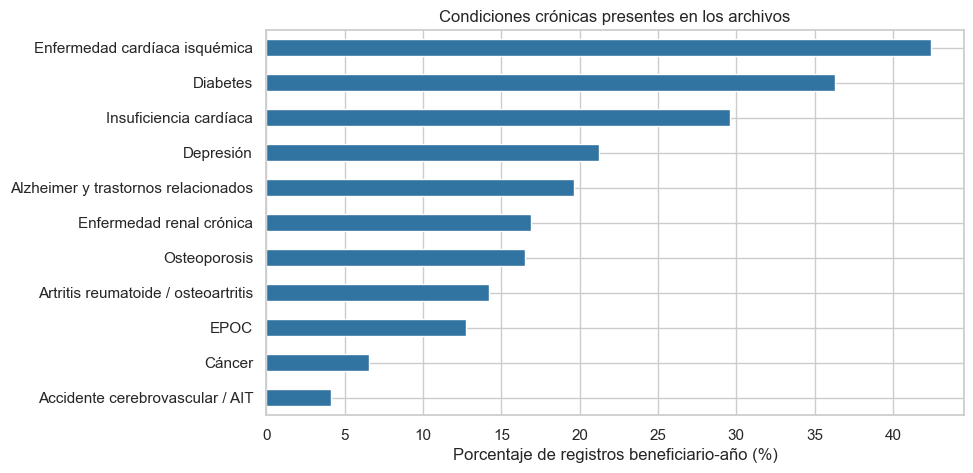

In [41]:
# Calculo que porcentaje de registros presenta cada condicion cronica.
prevalencia_cronicas = (
    beneficiary[chronic_conditions]
    .eq("Yes")
    .sum()
    .sort_values(ascending=False)
)

display(prevalencia_cronicas)

prevalencia_cronicas_pct = (
    beneficiary[chronic_conditions]
    .eq("Yes")
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

display(prevalencia_cronicas_pct)
# Las condiciones no son excluyentes: un registro puede tener varias.
etiquetas_cronicas = {
    "ISCHEMIC_HEART_DISEASE": "Enfermedad cardíaca isquémica", "DIABETES": "Diabetes",
    "HEART_FAILURE": "Insuficiencia cardíaca", "DEPRESSION": "Depresión",
    "ALZHEIMER_RELATED_DISORDERS": "Alzheimer y trastornos relacionados",
    "CHRONIC_KIDNEY_DISEASE": "Enfermedad renal crónica", "OSTEOPOROSIS": "Osteoporosis",
    "RHEUMATOID_ARTHRITIS_OSTEOARTHRITIS": "Artritis reumatoide / osteoartritis",
    "CHRONIC_OBSTRUCTIVE_PULMONARY_DISEASE": "EPOC", "CANCER": "Cáncer",
    "STROKE_TRANSIENT_ISCHEMIC_ATTACK": "Accidente cerebrovascular / AIT"
}
fig, ax = plt.subplots(figsize=(9, 5))
prevalencia_cronicas_pct.sort_values().rename(index=etiquetas_cronicas).plot.barh(ax=ax, color="#3274A1")
ax.set(title="Condiciones crónicas presentes en los archivos", xlabel="Porcentaje de registros beneficiario-año (%)", ylabel="")
plt.show()


Hay 125.983 beneficiario-año sin estas condiciones y 86 con las once. Las más frecuentes son enfermedad cardíaca isquémica (42,40 %), diabetes (36,30 %) e insuficiencia cardíaca (29,61 %).

### 9.3. Segmentación etaria

Uso rangos fijos: menores de 65, 65–74, 75–84 y 85 o más. Las condiciones, los claims y los pagos se comparan como promedios por beneficiario-año, incluidos los ceros. Los pagos son los originales de Beneficiary.

In [42]:
# Reviso las edades y preparo los rangos etarios sin eliminar registros.
control_edad_etaria = pd.Series({
    "Tipo de AGE": str(beneficiary_year["AGE"].dtype),
    "Registros beneficiario-año": len(beneficiary_year),
    "Edades válidas": beneficiary_year["AGE"].notna().sum(),
    "Edades nulas": beneficiary_year["AGE"].isna().sum(),
    "Edades negativas": beneficiary_year["AGE"].lt(0).sum(),
    "Edades superiores a 120 (alerta, no filtro)": beneficiary_year["AGE"].gt(120).sum(),
    "P90 de AGE": beneficiary_year["AGE"].quantile(0.90)
})
display(control_edad_etaria)
referencia_nacimiento_etaria = beneficiary_year["YEAR"] - beneficiary_year["AGE"]
inconsistencias_edad_anual = (
    referencia_nacimiento_etaria.groupby(beneficiary_year["DESYNPUF_ID"])
    .nunique().gt(1).sum()
)
print("Beneficiarios con edad anual inconsistente:", inconsistencias_edad_anual)
beneficiary_etario = beneficiary_year[[
    "YEAR", "AGE", "CHRONIC_CONDITION_COUNT", "INPATIENT_CLAIMS", "OUTPATIENT_CLAIMS",
    "INPATIENT_MEDICARE_PAYMENT", "OUTPATIENT_MEDICARE_PAYMENT"
]].copy()
beneficiary_etario["RANGO_ETARIO"] = pd.cut(
    beneficiary_etario["AGE"],
    bins=[-np.inf, 65, 75, 85, np.inf],
    labels=["Menores de 65", "65–74", "75–84", "85 o más"],
    right=False
)
distribucion_rangos_etarios = (
    beneficiary_etario.groupby("RANGO_ETARIO", observed=False)
    .agg(BENEFICIARIO_AÑO=("AGE", "count"), EDAD_MINIMA=("AGE", "min"), EDAD_MAXIMA=("AGE", "max"))
)
distribucion_rangos_etarios["PORCENTAJE"] = (
    distribucion_rangos_etarios["BENEFICIARIO_AÑO"]
    / beneficiary_etario["AGE"].notna().sum() * 100
)
display(distribucion_rangos_etarios.round(2))
rangos_etarios_por_año = pd.crosstab(
    beneficiary_etario["YEAR"], beneficiary_etario["RANGO_ETARIO"]
)
display(rangos_etarios_por_año.div(rangos_etarios_por_año.sum(axis=1), axis=0).mul(100).round(2))


Tipo de AGE                                     int32
Registros beneficiario-año                     343644
Edades válidas                                 343644
Edades nulas                                        0
Edades negativas                                    0
Edades superiores a 120 (alerta, no filtro)         0
P90 de AGE                                       87.0
dtype: object

Beneficiarios con edad anual inconsistente: 0


,BENEFICIARIO_AÑO,EDAD_MINIMA,EDAD_MAXIMA,PORCENTAJE
RANGO_ETARIO,,,,
Menores de 65,54090,25,64,15.74
65–74,135918,65,74,39.55
75–84,101461,75,84,29.53
85 o más,52175,85,101,15.18


RANGO_ETARIO,Menores de 65,65–74,75–84,85 o más
YEAR,,,,
2008,16.43,42.58,28.26,12.72
2009,15.72,39.56,29.50,15.22
2010,15.04,36.41,30.86,17.69


,BENEFICIARIO_AÑO,CRONICAS_PROMEDIO,CLAIMS_INPATIENT_PROMEDIO,CLAIMS_OUTPATIENT_PROMEDIO,MEDICARE_INPATIENT_ANUAL_PROMEDIO,MEDICARE_OUTPATIENT_ANUAL_PROMEDIO,CLAIMS_TOTALES_PROMEDIO,MEDICARE_TOTAL_ANUAL_PROMEDIO
RANGO_ETARIO,,,,,,,,
Menores de 65,54090,2.188,0.206,2.396,1938.623,664.529,2.602,2603.152
65–74,135918,1.914,0.155,2.008,1538.287,521.782,2.163,2060.069
75–84,101461,2.374,0.211,2.395,2064.587,642.713,2.606,2707.300
85 o más,52175,2.634,0.252,2.569,2396.566,713.331,2.821,3109.897


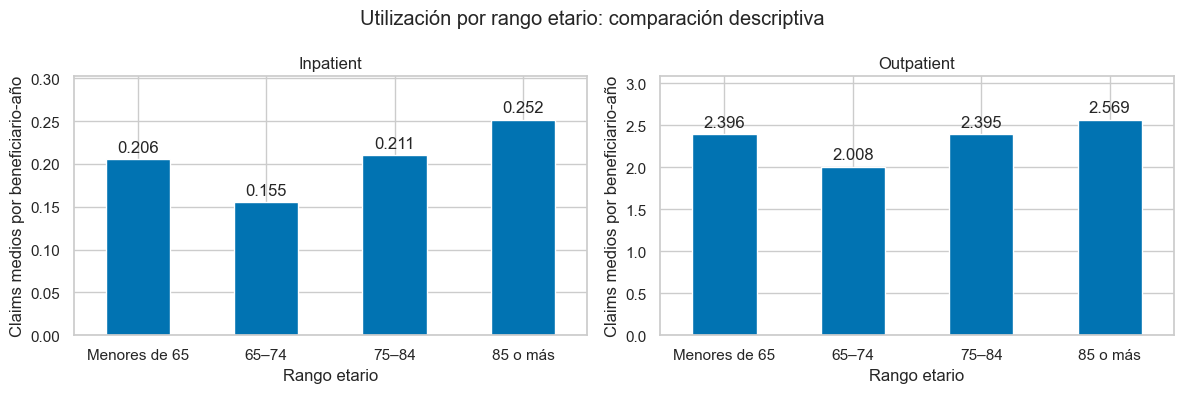

Rangos completos y excluyentes; porcentajes y conteos consistentes con la tabla final


In [43]:
# Comparo los rangos etarios con promedios por beneficiario y año.
resumen_negocio_etario = (
    beneficiary_etario.groupby("RANGO_ETARIO", observed=False)
    .agg(
        BENEFICIARIO_AÑO=("AGE", "count"),
        CRONICAS_PROMEDIO=("CHRONIC_CONDITION_COUNT", "mean"),
        CLAIMS_INPATIENT_PROMEDIO=("INPATIENT_CLAIMS", "mean"),
        CLAIMS_OUTPATIENT_PROMEDIO=("OUTPATIENT_CLAIMS", "mean"),
        MEDICARE_INPATIENT_ANUAL_PROMEDIO=("INPATIENT_MEDICARE_PAYMENT", "mean"),
        MEDICARE_OUTPATIENT_ANUAL_PROMEDIO=("OUTPATIENT_MEDICARE_PAYMENT", "mean")
    )
)
resumen_negocio_etario["CLAIMS_TOTALES_PROMEDIO"] = (
    resumen_negocio_etario["CLAIMS_INPATIENT_PROMEDIO"]
    + resumen_negocio_etario["CLAIMS_OUTPATIENT_PROMEDIO"]
)
resumen_negocio_etario["MEDICARE_TOTAL_ANUAL_PROMEDIO"] = (
    resumen_negocio_etario["MEDICARE_INPATIENT_ANUAL_PROMEDIO"]
    + resumen_negocio_etario["MEDICARE_OUTPATIENT_ANUAL_PROMEDIO"]
)
display(resumen_negocio_etario.round(3))
fig_etaria, ejes_etarios = plt.subplots(1, 2, figsize=(12, 4))
for eje_etario, columna_etaria, servicio_etario in [
    (ejes_etarios[0], "CLAIMS_INPATIENT_PROMEDIO", "Inpatient"),
    (ejes_etarios[1], "CLAIMS_OUTPATIENT_PROMEDIO", "Outpatient")
]:
    resumen_negocio_etario[columna_etaria].plot.bar(ax=eje_etario, rot=0)
    eje_etario.set(title=servicio_etario, xlabel="Rango etario", ylabel="Claims medios por beneficiario-año")
    for barras_etarias in eje_etario.containers:
        eje_etario.bar_label(barras_etarias, fmt="%.3f", padding=3)
    eje_etario.set_ylim(0, resumen_negocio_etario[columna_etaria].max() * 1.2)
fig_etaria.suptitle("Utilización por rango etario: comparación descriptiva")
fig_etaria.tight_layout()
plt.show()

assert beneficiary_etario.loc[beneficiary_etario["AGE"].notna(), "RANGO_ETARIO"].notna().all()
assert beneficiary_etario.loc[beneficiary_etario["AGE"].isna(), "RANGO_ETARIO"].isna().all()
assert distribucion_rangos_etarios["BENEFICIARIO_AÑO"].sum() == beneficiary_year["AGE"].notna().sum()
assert np.isclose(distribucion_rangos_etarios["PORCENTAJE"].sum(), 100)
assert rangos_etarios_por_año.to_numpy().sum() == beneficiary_year["AGE"].notna().sum()
assert resumen_negocio_etario["BENEFICIARIO_AÑO"].equals(distribucion_rangos_etarios["BENEFICIARIO_AÑO"])
print("Rangos completos y excluyentes; porcentajes y conteos consistentes con la tabla final")


El grupo de 85 o más tiene los mayores promedios: 2,634 condiciones, 0,252 claims Inpatient y 2,569 Outpatient, con pagos anuales de 2.396,57 y 713,33 USD. El grupo de 65–74 tiene los menores valores.

Menores de 65 supera a 65–74, por lo que el patrón no crece de forma uniforme con la edad. Los grupos tienen tamaños distintos; sus promedios permiten compararlos sin confundir tamaño con mayor utilización.

## 10. Volumen y distribución de pagos

### 10.1. Volumen por servicio

In [44]:
# Pagos originales de Beneficiary y conteos de Claims.
display(beneficiary_year[[
    "INPATIENT_CLAIMS", "OUTPATIENT_CLAIMS",
    "INPATIENT_MEDICARE_PAYMENT", "OUTPATIENT_MEDICARE_PAYMENT"
]].sum().rename("Total observado"))


INPATIENT_CLAIMS                   66705.0
OUTPATIENT_CLAIMS                 779537.0
INPATIENT_MEDICARE_PAYMENT     648456860.0
OUTPATIENT_MEDICARE_PAYMENT    209292350.0
Name: Total observado, dtype: float64

Outpatient concentra 779.537 claims fechados frente a 66.705 Inpatient. Sin embargo, Inpatient tiene mayores pagos Medicare originales: 648.456.860 USD frente a 209.292.350 en Outpatient.

### 10.2. Distribución financiera

In [45]:
# Referencia general de pago por claim para comparar ambos servicios.
pago_por_claim_servicio = pd.DataFrame([
    {
        "Servicio": servicio,
        "Claims con reembolso": tabla["MEDICARE_REIMBURSEMENT"].count(),
        "Pago medio (USD)": tabla["MEDICARE_REIMBURSEMENT"].mean(),
        "Mediana (USD)": tabla["MEDICARE_REIMBURSEMENT"].median()
    }
    for servicio, tabla in [("Inpatient", inpatient_claim), ("Outpatient", outpatient_claim)]
])
display(pago_por_claim_servicio.round(2))


,Servicio,Claims con reembolso,Pago medio (USD),Mediana (USD)
0,Inpatient,66637,9712.70,7000.0
1,Outpatient,779537,268.48,70.0


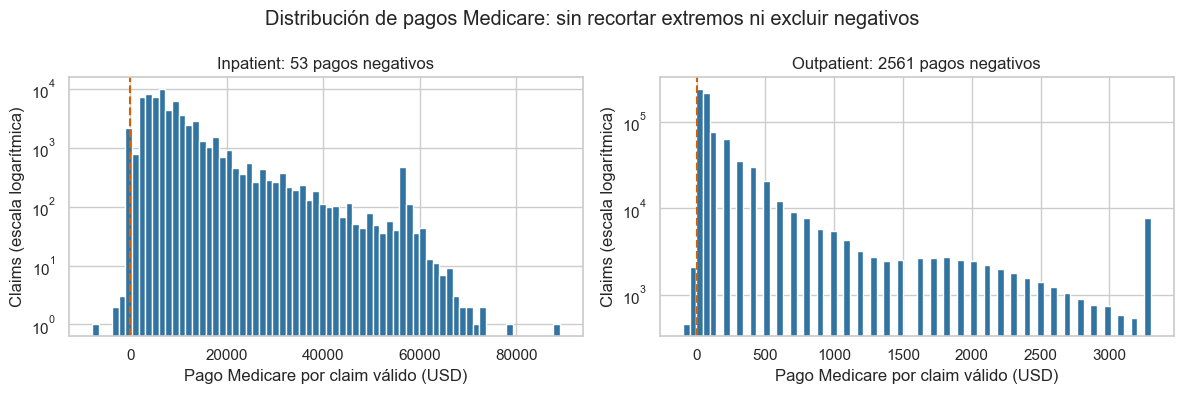

In [46]:
# Negativos y extremos incluidos en la distribucion.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, tabla, servicio in [(axes[0], inpatient_claim, "Inpatient"), (axes[1], outpatient_claim, "Outpatient")]:
    valores = tabla["MEDICARE_REIMBURSEMENT"].dropna()
    ax.hist(valores, bins=70, color="#3274A1", edgecolor="white")
    ax.set_yscale("log")
    ax.axvline(0, color="#D55E00", linestyle="--")
    ax.set(title=f"{servicio}: {valores.lt(0).sum()} pagos negativos", xlabel="Pago Medicare por claim válido (USD)", ylabel="Claims (escala logarítmica)")
fig.suptitle("Distribución de pagos Medicare: sin recortar extremos ni excluir negativos")
fig.tight_layout()
plt.show()


El pago medio por claim es 9.712,70 USD Inpatient y 268,48 Outpatient; las medianas son 7.000 y 70. Los importes altos elevan el promedio.

Se mantienen 53 pagos negativos Inpatient y 2.561 Outpatient: su valor por sí solo no demuestra un error. Las exclusiones financieras y los nulos se vuelven a comprobar en el resumen numérico del cierre.

## 11. Cronicidad, utilización y pagos

### 11.1. Utilización

El promedio incluye los registros sin claims, con conteo cero.

,count,mean
CHRONIC_CONDITION_COUNT,,
0,125983,0.005
1,44306,0.051
2,41353,0.106
3,36871,0.175
4,31253,0.268
5,24639,0.407
6,17785,0.613
7,11688,0.873
8,6366,1.207


,count,mean
CHRONIC_CONDITION_COUNT,,
0,125983,0.360
1,44306,1.726
2,41353,2.436
3,36871,3.010
4,31253,3.719
5,24639,4.355
6,17785,5.049
7,11688,5.765
8,6366,6.368


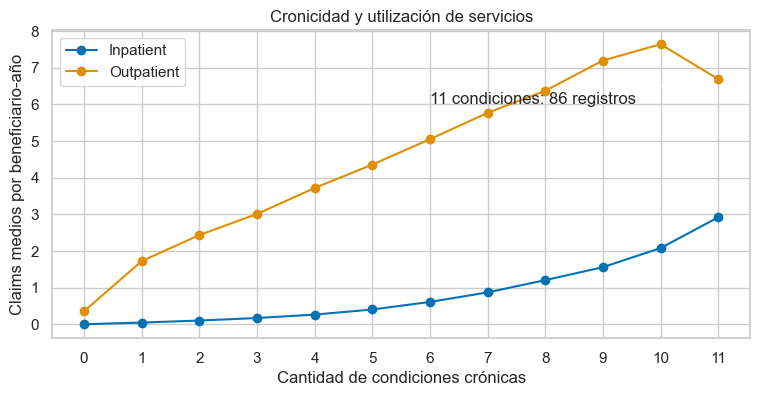

In [47]:
# Comparo la utilizacion media segun la cantidad de condiciones cronicas.
inpatient_por_cronicidad = (
    beneficiary_utilizacion
    .groupby("CHRONIC_CONDITION_COUNT")["INPATIENT_CLAIMS"]
    .agg(["count", "mean"])
    .round(3)
)

display(inpatient_por_cronicidad)


outpatient_por_cronicidad = (
    beneficiary_utilizacion
    .groupby("CHRONIC_CONDITION_COUNT")["OUTPATIENT_CLAIMS"]
    .agg(["count", "mean"])
    .round(3)
)

display(outpatient_por_cronicidad)
# Los beneficiarios sin utilizacion aportan ceros al promedio.
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(inpatient_por_cronicidad.index, inpatient_por_cronicidad["mean"], marker="o", label="Inpatient")
ax.plot(outpatient_por_cronicidad.index, outpatient_por_cronicidad["mean"], marker="o", label="Outpatient")
ax.set(title="Cronicidad y utilización de servicios", xlabel="Cantidad de condiciones crónicas", ylabel="Claims medios por beneficiario-año", xticks=range(12))
ax.annotate("11 condiciones: 86 registros", xy=(11, outpatient_por_cronicidad.loc[11, "mean"]), xytext=(6, 6.0), arrowprops={"arrowstyle": "->"})
ax.legend()
plt.show()


Inpatient pasa de 0,005 a 1,207 claims medios entre cero y ocho condiciones. Outpatient pasa de 0,360 a 7,635 entre cero y diez y baja a 6,686 con once. Ese último grupo tiene solo 86 registros y requiere cautela.

### 11.2. Pagos anuales

Los pagos se toman de Beneficiary y se promedian por beneficiario-año.

,MEDICARE_PROMEDIO,BENEFICIARIO_PROMEDIO,OTRO_PAGADOR_PROMEDIO
CHRONIC_CONDITION_COUNT,,,
0,48.96,5.68,1.42
1,491.34,59.40,21.49
2,1008.22,120.31,52.62
3,1691.35,196.53,83.02
4,2612.80,300.42,109.06
5,3928.86,453.79,140.09
6,6002.74,668.15,225.18
7,8526.77,951.97,328.50
8,11816.32,1321.71,518.52


,MEDICARE_PROMEDIO,BENEFICIARIO_PROMEDIO,OTRO_PAGADOR_PROMEDIO
CHRONIC_CONDITION_COUNT,,,
0,75.75,24.03,3.20
1,386.39,122.70,15.83
2,557.06,177.66,23.34
3,721.97,228.13,32.04
4,1006.90,310.30,34.55
5,1264.43,384.56,43.37
6,1553.54,464.03,56.86
7,1818.97,544.12,67.04
8,2037.21,621.46,80.62


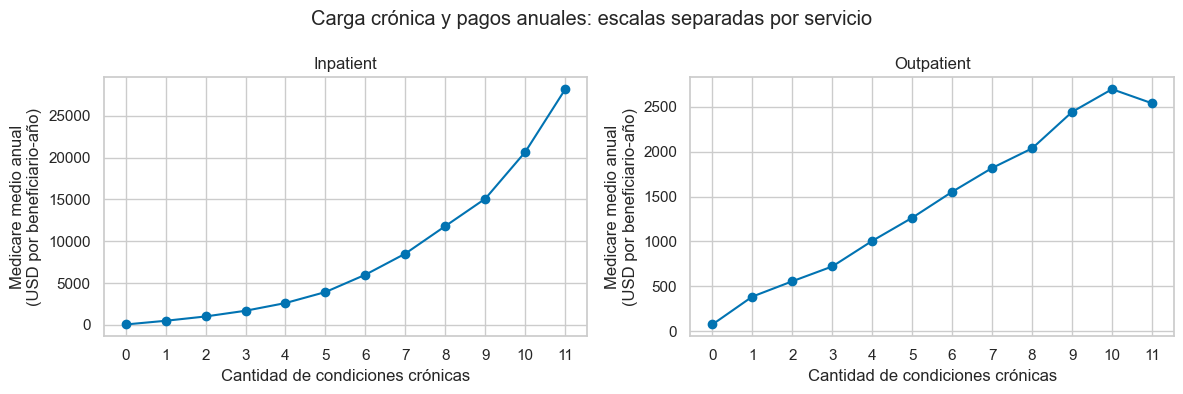

In [48]:
# Comparo los pagos anuales medios segun la cantidad de condiciones cronicas.
inpatient_pagos_por_cronicidad = (
    beneficiary_utilizacion
    .groupby("CHRONIC_CONDITION_COUNT")
    .agg(
        MEDICARE_PROMEDIO=("INPATIENT_MEDICARE_PAYMENT", "mean"),
        BENEFICIARIO_PROMEDIO=("INPATIENT_BENEFICIARY_PAYMENT", "mean"),
        OTRO_PAGADOR_PROMEDIO=("INPATIENT_OTHER_PAYER_PAYMENT", "mean")
    )
    .round(2)
)

display(inpatient_pagos_por_cronicidad)


outpatient_pagos_por_cronicidad = (
    beneficiary_utilizacion
    .groupby("CHRONIC_CONDITION_COUNT")
    .agg(
        MEDICARE_PROMEDIO=("OUTPATIENT_MEDICARE_PAYMENT", "mean"),
        BENEFICIARIO_PROMEDIO=("OUTPATIENT_BENEFICIARY_PAYMENT", "mean"),
        OTRO_PAGADOR_PROMEDIO=("OUTPATIENT_OTHER_PAYER_PAYMENT", "mean")
    )
    .round(2)
)

display(outpatient_pagos_por_cronicidad)
# Pagos anuales originales de Beneficiary.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, tabla, servicio in [
    (axes[0], inpatient_pagos_por_cronicidad, "Inpatient"),
    (axes[1], outpatient_pagos_por_cronicidad, "Outpatient")
]:
    ax.plot(tabla.index, tabla["MEDICARE_PROMEDIO"], marker="o")
    ax.set(title=servicio, xlabel="Cantidad de condiciones crónicas",
           ylabel="Medicare medio anual\n(USD por beneficiario-año)", xticks=range(12))
fig.suptitle("Carga crónica y pagos anuales: escalas separadas por servicio")
fig.tight_layout()
plt.show()


El pago anual medio Inpatient pasa de 48,96 a 11.816,32 USD entre cero y ocho condiciones. Outpatient pasa de 75,75 a 2.696,50 entre cero y diez y baja a 2.539,42 con once. En general, los perfiles con más condiciones usan más servicios y registran mayores pagos anuales.

### 11.3. Pago por claim

In [49]:
# Promedio sobre reembolsos no nulos, con una fila por claim.
inpatient_costo_por_claim_cronicidad = (
    inpatient_claim.loc[inpatient_claim["MEDICARE_REIMBURSEMENT"].notna()]
    .groupby("CHRONIC_CONDITION_COUNT")["MEDICARE_REIMBURSEMENT"]
    .agg(["count", "mean", "median"])
    .round(2)
)
display(inpatient_costo_por_claim_cronicidad)

outpatient_costo_por_claim_cronicidad = (
    outpatient_claim.loc[outpatient_claim["MEDICARE_REIMBURSEMENT"].notna()]
    .groupby("CHRONIC_CONDITION_COUNT")["MEDICARE_REIMBURSEMENT"]
    .agg(["count", "mean", "median"])
    .round(2)
)
display(outpatient_costo_por_claim_cronicidad)


,count,mean,median
CHRONIC_CONDITION_COUNT,,,
0,640,9638.39,7000.0
1,2277,9560.45,7000.0
2,4360,9542.04,7000.0
3,6429,9669.72,7000.0
4,8365,9740.33,7000.0
5,10022,9628.01,7000.0
6,10890,9788.09,7000.0
7,10194,9763.79,7000.0
8,7679,9778.11,7000.0


,count,mean,median
CHRONIC_CONDITION_COUNT,,,
0.0,45352,210.42,70.0
1.0,76490,223.81,70.0
2.0,100735,228.68,70.0
3.0,110999,239.82,70.0
4.0,116234,270.74,70.0
5.0,107292,290.37,80.0
6.0,89792,307.71,80.0
7.0,67384,315.51,80.0
8.0,40541,319.90,80.0


Las medias por claim Inpatient van de 9.542,04 a 9.943,56 USD, con mediana de 7.000 en todos los grupos. Outpatient aumenta de 210,42 USD sin condiciones a 353,19 con diez y 379,81 con once.

En Inpatient cambia más la frecuencia que el importe individual. Los pagos anuales incluyen claims excluidos del detalle financiero; por eso, frecuencia media por pago medio no reconstruye necesariamente el total original.

## 12. Temporalidad y cobertura

### 12.1. Claims que atraviesan años

In [50]:
# Reviso las fechas disponibles y los claims que atraviesan años.
display(inpatient_claims[
    ["CLAIM_START_DATE", "CLAIM_END_DATE", "ADMISSION_DATE", "DISCHARGE_DATE"]
].agg(["min", "max"]))



display(inpatient_claims["CLAIM_START_DATE"].dt.year.value_counts(
    dropna=False
).sort_index())



display(inpatient_claims["CLAIM_END_DATE"].dt.year.value_counts(
    dropna=False
).sort_index())


display(outpatient_claims[
    ["CLAIM_START_DATE", "CLAIM_END_DATE"]
].agg(["min", "max"]))



display(outpatient_claims["CLAIM_START_DATE"].dt.year.value_counts(
    dropna=False
).sort_index())



display(outpatient_claims["CLAIM_END_DATE"].dt.year.value_counts(
    dropna=False
).sort_index())


inpatient_cambio_anio = inpatient_claims[
    inpatient_claims["CLAIM_START_DATE"].notna()
    & inpatient_claims["CLAIM_END_DATE"].notna()
    & (
        inpatient_claims["CLAIM_START_DATE"].dt.year
        != inpatient_claims["CLAIM_END_DATE"].dt.year
    )
]

display(inpatient_cambio_anio.assign(
    START_YEAR=inpatient_cambio_anio["CLAIM_START_DATE"].dt.year,
    END_YEAR=inpatient_cambio_anio["CLAIM_END_DATE"].dt.year
).groupby(
    ["START_YEAR", "END_YEAR"]
)["CLM_ID"].nunique())



outpatient_cambio_anio = outpatient_claims[
    outpatient_claims["CLAIM_START_DATE"].notna()
    & outpatient_claims["CLAIM_END_DATE"].notna()
    & (
        outpatient_claims["CLAIM_START_DATE"].dt.year
        != outpatient_claims["CLAIM_END_DATE"].dt.year
    )
]

display(outpatient_cambio_anio.assign(
    START_YEAR=outpatient_cambio_anio["CLAIM_START_DATE"].dt.year,
    END_YEAR=outpatient_cambio_anio["CLAIM_END_DATE"].dt.year
).groupby(
    ["START_YEAR", "END_YEAR"]
)["CLM_ID"].nunique())


,CLAIM_START_DATE,CLAIM_END_DATE,ADMISSION_DATE,DISCHARGE_DATE
min,2007-11-27,2008-01-01,2007-11-27,2008-01-01
max,2010-12-30,2010-12-31,2010-12-30,2010-12-31


CLAIM_START_DATE
2007.0      224
2008.0    27678
2009.0    25231
2010.0    13572
NaN          68
Name: count, dtype: int64

CLAIM_END_DATE
2008.0    27496
2009.0    25293
2010.0    13916
NaN          68
Name: count, dtype: int64

,CLAIM_START_DATE,CLAIM_END_DATE
min,2007-12-12,2008-01-01
max,2010-12-31,2010-12-31


CLAIM_START_DATE
2007.0       312
2008.0    282896
2009.0    322358
2010.0    173971
NaN        11253
Name: count, dtype: int64

CLAIM_END_DATE
2008.0    281901
2009.0    322631
2010.0    175005
NaN        11253
Name: count, dtype: int64

START_YEAR  END_YEAR
2007        2008        224
2008        2009        406
2009        2010        344
Name: CLM_ID, dtype: int64

START_YEAR  END_YEAR
2007        2008         312
2008        2009        1307
2009        2010        1034
Name: CLM_ID, dtype: int64

974 claims Inpatient y 2.653 Outpatient atraviesan años. Algunos empiezan en 2007, aunque todos los fines fechados están entre 2008 y 2010. Esto explica que los conteos cambien al usar inicio o finalización.

### 12.2. Volumen anual y mensual

In [51]:


utilizacion_por_año = (
    beneficiary_utilizacion
    .groupby("YEAR")
    .agg(
        BENEFICIARIOS=("DESYNPUF_ID", "count"),
        INPATIENT_CLAIMS_PROMEDIO=("INPATIENT_CLAIMS", "mean"),
        OUTPATIENT_CLAIMS_PROMEDIO=("OUTPATIENT_CLAIMS", "mean")
    )
    .round(2)
)

display(utilizacion_por_año)


,BENEFICIARIOS,INPATIENT_CLAIMS_PROMEDIO,OUTPATIENT_CLAIMS_PROMEDIO
YEAR,,,
2008,116352,0.24,2.42
2009,114538,0.22,2.82
2010,112754,0.12,1.55


MONTH,1,2,3,4,5,6,7,8,9,10,11,12
YEAR,,,,,,,,,,,,
2008,1424,1767,2226,2288,2582,2498,2444,2581,2472,2538,2293,2383
2009,2327,2023,2209,2163,2238,2091,2149,2127,2119,2033,1895,1919
2010,1789,1570,1616,1435,1498,1311,1202,1143,959,635,435,323


MONTH,1,2,3,4,5,6,7,8,9,10,11,12
YEAR,,,,,,,,,,,,
2008,9953,15155,20916,23097,24880,25008,26466,27156,26334,27490,27103,28343
2009,28658,25951,28557,27694,28466,27340,27783,27609,26122,26057,24381,24013
2010,22608,19383,20159,18076,17308,15186,14241,12507,10822,9465,8099,7151


,Inpatient,Outpatient
YEAR,,
2008,27496,281901
2009,25293,322631
2010,13916,175005


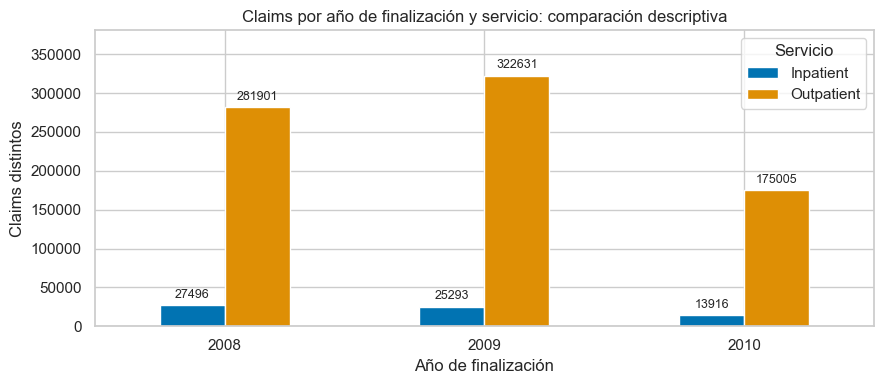

In [52]:
# Cuento los claims por mes y año de fin para comparar el volumen de ambos servicios.
inpatient_por_mes = (
    inpatient_claims[
        inpatient_claims["CLAIM_END_DATE"].notna()
    ]
    .assign(
        YEAR=lambda x: x["CLAIM_END_DATE"].dt.year,
        MONTH=lambda x: x["CLAIM_END_DATE"].dt.month
    )
    .groupby(["YEAR", "MONTH"])["CLM_ID"]
    .nunique()
    .unstack(fill_value=0)
)

display(inpatient_por_mes)



outpatient_por_mes = (
    outpatient_claims[
        outpatient_claims["CLAIM_END_DATE"].notna()
    ]
    .assign(
        YEAR=lambda x: x["CLAIM_END_DATE"].dt.year,
        MONTH=lambda x: x["CLAIM_END_DATE"].dt.month
    )
    .groupby(["YEAR", "MONTH"])["CLM_ID"]
    .nunique()
    .unstack(fill_value=0)
)

display(outpatient_por_mes)

# Cada claim fechado se asigna a un solo mes y año.
claims_por_año_servicio = pd.DataFrame({
    "Inpatient": inpatient_por_mes.sum(axis=1),
    "Outpatient": outpatient_por_mes.sum(axis=1)
})
claims_por_año_servicio.index.name = "YEAR"
assert int(claims_por_año_servicio["Inpatient"].sum()) == int(beneficiary_year["INPATIENT_CLAIMS"].sum())
assert int(claims_por_año_servicio["Outpatient"].sum()) == int(beneficiary_year["OUTPATIENT_CLAIMS"].sum())
display(claims_por_año_servicio)
fig, ax = plt.subplots(figsize=(9, 4))
claims_por_año_servicio.plot.bar(ax=ax, rot=0)
for barras in ax.containers:
    ax.bar_label(barras, fmt="%.0f", fontsize=9, padding=3)
ax.set(title="Claims por año de finalización y servicio: comparación descriptiva",
       xlabel="Año de finalización", ylabel="Claims distintos")
ax.set_ylim(0, claims_por_año_servicio.to_numpy().max() * 1.18)
ax.legend(title="Servicio")
fig.tight_layout()
plt.show()


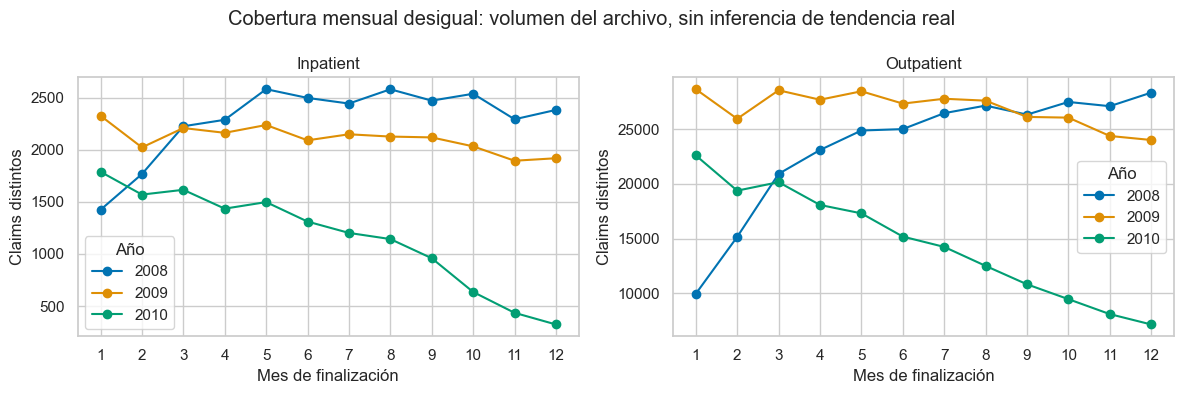

In [53]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, tabla, servicio in [(axes[0], inpatient_por_mes, "Inpatient"), (axes[1], outpatient_por_mes, "Outpatient")]:
    for año in tabla.index:
        ax.plot(tabla.columns, tabla.loc[año], marker="o", label=str(año))
    ax.set(title=servicio, xlabel="Mes de finalización", ylabel="Claims distintos", xticks=range(1, 13))
    ax.legend(title="Año")
fig.suptitle("Cobertura mensual desigual: volumen del archivo, sin inferencia de tendencia real")
fig.tight_layout()
plt.show()


En 2010, Inpatient pasa de 1.789 claims en enero a 323 en diciembre; Outpatient, de 22.608 a 7.151. La cobertura mensual desigual limita la comparación entre años.

## 13. DRG, proveedores y geografía

### 13.1. DRG

Comparo volumen, pago y duración en claims Inpatient con reembolso disponible.

DRG diferentes:
739

Valores faltantes:
0

10 DRG más frecuentes:
DIAGNOSIS_RELATED_GROUP
882    282
177    281
886    275
887    274
880    264
181    264
189    260
883    259
876    259
183    257
Name: count, dtype: int64


,CLAIMS,MEDICARE_TOTAL,MEDICARE_PROMEDIO,MEDICARE_MEDIANA,ESTADIA_PROMEDIO,ESTADIA_MEDIANA
DIAGNOSIS_RELATED_GROUP,,,,,,
939,253,3521700.0,13919.76,13000.0,11.58,10.0
948,235,3418480.0,14546.72,14000.0,11.06,11.0
949,235,3338080.0,14204.60,14000.0,11.73,11.0
945,244,3324510.0,13625.04,12000.0,11.90,11.0
951,240,3281140.0,13671.42,14000.0,10.94,10.0
946,219,3074320.0,14037.99,12000.0,11.08,10.0
941,219,2986480.0,13636.89,14000.0,11.05,11.0
862,192,2877960.0,14989.38,10000.0,8.25,5.0
950,206,2867120.0,13918.06,14000.0,11.63,11.0


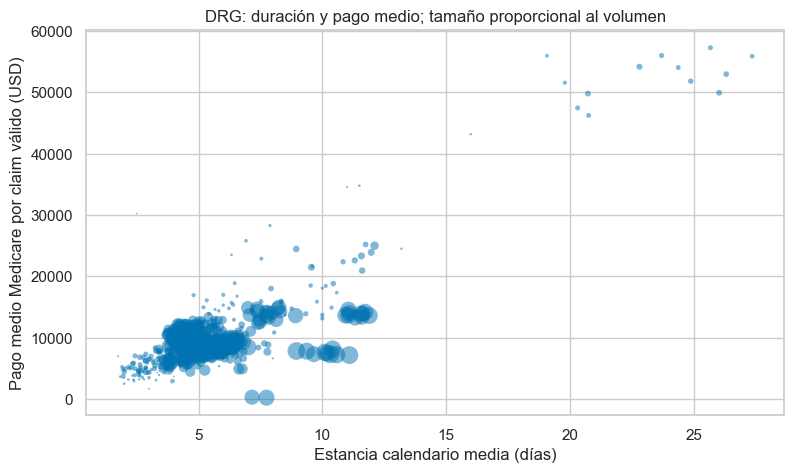

In [54]:
# Comparo volumen, pago y estancia hospitalaria por DRG.
print("DRG diferentes:")
print(inpatient_claims["DIAGNOSIS_RELATED_GROUP"].nunique())

print("\nValores faltantes:")
print(inpatient_claims["DIAGNOSIS_RELATED_GROUP"].isna().sum())

print("\n10 DRG más frecuentes:")
print(
    inpatient_claims[
        inpatient_claims["CLAIM_SEGMENT"] == 1
    ]["DIAGNOSIS_RELATED_GROUP"]
    .value_counts()
    .head(10)
)


drg_analisis = (
    inpatient_claims[
        (inpatient_claims["CLAIM_SEGMENT"] == 1)
        & (~inpatient_claims["IS_MULTI_SEGMENT"])
    ]
    .groupby("DIAGNOSIS_RELATED_GROUP")
    .agg(
        CLAIMS=("CLM_ID", "nunique"),
        MEDICARE_TOTAL=("MEDICARE_REIMBURSEMENT", "sum"),
        MEDICARE_PROMEDIO=("MEDICARE_REIMBURSEMENT", "mean"),
        MEDICARE_MEDIANA=("MEDICARE_REIMBURSEMENT", "median"),
        ESTADIA_PROMEDIO=("HOSPITAL_STAY_DAYS", "mean"),
        ESTADIA_MEDIANA=("HOSPITAL_STAY_DAYS", "median")
    )
)

display(drg_analisis.sort_values(
    "MEDICARE_TOTAL",
    ascending=False
).head(10).round(2))
# Cada punto representa un DRG; su tamaño refleja la cantidad de claims.
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(drg_analisis["ESTADIA_PROMEDIO"], drg_analisis["MEDICARE_PROMEDIO"], s=drg_analisis["CLAIMS"] * 0.6, alpha=0.5, edgecolors="none")
ax.set(title="DRG: duración y pago medio; tamaño proporcional al volumen", xlabel="Estancia calendario media (días)", ylabel="Pago medio Medicare por claim válido (USD)")
plt.show()


Hay 739 DRG y ningún faltante. El código 939 encabeza el pago total de la base financiera: 253 claims, 3.521.700 USD y estancia media de 11,58 días. El tamaño de los puntos permite leer el volumen junto con el pago medio.

### 13.2. Proveedores

In [55]:
# Reviso cuantos proveedores hay y cuales concentran mas claims y pagos.
print("Proveedores Inpatient:")
print(inpatient_claims["PROVIDER_ID"].nunique())

print("\nProveedores Outpatient:")
print(outpatient_claims["PROVIDER_ID"].nunique())

print("\nTop 10 proveedores Inpatient por cantidad de claims:")
print(
    inpatient_claims[
        inpatient_claims["CLAIM_SEGMENT"] == 1
    ]
    .groupby("PROVIDER_ID")["CLM_ID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 proveedores Outpatient por cantidad de claims:")
print(
    outpatient_claims[
        outpatient_claims["CLAIM_SEGMENT"] == 1
    ]
    .groupby("PROVIDER_ID")["CLM_ID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)


proveedores_inpatient = (
    inpatient_claims[
        (inpatient_claims["CLAIM_SEGMENT"] == 1)
        & (~inpatient_claims["IS_MULTI_SEGMENT"])
    ]
    .groupby("PROVIDER_ID")
    .agg(
        CLAIMS=("CLM_ID", "nunique"),
        MEDICARE_TOTAL=("MEDICARE_REIMBURSEMENT", "sum"),
        MEDICARE_PROMEDIO=("MEDICARE_REIMBURSEMENT", "mean")
    )
)

display(proveedores_inpatient.sort_values(
    "MEDICARE_TOTAL",
    ascending=False
).head(10).round(2))


proveedores_outpatient = (
    outpatient_claims[
        outpatient_claims["CLAIM_SEGMENT"] == 1
    ]
    .groupby("PROVIDER_ID")
    .agg(
        CLAIMS=("CLM_ID", "nunique"),
        MEDICARE_TOTAL=("MEDICARE_REIMBURSEMENT", "sum"),
        MEDICARE_PROMEDIO=("MEDICARE_REIMBURSEMENT", "mean")
    )
)

display(proveedores_outpatient.sort_values(
    "MEDICARE_TOTAL",
    ascending=False
).head(10).round(2))


Proveedores Inpatient:
2675

Proveedores Outpatient:
6294

Top 10 proveedores Inpatient por cantidad de claims:
PROVIDER_ID
23006G    772
1000AH    633
3600NG    536
1401RR    431
2600ZT    421
2100WC    399
3400XN    395
0501MA    359
4500DP    336
1002DC    323
Name: CLM_ID, dtype: int64

Top 10 proveedores Outpatient por cantidad de claims:


PROVIDER_ID
0502NA    9770
2201DT    5992
0505TK    5664
2301GU    4360
3300KJ    3889
3400ZQ    3810
4500NJ    3729
1700JJ    3568
10018S    3531
3600WB    3461
Name: CLM_ID, dtype: int64


,CLAIMS,MEDICARE_TOTAL,MEDICARE_PROMEDIO
PROVIDER_ID,,,
23006G,772,7367990.0,9544.03
1000AH,632,6222620.0,9845.92
3600NG,535,5728670.0,10707.79
2100WC,399,4093610.0,10259.67
1401RR,430,3919960.0,9116.19
2600ZT,421,3914690.0,9298.55
3400XN,395,3882110.0,9828.13
0501MA,359,3776440.0,10519.33
3100JN,314,3605680.0,11483.06


,CLAIMS,MEDICARE_TOTAL,MEDICARE_PROMEDIO
PROVIDER_ID,,,
0502NA,9770,2682130.0,274.53
2201DT,5992,1642900.0,274.18
0505TK,5664,1586460.0,280.10
2301GU,4360,1186470.0,272.13
3300KJ,3889,1084540.0,278.87
3400ZQ,3810,1061950.0,278.73
4500NJ,3729,1037190.0,278.14
10018S,3531,956400.0,270.86
1700JJ,3568,898690.0,251.88


Inpatient tiene 2.675 proveedores y Outpatient 6.294. En la base financiera, 23006G encabeza los pagos Inpatient con 772 claims y 7.367.990 USD. En Outpatient, 0502NA registra 9.770 claims y 2.682.130 USD.

### 13.3. Geografía del beneficiario

State corresponde al beneficiario en el año del claim. La utilización incluye los ceros en su promedio; el pago por claim usa solo importes y conteos financieros válidos. OTHERS y las ubicaciones no resueltas quedan fuera de este resumen estatal.

In [56]:
# Comparo utilizacion y pago por claim segun el estado del beneficiario.
# Pago y denominador corresponden al mismo conjunto de claims.
geografia_estado = (
    beneficiary_year.loc[beneficiary_year["State"].notna() & beneficiary_year["State"].ne("OTHERS")]
    .groupby("State")
    .agg(
        REGISTROS_BENEFICIARIO_AÑO=("DESYNPUF_ID", "count"),
        INPATIENT_CLAIMS=("INPATIENT_CLAIMS", "sum"),
        OUTPATIENT_CLAIMS=("OUTPATIENT_CLAIMS", "sum"),
        INPATIENT_MEDICARE_TOTAL=("INPATIENT_MEDICARE_VALID_TOTAL", "sum"),
        OUTPATIENT_MEDICARE_TOTAL=("OUTPATIENT_MEDICARE_VALID_TOTAL", "sum"),
        INPATIENT_FINANCIAL_CLAIMS=("INPATIENT_FINANCIAL_CLAIMS", "sum"),
        OUTPATIENT_FINANCIAL_CLAIMS=("OUTPATIENT_FINANCIAL_CLAIMS", "sum")
    )
)
display(geografia_estado.head())


geografia_estado["INPATIENT_CLAIMS_POR_BENEFICIARIO"] = (
    geografia_estado["INPATIENT_CLAIMS"]
    / geografia_estado["REGISTROS_BENEFICIARIO_AÑO"]
)

geografia_estado["OUTPATIENT_CLAIMS_POR_BENEFICIARIO"] = (
    geografia_estado["OUTPATIENT_CLAIMS"]
    / geografia_estado["REGISTROS_BENEFICIARIO_AÑO"]
)

geografia_estado["INPATIENT_MEDICARE_POR_CLAIM"] = (
    geografia_estado["INPATIENT_MEDICARE_TOTAL"]
    / geografia_estado["INPATIENT_FINANCIAL_CLAIMS"].replace(0, np.nan)
)

geografia_estado["OUTPATIENT_MEDICARE_POR_CLAIM"] = (
    geografia_estado["OUTPATIENT_MEDICARE_TOTAL"]
    / geografia_estado["OUTPATIENT_FINANCIAL_CLAIMS"].replace(0, np.nan)
)

display(geografia_estado[
    [
        "REGISTROS_BENEFICIARIO_AÑO",
        "INPATIENT_CLAIMS_POR_BENEFICIARIO",
        "OUTPATIENT_CLAIMS_POR_BENEFICIARIO",
        "INPATIENT_MEDICARE_POR_CLAIM",
        "OUTPATIENT_MEDICARE_POR_CLAIM"
    ]
].round(2))


print("Mayor utilización Inpatient:")
print(
    geografia_estado["INPATIENT_CLAIMS_POR_BENEFICIARIO"]
    .sort_values(ascending=False)
    .head(10)
)

print("\nMayor utilización Outpatient:")
print(
    geografia_estado["OUTPATIENT_CLAIMS_POR_BENEFICIARIO"]
    .sort_values(ascending=False)
    .head(10)
)

print("\nMayor pago Medicare por claim Inpatient:")
print(
    geografia_estado["INPATIENT_MEDICARE_POR_CLAIM"]
    .sort_values(ascending=False)
    .head(10)
)

print("\nMayor pago Medicare por claim Outpatient:")
print(
    geografia_estado["OUTPATIENT_MEDICARE_POR_CLAIM"]
    .sort_values(ascending=False)
    .head(10)
)


,REGISTROS_BENEFICIARIO_AÑO,INPATIENT_CLAIMS,OUTPATIENT_CLAIMS,INPATIENT_MEDICARE_TOTAL,OUTPATIENT_MEDICARE_TOTAL,INPATIENT_FINANCIAL_CLAIMS,OUTPATIENT_FINANCIAL_CLAIMS
State,,,,,,,
AK,716,75,1034,627270.0,311520.0,75,1034
AL,7603,1229,15055,11594730.0,4295320.0,1228,15055
AR,5458,897,9934,8789770.0,2553780.0,897,9934
AZ,6856,1084,12768,10657290.0,3587100.0,1081,12768
CA,30214,5320,64614,50650420.0,17353530.0,5318,64614


,REGISTROS_BENEFICIARIO_AÑO,INPATIENT_CLAIMS_POR_BENEFICIARIO,OUTPATIENT_CLAIMS_POR_BENEFICIARIO,INPATIENT_MEDICARE_POR_CLAIM,OUTPATIENT_MEDICARE_POR_CLAIM
State,,,,,
AK,716,0.10,1.44,8363.60,301.28
AL,7603,0.16,1.98,9441.96,285.31
AR,5458,0.16,1.82,9799.07,257.07
AZ,6856,0.16,1.86,9858.73,280.94
CA,30214,0.18,2.14,9524.34,268.57
CO,5945,0.13,1.59,10191.52,273.22
CT,4346,0.19,2.31,9659.95,262.84
DC,912,0.12,1.20,9569.14,268.79
DE,1454,0.16,2.11,9888.27,292.05


Mayor utilización Inpatient:
State
IL    0.236830
KY    0.235390
MD    0.235359
MS    0.233562
IN    0.231572
TX    0.229617
KS    0.228919
NJ    0.228596
OH    0.226079
MO    0.223840
Name: INPATIENT_CLAIMS_POR_BENEFICIARIO, dtype: float64

Mayor utilización Outpatient:
State
IL    2.643764
KY    2.638475
TX    2.624968
NJ    2.590788
IN    2.577236
KS    2.554335
GA    2.545495
MO    2.514204
MD    2.504157
NY    2.495067
Name: OUTPATIENT_CLAIMS_POR_BENEFICIARIO, dtype: float64

Mayor pago Medicare por claim Inpatient:
State
NE    11087.611241
ID    10887.811448
VT    10786.973684
OR    10663.544304
CO    10191.515924
UT    10165.592105
NV    10142.641509
NJ    10118.406542
ND    10013.905325
OH     9932.873523
Name: INPATIENT_MEDICARE_POR_CLAIM, dtype: float64

Mayor pago Medicare por claim Outpatient:
State
AK    301.276596
UT    300.915543
NE    295.029609
NV    294.183953
DE    292.048350
IN    290.689274
SC    288.451461
AL    285.308535
AZ    280.944549
VT    280.810427
Name: O

Illinois tiene la mayor utilización media: 0,237 claims Inpatient y 2,644 Outpatient por beneficiario-año. Nebraska encabeza el pago por claim Inpatient (11.087,61 USD) y Alaska el Outpatient (301,28 USD).

## 14. Verificación de los CSV

Los CSV conservan una fila por beneficiario-año o por claim, según la tabla. El control compara filas, columnas y contenido con los archivos de Tableau_data. EXPORTAR_DATASETS = False evita sobrescribirlos.

In [57]:
# Comparo las tablas finales con los CSV existentes sin sobrescribirlos.
# Exportacion opcional y comprobacion de los CSV.
EXPORTAR_DATASETS = False
assert Path("Tableau_data").is_dir(), "No existe la carpeta Tableau_data"
tablas_finales = {
    "beneficiary_year": beneficiary_year,
    "inpatient_claim": inpatient_claim,
    "outpatient_claim": outpatient_claim
}
for nombre, tabla in tablas_finales.items():
    ruta = Path("Tableau_data") / f"{nombre}.csv"
    if EXPORTAR_DATASETS:
        tabla.to_csv(ruta, index=False)
    assert ruta.is_file(), f"Archivo faltante: {nombre}"
    tipos_texto = {
        col: "string" for col in ["DESYNPUF_ID", "CLM_ID", "PROVIDER_ID", "DIAGNOSIS_RELATED_GROUP", "FIPS_CODE"]
        if col in tabla.columns
    }
    reimportado = pd.read_csv(ruta, dtype=tipos_texto)
    assert tabla.shape == reimportado.shape, f"Dimensiones distintas: {nombre}"
    assert list(tabla.columns) == list(reimportado.columns), f"Columnas distintas: {nombre}"
    assert not reimportado.columns.str.startswith("Unnamed:").any()
    for columna in tabla.columns:
        if pd.api.types.is_datetime64_any_dtype(tabla[columna]):
            reimportado[columna] = pd.to_datetime(reimportado[columna])
        elif pd.api.types.is_extension_array_dtype(tabla[columna].dtype):
            reimportado[columna] = reimportado[columna].astype(tabla[columna].dtype)
    pd.testing.assert_frame_equal(
        tabla.reset_index(drop=True), reimportado,
        check_dtype=False, check_exact=False, rtol=1e-12, atol=1e-9
    )
    print(f"{nombre}: {len(tabla):,} filas; {len(tabla.columns)} columnas; contenido coincide con el CSV.")
print("Exportación realizada." if EXPORTAR_DATASETS else "CSV existentes verificados sin sobrescribirlos.")


beneficiary_year: 343,644 filas; 40 columnas; contenido coincide con el CSV.


inpatient_claim: 66,705 filas; 25 columnas; contenido coincide con el CSV.


outpatient_claim: 779,815 filas; 19 columnas; contenido coincide con el CSV.
CSV existentes verificados sin sobrescribirlos.


## 15. Principales hallazgos

- Outpatient concentra más claims; Inpatient, mayores pagos Medicare totales y por claim.
- La mayor carga crónica se asocia con más utilización y pagos anuales. El grupo con once condiciones tiene solo 86 registros.
- El pago por claim Inpatient cambia poco entre niveles de cronicidad; en Outpatient tiende a aumentar.
- El grupo de 85 o más tiene los mayores promedios; 65–74, los menores.
- Illinois encabeza la utilización; Nebraska y Alaska, el pago por claim Inpatient y Outpatient.
- En 2009, el pago por claim Inpatient es aproximadamente 36 veces el Outpatient.


## 16. Limitaciones

Los datos son sintéticos y no representan directamente a la población real de Medicare. Las exclusiones financieras, los claims sin fecha y la cobertura desigual limitan el análisis.

Las asociaciones son descriptivas y no demuestran causalidad. Los rankings tampoco evalúan calidad, eficiencia ni costos reales de atención.

## 17. Revisión numérica final

Este resumen incluye todas las columnas numéricas de las tres tablas finales, con percentil 99, nulos y negativos. YEAR y ANALYSIS_YEAR sirven para revisar el rango temporal; los identificadores y códigos de texto quedan fuera.

In [58]:
# Reviso todas las columnas numericas, incluidos extremos, nulos y valores negativos.
# Resumen de todas las columnas numericas de las tablas finales.
resumenes_descriptivos_finales = {}
for nombre, tabla in tablas_finales.items():
    numericas = tabla.select_dtypes(include="number")
    resumen = numericas.describe(percentiles=[0.25, 0.50, 0.75, 0.99]).T
    resumen["NULOS"] = numericas.isna().sum()
    resumen["NEGATIVOS"] = numericas.lt(0).sum()
    assert resumen.index.equals(numericas.columns)
    resumenes_descriptivos_finales[nombre] = resumen
    print(f"{nombre}: {len(numericas.columns)} columnas numéricas; {len(tabla):,} filas")
    display(resumen.round(2))

# Las exclusiones siguen aplicadas al componente correspondiente.
componentes_financieros = [
    "MEDICARE_REIMBURSEMENT", "BENEFICIARY_RESPONSIBILITY", "OTHER_PAYER_PAYMENT"
]
assert inpatient_claim.loc[
    inpatient_claim["IS_MULTI_SEGMENT"], componentes_financieros
].isna().all().all()
assert inpatient_claim.loc[
    inpatient_claim["BENEFICIARY_PAYMENT_ISSUE"], "BENEFICIARY_RESPONSIBILITY"
].isna().all()
assert outpatient_claim.loc[
    outpatient_claim["MISSING_SEGMENT_1"], componentes_financieros
].isna().all().all()
print("Columnas numéricas completas y exclusiones financieras consistentes.")


beneficiary_year: 19 columnas numéricas; 343,644 filas


,count,mean,std,min,25%,50%,75%,99%,max,NULOS,NEGATIVOS
YEAR,343644.0,2008.99,0.82,2008.0,2008.0,2009.0,2010.0,2010.0,2010.0,0,0
AGE,343644.0,72.62,12.56,25.0,67.0,73.0,81.0,98.0,101.0,0,0
CHRONIC_CONDITION_COUNT,343644.0,2.20,2.35,0.0,0.0,2.0,4.0,8.0,11.0,0,0
PART_A_COVERAGE_MONTHS,343644.0,11.19,2.89,0.0,12.0,12.0,12.0,12.0,12.0,0,0
PART_B_COVERAGE_MONTHS,343644.0,10.84,3.41,0.0,12.0,12.0,12.0,12.0,12.0,0,0
HMO_COVERAGE_MONTHS,343644.0,3.16,5.19,0.0,0.0,0.0,10.0,12.0,12.0,0,0
PART_D_COVERAGE_MONTHS,343644.0,8.53,5.19,0.0,2.0,12.0,12.0,12.0,12.0,0,0
INPATIENT_CLAIMS,343644.0,0.19,0.58,0.0,0.0,0.0,0.0,3.0,11.0,0,0
OUTPATIENT_CLAIMS,343644.0,2.27,3.22,0.0,0.0,1.0,4.0,14.0,33.0,0,0
INPATIENT_MEDICARE_PAYMENT,343644.0,1887.00,7145.65,-3000.0,0.0,0.0,0.0,36155.7,164220.0,0,28


inpatient_claim: 8 columnas numéricas; 66,705 filas


,count,mean,std,min,25%,50%,75%,99%,max,NULOS,NEGATIVOS
HOSPITAL_STAY_DAYS,66705.0,5.685361,5.663434,0.0,2.0,4.0,7.0,33.0,35.0,0,0
COVERED_INPATIENT_DAYS,66705.0,5.582895,6.284463,0.0,2.0,4.0,7.0,31.0,136.0,0,0
MEDICARE_REIMBURSEMENT,66637.0,9712.702102,9423.440433,-8000.0,4000.0,7000.0,11150.0,57000.0,89000.0,68,53
BENEFICIARY_RESPONSIBILITY,66550.0,1108.042044,989.953394,0.0,1024.0,1068.0,1068.0,3068.0,35100.0,155,0
OTHER_PAYER_PAYMENT,66637.0,398.422798,3657.289107,0.0,0.0,0.0,0.0,13000.0,68000.0,68,0
ANALYSIS_YEAR,66705.0,2008.796417,0.761174,2008.0,2008.0,2009.0,2009.0,2010.0,2010.0,0,0
AGE,66705.0,73.743258,13.263622,25.0,68.0,75.0,83.0,99.0,101.0,0,0
CHRONIC_CONDITION_COUNT,66705.0,5.491867,2.261911,0.0,4.0,6.0,7.0,10.0,11.0,0,0


outpatient_claim: 6 columnas numéricas; 779,815 filas


,count,mean,std,min,25%,50%,75%,99%,max,NULOS,NEGATIVOS
MEDICARE_REIMBURSEMENT,779537.0,268.482894,545.063258,-100.0,40.0,70.0,200.0,3300.0,3300.0,278,2561
BENEFICIARY_RESPONSIBILITY,779537.0,82.731288,173.931272,0.0,0.0,20.0,80.0,1000.0,1300.0,278,0
OTHER_PAYER_PAYMENT,779537.0,10.271135,234.604218,0.0,0.0,0.0,0.0,0.0,14000.0,278,0
ANALYSIS_YEAR,779537.0,2008.862872,0.753208,2008.0,2008.0,2009.0,2009.0,2010.0,2010.0,278,0
AGE,779537.0,73.095604,13.008915,25.0,67.0,74.0,82.0,99.0,101.0,278,0
CHRONIC_CONDITION_COUNT,779537.0,4.074322,2.358414,0.0,2.0,4.0,6.0,9.0,11.0,278,0


Columnas numéricas completas y exclusiones financieras consistentes.


El control permite contrastar los extremos con el resto de la distribución. Hay importes altos y negativos ya revisados, y los días cubiertos pueden diferir de la estancia calendario. Se mantienen los valores documentados.

## 18. Métricas de referencia para Tableau

Estos valores permiten comprobar el dashboard contra Python. Los pagos anuales provienen de Beneficiary; el pago por claim usa el reembolso y conteo del mismo conjunto financiero.

### 18.1. Totales y pagos por año

In [59]:
# Resumo las metricas por año para contrastarlas con Tableau.
# El pago medio por claim usa solo reembolsos no nulos.
kpi_anual = beneficiary_year.groupby("YEAR", as_index=False).agg(
    BENEFICIARIOS=("DESYNPUF_ID", "nunique"),
    CLAIMS_INPATIENT=("INPATIENT_CLAIMS", "sum"),
    CLAIMS_OUTPATIENT=("OUTPATIENT_CLAIMS", "sum"),
    PAGOS_MEDICARE_INPATIENT=("INPATIENT_MEDICARE_PAYMENT", "sum"),
    PAGOS_MEDICARE_OUTPATIENT=("OUTPATIENT_MEDICARE_PAYMENT", "sum")
)
display(kpi_anual)

pagos_por_servicio_anual = []
for servicio, tabla in [("Inpatient", inpatient_claim), ("Outpatient", outpatient_claim)]:
    anual = (
        tabla.loc[tabla["MEDICARE_REIMBURSEMENT"].notna()]
        .groupby("ANALYSIS_YEAR", as_index=False)
        .agg(
            CLAIMS_FINANCIEROS=("CLM_ID", "nunique"),
            PAGO_MEDICARE=("MEDICARE_REIMBURSEMENT", "sum"),
            PAGO_PROMEDIO_CLAIM=("MEDICARE_REIMBURSEMENT", "mean"),
            MEDIANA_PAGO_CLAIM=("MEDICARE_REIMBURSEMENT", "median")
        )
        .rename(columns={"ANALYSIS_YEAR": "YEAR"})
    )
    anual.insert(1, "SERVICIO", servicio)
    pagos_por_servicio_anual.append(anual)
pagos_claim_anual = pd.concat(pagos_por_servicio_anual, ignore_index=True)
display(pagos_claim_anual.round(2))
pagos_2009 = pagos_claim_anual.loc[
    pagos_claim_anual["YEAR"].eq(2009)
].set_index("SERVICIO")["PAGO_PROMEDIO_CLAIM"]
print("Relación Inpatient / Outpatient en 2009:", round(pagos_2009["Inpatient"] / pagos_2009["Outpatient"], 2))


,YEAR,BENEFICIARIOS,CLAIMS_INPATIENT,CLAIMS_OUTPATIENT,PAGOS_MEDICARE_INPATIENT,PAGOS_MEDICARE_OUTPATIENT
0,2008,116352,27496,281901,257624360.0,72397300.0
1,2009,114538,25293,322631,250842760.0,88139830.0
2,2010,112754,13916,175005,139989740.0,48755220.0


,YEAR,SERVICIO,CLAIMS_FINANCIEROS,PAGO_MEDICARE,PAGO_PROMEDIO_CLAIM,MEDIANA_PAGO_CLAIM
0,2008,Inpatient,27475,257298360.0,9364.82,7000.0
1,2009,Inpatient,25260,250242710.0,9906.68,7000.0
2,2010,Inpatient,13902,139684260.0,10047.78,7020.0
3,2008,Outpatient,281901,72397300.0,256.82,70.0
4,2009,Outpatient,322631,88139830.0,273.19,80.0
5,2010,Outpatient,175005,48755220.0,278.59,80.0


Relación Inpatient / Outpatient en 2009: 36.26


En 2009, el pago medio por claim fue 9.906,68 USD Inpatient y 273,19 Outpatient: una relación de 36,26. 

### 18.2. Integridad y consistencia de las métricas

Verifico claves, exclusiones, denominadores y los hallazgos documentados. La comprobacion con los CSV de la sección 14 asegura que estas referencias usan el mismo contenido.

In [60]:
# Compruebo claves, exclusiones y denominadores antes de dar por terminado el EDA.
# Claves, conteos y reglas financieras.
for nombre, tabla in [
    ("Utilización Inpatient", inpatient_utilizacion),
    ("Utilización Outpatient", outpatient_utilizacion),
    ("Pagos Inpatient", inpatient_costos),
    ("Pagos Outpatient", outpatient_costos)
]:
    assert not tabla.duplicated(["DESYNPUF_ID", "END_YEAR"]).any()
    print(nombre, "clave beneficiario/año única")
assert len(beneficiary_utilizacion) == filas_originales["beneficiary"]
assert not beneficiary_utilizacion.duplicated(["DESYNPUF_ID", "YEAR"]).any()
assert len(comparacion_segmento_1) == len(outpatient_anual_segmento_1)
assert len(comparacion_beneficiary_outpatient) == len(beneficiary_outpatient_anual)
# La segunda aplicacion de geografia debe dar el mismo resultado.
geografia_repetida = preparar_geografia(beneficiary_2009)
assert geografia_repetida.sort_index(axis=1).equals(beneficiary_2009.sort_index(axis=1))
print("Sin pérdida de claves en las validaciones Outpatient; función geografica reproducible")


assert len(inpatient_claims) == 66773 and len(outpatient_claims) == 790790
assert len(beneficiary_year) == 343644
assert len(inpatient_claim) == 66705 and inpatient_claim["CLM_ID"].is_unique
assert len(outpatient_claim) == 779815 and outpatient_claim["CLM_ID"].is_unique
assert int(inpatient_claim["IS_MULTI_SEGMENT"].sum()) == 68
assert int(inpatient_claim["BENEFICIARY_PAYMENT_ISSUE"].sum()) == 87
assert int(outpatient_claim["MISSING_SEGMENT_1"].sum()) == 278
assert int(inpatient_claim["MEDICARE_REIMBURSEMENT"].notna().sum()) == 66637
assert int(outpatient_claim["MEDICARE_REIMBURSEMENT"].notna().sum()) == 779537
assert int(beneficiary_year["INPATIENT_FINANCIAL_CLAIMS"].sum()) == 66637
assert int(beneficiary_year["OUTPATIENT_FINANCIAL_CLAIMS"].sum()) == 779537
assert int(beneficiary_year["INPATIENT_CLAIMS"].sum()) == 66705
assert int(beneficiary_year["OUTPATIENT_CLAIMS"].sum()) == 779537
assert beneficiary[chronic_conditions].isin(["Yes", "No"]).all().all()
assert beneficiary["CHRONIC_CONDITION_COUNT"].between(0, 11).all()
for tabla in [beneficiary_year, inpatient_claim, outpatient_claim]:
    assert tabla["FIPS_CODE"].dropna().str.len().eq(5).all()
assert comparacion_other_payer["DIFERENCIA"].eq(0).all()
assert not beneficiary_year.duplicated(["DESYNPUF_ID", "YEAR"]).any()
print("Tablas finales: claves únicas, claims conservados y denominadores financieros consistentes")

# Respaldo de los hallazgos documentados.
assert comparacion_segmento_1["COINCIDE"].all()
assert comparacion_beneficiary_outpatient["COINCIDE"].all()
assert len(controles_conciliacion["OUTPATIENT"]) == len(beneficiary_year)
assert controles_conciliacion["OUTPATIENT"]["DIFERENCIA"].eq(0).all()
assert inpatient_claim.loc[inpatient_claim["IS_MULTI_SEGMENT"], "UTILIZATION_VALID"].all()
assert not outpatient_claim.loc[outpatient_claim["MISSING_SEGMENT_1"], "UTILIZATION_VALID"].any()
assert inpatient_por_cronicidad.loc[11, "count"] == 86
metricas_etarias = [
    "CRONICAS_PROMEDIO", "CLAIMS_INPATIENT_PROMEDIO", "CLAIMS_OUTPATIENT_PROMEDIO",
    "MEDICARE_INPATIENT_ANUAL_PROMEDIO", "MEDICARE_OUTPATIENT_ANUAL_PROMEDIO"
]
assert resumen_negocio_etario[metricas_etarias].idxmax().eq("85 o más").all()
assert resumen_negocio_etario[metricas_etarias].idxmin().eq("65–74").all()
assert geografia_estado["INPATIENT_CLAIMS_POR_BENEFICIARIO"].idxmax() == "IL"
assert geografia_estado["OUTPATIENT_CLAIMS_POR_BENEFICIARIO"].idxmax() == "IL"
assert geografia_estado["INPATIENT_MEDICARE_POR_CLAIM"].idxmax() == "NE"
assert geografia_estado["OUTPATIENT_MEDICARE_POR_CLAIM"].idxmax() == "AK"
assert np.isclose(pagos_2009["Inpatient"], 9906.678939, atol=0.000001, rtol=0)
assert np.isclose(pagos_2009["Outpatient"], 273.190828, atol=0.000001, rtol=0)
print("Hallazgos comprobados con los indicadores y sus denominadores.")

control_tablas_tableau = pd.DataFrame([
    {
        "Tabla": nombre,
        "Filas": len(tabla),
        "Columnas": len(tabla.columns),
        "Claves duplicadas": tabla.duplicated(
            ["DESYNPUF_ID", "YEAR"] if nombre == "beneficiary_year" else ["CLM_ID"]
        ).sum()
    }
    for nombre, tabla in tablas_finales.items()
])
assert control_tablas_tableau["Claves duplicadas"].eq(0).all()
display(control_tablas_tableau)


Utilización Inpatient clave beneficiario/año única
Utilización Outpatient clave beneficiario/año única
Pagos Inpatient clave beneficiario/año única
Pagos Outpatient clave beneficiario/año única


Sin pérdida de claves en las validaciones Outpatient; función geografica reproducible


Tablas finales: claves únicas, claims conservados y denominadores financieros consistentes
Hallazgos comprobados con los indicadores y sus denominadores.


,Tabla,Filas,Columnas,Claves duplicadas
0,beneficiary_year,343644,40,0
1,inpatient_claim,66705,25,0
2,outpatient_claim,779815,19,0
